In [2]:
import requests
import pandas as pd

manifest_url = "https://data.nemar.org/on004024/v1.0.0/manifest.json"

r = requests.get(manifest_url, timeout=60)
r.raise_for_status()

manifest = r.json()

print("Number of files:", len(manifest))
print("First entry:")
print(manifest[0])

Number of files: 3145
First entry:
{'path': '.bidsignore', 'size': 8, 'checksum_algorithm': 'git', 'checksum': '66fda97533307ffdbd0d7995ab97297aa16b54d4', 'bytes_url': 'https://raw.githubusercontent.com/nemarDatasets/on004024/v1.0.0/.bidsignore', 'url': 'https://raw.githubusercontent.com/nemarDatasets/on004024/v1.0.0/.bidsignore'}


In [3]:
df = pd.json_normalize(manifest)

print(df.shape)
print(df.columns.tolist())

display(df.head())

(3145, 6)
['path', 'size', 'checksum_algorithm', 'checksum', 'bytes_url', 'url']


,path,size,checksum_algorithm,checksum,bytes_url,url
0,.bidsignore,8,git,66fda97533307ffdbd0d7995ab97297aa16b54d4,https://raw.githubusercontent.com/nemarDataset...,https://raw.githubusercontent.com/nemarDataset...
1,.datalad/config,63,git,feabbf7464606c5602c31787bfa3a9b638fe24cd,https://raw.githubusercontent.com/nemarDataset...,https://raw.githubusercontent.com/nemarDataset...
2,.gitattributes,284,git,f4b5faabcd70025b58df65a8077562d51ee70247,https://raw.githubusercontent.com/nemarDataset...,https://raw.githubusercontent.com/nemarDataset...
3,.nemar/metadata.json,3529,git,5e6823c379967c095fa72726578f01aec202f2ba,https://raw.githubusercontent.com/nemarDataset...,https://raw.githubusercontent.com/nemarDataset...
4,CHANGES,103,git,1eeba2ae62bedb36b1f756c05b33fa4ef17b8da6,https://raw.githubusercontent.com/nemarDataset...,https://raw.githubusercontent.com/nemarDataset...


In [4]:
# Cell 1 — inspect BIDS paths relevant to our pilot

mask = df["path"].str.contains(
    r"async4ms|async9ms|async14ms|spTMS",
    case=False,
    regex=True,
    na=False
)

relevant = df.loc[mask, ["path", "size", "bytes_url"]].copy()

print("Relevant files:", len(relevant))

for p in relevant["path"].head(50):
    print(p)

Relevant files: 3075
sub-CON001/ses-async14ms/eeg/sub-CON001_ses-async14ms_coordsystem.json
sub-CON001/ses-async14ms/eeg/sub-CON001_ses-async14ms_electrodes.tsv
sub-CON001/ses-async14ms/eeg/sub-CON001_ses-async14ms_task-ccPAS_run-01_channels.tsv
sub-CON001/ses-async14ms/eeg/sub-CON001_ses-async14ms_task-ccPAS_run-01_eeg.eeg
sub-CON001/ses-async14ms/eeg/sub-CON001_ses-async14ms_task-ccPAS_run-01_eeg.json
sub-CON001/ses-async14ms/eeg/sub-CON001_ses-async14ms_task-ccPAS_run-01_eeg.vhdr
sub-CON001/ses-async14ms/eeg/sub-CON001_ses-async14ms_task-ccPAS_run-01_eeg.vmrk
sub-CON001/ses-async14ms/eeg/sub-CON001_ses-async14ms_task-ccPAS_run-01_events.tsv
sub-CON001/ses-async14ms/eeg/sub-CON001_ses-async14ms_task-rest_run-01_channels.tsv
sub-CON001/ses-async14ms/eeg/sub-CON001_ses-async14ms_task-rest_run-01_eeg.eeg
sub-CON001/ses-async14ms/eeg/sub-CON001_ses-async14ms_task-rest_run-01_eeg.json
sub-CON001/ses-async14ms/eeg/sub-CON001_ses-async14ms_task-rest_run-01_eeg.vhdr
sub-CON001/ses-async14ms/

In [5]:
# Cell 2 — parse subject / session / task / run

import re
import numpy as np

def extract_entity(path, entity):
    m = re.search(rf"{entity}-([^_/]+)", path)
    return m.group(1) if m else np.nan

tmp = df.copy()

tmp["subject"] = tmp["path"].apply(lambda x: extract_entity(x, "sub"))
tmp["session"] = tmp["path"].apply(lambda x: extract_entity(x, "ses"))
tmp["task"]    = tmp["path"].apply(lambda x: extract_entity(x, "task"))
tmp["run"]     = tmp["path"].apply(lambda x: extract_entity(x, "run"))

print("Subjects:")
print(sorted(tmp["subject"].dropna().unique()))

print("\nSessions:")
print(tmp["session"].value_counts(dropna=False))

print("\nTasks:")
print(tmp["task"].value_counts(dropna=False))

print("\nRuns:")
print(tmp["run"].value_counts(dropna=False).head(30))

Subjects:
['CON001', 'CON006', 'CON008', 'CON009', 'CON015', 'CON019', 'CON020', 'CON021', 'CON022', 'CON025', 'CON026', 'CON029', 'CON031']

Sessions:
session
async14ms    1221
async4ms     1119
async9ms      735
mri            61
NaN             9
Name: count, dtype: int64

Tasks:
task
spTMS    2088
rest      734
ccPAS     180
NaN       143
Name: count, dtype: int64

Runs:
run
01     552
03     372
02     372
04     342
05     186
06     186
NaN    163
07     162
08     162
09     162
10     162
11     162
12     162
Name: count, dtype: int64


In [6]:
# Cell 3 — all spTMS files

sptms = tmp[
    tmp["task"].astype(str).str.lower().eq("sptms")
].copy()

print("spTMS files:", len(sptms))

display(
    sptms[
        ["subject", "session", "run", "path", "size"]
    ].sort_values(
        ["subject", "session", "run", "path"]
    ).head(100)
)

spTMS files: 2088


,subject,session,run,path,size
41,CON001,async14ms,01,sub-CON001/ses-async14ms/eeg/sub-CON001_ses-as...,4337
42,CON001,async14ms,01,sub-CON001/ses-async14ms/eeg/sub-CON001_ses-as...,2220117504
43,CON001,async14ms,01,sub-CON001/ses-async14ms/eeg/sub-CON001_ses-as...,509
44,CON001,async14ms,01,sub-CON001/ses-async14ms/eeg/sub-CON001_ses-as...,1933
45,CON001,async14ms,01,sub-CON001/ses-async14ms/eeg/sub-CON001_ses-as...,5548
...,...,...,...,...,...
169,CON001,async4ms,04,sub-CON001/ses-async4ms/eeg/sub-CON001_ses-asy...,5428
170,CON001,async4ms,05,sub-CON001/ses-async4ms/eeg/sub-CON001_ses-asy...,4337
171,CON001,async4ms,05,sub-CON001/ses-async4ms/eeg/sub-CON001_ses-asy...,2211543840
172,CON001,async4ms,05,sub-CON001/ses-async4ms/eeg/sub-CON001_ses-asy...,509


In [7]:
# Cell 4 — find subjects with all three timing conditions

timing_sessions = {"async4ms", "async9ms", "async14ms"}

coverage = (
    sptms.dropna(subset=["subject", "session"])
    .groupby("subject")["session"]
    .apply(lambda x: sorted(set(x)))
)

for subject, sessions in coverage.items():
    complete = timing_sessions.issubset(set(sessions))
    print(
        subject,
        sessions,
        " <-- COMPLETE" if complete else ""
    )

CON001 ['async14ms', 'async4ms'] 
CON006 ['async14ms', 'async4ms', 'async9ms']  <-- COMPLETE
CON008 ['async14ms', 'async4ms', 'async9ms']  <-- COMPLETE
CON009 ['async14ms', 'async4ms'] 
CON015 ['async14ms'] 
CON019 ['async14ms', 'async4ms', 'async9ms']  <-- COMPLETE
CON020 ['async14ms', 'async4ms', 'async9ms']  <-- COMPLETE
CON021 ['async14ms', 'async4ms', 'async9ms']  <-- COMPLETE
CON022 ['async14ms', 'async4ms'] 
CON025 ['async14ms', 'async4ms', 'async9ms']  <-- COMPLETE
CON026 ['async14ms', 'async4ms', 'async9ms']  <-- COMPLETE
CON029 ['async14ms'] 
CON031 ['async14ms', 'async4ms'] 


In [8]:
# Cell 5 — size of spTMS data by subject × session

size_table = (
    sptms.groupby(["subject", "session"], dropna=False)["size"]
    .sum()
    .reset_index()
)

size_table["size_GB"] = size_table["size"] / 1024**3

display(
    size_table.sort_values(
        ["subject", "session"]
    )
)

,subject,session,size,size_GB
0,CON001,async14ms,27016055602,25.160662
1,CON001,async4ms,27005512662,25.150844
2,CON006,async14ms,13495484868,12.568650
3,CON006,async4ms,26856013994,25.011612
4,CON006,async9ms,27234486586,25.364092
5,CON008,async14ms,13403169909,12.482675
6,CON008,async4ms,27147405388,25.282991
7,CON008,async9ms,26914476203,25.066059
8,CON009,async14ms,13472605572,12.547342
9,CON009,async4ms,13320696527,12.405865


In [9]:
# Cell 6 — inspect file formats

from pathlib import Path

sptms["extension"] = sptms["path"].apply(
    lambda x: "".join(Path(x).suffixes)
)

print(
    sptms["extension"]
    .value_counts()
)

extension
.tsv     696
.eeg     348
.json    348
.vhdr    348
.vmrk    348
Name: count, dtype: int64


In [10]:
display(
    sptms[
        ["subject", "session", "run", "extension", "size", "path"]
    ]
    .sort_values("size", ascending=False)
    .head(30)
)

,subject,session,run,extension,size,path
3108,CON031,async4ms,08,.eeg,3273837204,sub-CON031/ses-async4ms/eeg/sub-CON031_ses-asy...
1894,CON021,async9ms,02,.eeg,3224841960,sub-CON021/ses-async9ms/eeg/sub-CON021_ses-asy...
2967,CON031,async14ms,02,.eeg,3135342336,sub-CON031/ses-async14ms/eeg/sub-CON031_ses-as...
2439,CON025,async9ms,04,.eeg,3000684972,sub-CON025/ses-async9ms/eeg/sub-CON025_ses-asy...
1199,CON019,async4ms,10,.eeg,3000433260,sub-CON019/ses-async4ms/eeg/sub-CON019_ses-asy...
3066,CON031,async4ms,01,.eeg,2972690292,sub-CON031/ses-async4ms/eeg/sub-CON031_ses-asy...
1690,CON021,async14ms,03,.eeg,2893620432,sub-CON021/ses-async14ms/eeg/sub-CON021_ses-as...
2909,CON029,async14ms,10,.eeg,2861770032,sub-CON029/ses-async14ms/eeg/sub-CON029_ses-as...
2855,CON029,async14ms,01,.eeg,2836691016,sub-CON029/ses-async14ms/eeg/sub-CON029_ses-as...
2316,CON025,async4ms,01,.eeg,2825450364,sub-CON025/ses-async4ms/eeg/sub-CON025_ses-asy...


In [11]:
# Cell 7 — count actual spTMS recordings per subject × session

sptms_eeg = sptms[
    sptms["path"].str.endswith("_eeg.eeg", na=False)
].copy()

run_counts = (
    sptms_eeg
    .groupby(["subject", "session"])
    .size()
    .rename("n_recordings")
    .reset_index()
)

display(run_counts.sort_values(["subject", "session"]))

,subject,session,n_recordings
0,CON001,async14ms,12
1,CON001,async4ms,12
2,CON006,async14ms,6
3,CON006,async4ms,12
4,CON006,async9ms,12
5,CON008,async14ms,6
6,CON008,async4ms,12
7,CON008,async9ms,12
8,CON009,async14ms,6
9,CON009,async4ms,6


In [12]:
# Cell 8 — inspect all CON026 spTMS signal files

con026 = sptms_eeg[
    sptms_eeg["subject"].eq("CON026")
].copy()

con026["size_GB"] = con026["size"] / 1024**3

display(
    con026[
        ["subject", "session", "run", "size_GB", "path"]
    ].sort_values(["session", "run"])
)

,subject,session,run,size_GB,path
2533,CON026,async14ms,01,2.063301,sub-CON026/ses-async14ms/eeg/sub-CON026_ses-as...
2539,CON026,async14ms,02,2.079863,sub-CON026/ses-async14ms/eeg/sub-CON026_ses-as...
2545,CON026,async14ms,03,2.131663,sub-CON026/ses-async14ms/eeg/sub-CON026_ses-as...
2551,CON026,async14ms,04,2.127605,sub-CON026/ses-async14ms/eeg/sub-CON026_ses-as...
2557,CON026,async14ms,05,2.096107,sub-CON026/ses-async14ms/eeg/sub-CON026_ses-as...
2563,CON026,async14ms,06,2.064530,sub-CON026/ses-async14ms/eeg/sub-CON026_ses-as...
2569,CON026,async14ms,07,2.177480,sub-CON026/ses-async14ms/eeg/sub-CON026_ses-as...
2575,CON026,async14ms,08,2.151919,sub-CON026/ses-async14ms/eeg/sub-CON026_ses-as...
2581,CON026,async14ms,09,2.156172,sub-CON026/ses-async14ms/eeg/sub-CON026_ses-as...
2587,CON026,async14ms,10,2.051602,sub-CON026/ses-async14ms/eeg/sub-CON026_ses-as...


In [13]:
# Cell 9 — metadata-only files for CON026 / async9ms

pilot_subject = "CON026"
pilot_session = "async9ms"

pilot_meta = tmp[
    tmp["subject"].eq(pilot_subject)
    & tmp["session"].eq(pilot_session)
    & ~tmp["path"].str.endswith(".eeg", na=False)
].copy()

# Include all session-level metadata, not only task-spTMS:
# scans.tsv, electrodes.tsv, coordsystem.json, events.tsv,
# vhdr/vmrk/json/channels.tsv etc.

pilot_meta["size_MB"] = pilot_meta["size"] / 1024**2

print("metadata files:", len(pilot_meta))
print(
    "total metadata size:",
    pilot_meta["size_MB"].sum(),
    "MB"
)

display(
    pilot_meta[
        ["path", "size_MB"]
    ].sort_values("path")
)

metadata files: 88
total metadata size: 0.2790842056274414 MB


,path,size_MB
2710,sub-CON026/ses-async9ms/eeg/sub-CON026_ses-asy...,0.001008
2711,sub-CON026/ses-async9ms/eeg/sub-CON026_ses-asy...,0.004376
2712,sub-CON026/ses-async9ms/eeg/sub-CON026_ses-asy...,0.004136
2714,sub-CON026/ses-async9ms/eeg/sub-CON026_ses-asy...,0.000485
2715,sub-CON026/ses-async9ms/eeg/sub-CON026_ses-asy...,0.001842
...,...,...
2810,sub-CON026/ses-async9ms/eeg/sub-CON026_ses-asy...,0.000484
2811,sub-CON026/ses-async9ms/eeg/sub-CON026_ses-asy...,0.001842
2812,sub-CON026/ses-async9ms/eeg/sub-CON026_ses-asy...,0.005298
2813,sub-CON026/ses-async9ms/eeg/sub-CON026_ses-asy...,0.005194


In [15]:
!git --version

'git' is not recognized as an internal or external command,
operable program or batch file.


In [16]:
from pathlib import Path

repo_root = Path(r"C:\Users\liu.xuanc\Desktop\Code\on004024")

session_dir = (
    repo_root
    / "sub-CON026"
    / "ses-async9ms"
)

print(session_dir.exists())

for f in sorted(session_dir.rglob("*"))[:50]:
    print(f.relative_to(repo_root))

True
sub-CON026\ses-async9ms\eeg
sub-CON026\ses-async9ms\eeg\sub-CON026_ses-async9ms_coordsystem.json
sub-CON026\ses-async9ms\eeg\sub-CON026_ses-async9ms_electrodes.tsv
sub-CON026\ses-async9ms\eeg\sub-CON026_ses-async9ms_task-ccPAS_run-01_channels.tsv
sub-CON026\ses-async9ms\eeg\sub-CON026_ses-async9ms_task-ccPAS_run-01_eeg.eeg
sub-CON026\ses-async9ms\eeg\sub-CON026_ses-async9ms_task-ccPAS_run-01_eeg.json
sub-CON026\ses-async9ms\eeg\sub-CON026_ses-async9ms_task-ccPAS_run-01_eeg.vhdr
sub-CON026\ses-async9ms\eeg\sub-CON026_ses-async9ms_task-ccPAS_run-01_eeg.vmrk
sub-CON026\ses-async9ms\eeg\sub-CON026_ses-async9ms_task-ccPAS_run-01_events.tsv
sub-CON026\ses-async9ms\eeg\sub-CON026_ses-async9ms_task-rest_run-01_channels.tsv
sub-CON026\ses-async9ms\eeg\sub-CON026_ses-async9ms_task-rest_run-01_eeg.eeg
sub-CON026\ses-async9ms\eeg\sub-CON026_ses-async9ms_task-rest_run-01_eeg.json
sub-CON026\ses-async9ms\eeg\sub-CON026_ses-async9ms_task-rest_run-01_eeg.vhdr
sub-CON026\ses-async9ms\eeg\sub-CON02

In [17]:
from pathlib import Path

eeg_dir = session_dir / "eeg"

eeg_files = sorted(eeg_dir.glob("*task-spTMS*_eeg.eeg"))

for f in eeg_files:
    print(f.name, f.stat().st_size, "bytes")

sub-CON026_ses-async9ms_task-spTMS_run-01_eeg.eeg 143 bytes
sub-CON026_ses-async9ms_task-spTMS_run-02_eeg.eeg 143 bytes
sub-CON026_ses-async9ms_task-spTMS_run-03_eeg.eeg 143 bytes
sub-CON026_ses-async9ms_task-spTMS_run-04_eeg.eeg 143 bytes
sub-CON026_ses-async9ms_task-spTMS_run-05_eeg.eeg 143 bytes
sub-CON026_ses-async9ms_task-spTMS_run-06_eeg.eeg 143 bytes
sub-CON026_ses-async9ms_task-spTMS_run-07_eeg.eeg 143 bytes
sub-CON026_ses-async9ms_task-spTMS_run-08_eeg.eeg 143 bytes
sub-CON026_ses-async9ms_task-spTMS_run-09_eeg.eeg 143 bytes
sub-CON026_ses-async9ms_task-spTMS_run-10_eeg.eeg 143 bytes
sub-CON026_ses-async9ms_task-spTMS_run-11_eeg.eeg 143 bytes
sub-CON026_ses-async9ms_task-spTMS_run-12_eeg.eeg 143 bytes


In [18]:
scan_files = sorted(session_dir.rglob("*scans.tsv"))

print("scans.tsv files:", len(scan_files))

for f in scan_files:
    print(f)
    scans = pd.read_csv(f, sep="\t")
    display(scans)

scans.tsv files: 1
C:\Users\liu.xuanc\Desktop\Code\on004024\sub-CON026\ses-async9ms\sub-CON026_ses-async9ms_scans.tsv


,filename,acq_time
0,eeg/sub-CON026_ses-async9ms_task-ccPAS_run-01_...,NaN
1,eeg/sub-CON026_ses-async9ms_task-rest_run-01_e...,NaN
2,eeg/sub-CON026_ses-async9ms_task-rest_run-02_e...,NaN
3,eeg/sub-CON026_ses-async9ms_task-rest_run-03_e...,NaN
4,eeg/sub-CON026_ses-async9ms_task-rest_run-04_e...,NaN
5,eeg/sub-CON026_ses-async9ms_task-spTMS_run-01_...,NaN
6,eeg/sub-CON026_ses-async9ms_task-spTMS_run-02_...,NaN
7,eeg/sub-CON026_ses-async9ms_task-spTMS_run-03_...,NaN
8,eeg/sub-CON026_ses-async9ms_task-spTMS_run-04_...,NaN
9,eeg/sub-CON026_ses-async9ms_task-spTMS_run-05_...,NaN


In [19]:
event_files = sorted(
    eeg_dir.glob("*task-spTMS*_events.tsv")
)

rows = []

for f in event_files:
    run = f.name.split("run-")[1].split("_")[0]
    ev = pd.read_csv(f, sep="\t")

    row = {
        "run": run,
        "n_events": len(ev),
        "columns": ", ".join(ev.columns)
    }

    for col in ["trial_type", "value", "stim_type"]:
        if col in ev.columns:
            row[col] = " | ".join(
                ev[col].astype(str).value_counts()
                .head(10)
                .index.tolist()
            )

    if "onset" in ev.columns:
        row["first_onset"] = ev["onset"].min()
        row["last_onset"] = ev["onset"].max()

    rows.append(row)

events_summary = pd.DataFrame(rows)
display(events_summary)

,run,n_events,columns,trial_type,value,first_onset,last_onset
0,01,161,"onset, duration, trial_type, value, sample",Stimulus/A | Out/A | New Segment/,3 | 2 | 1,0.0,397.95620
1,02,161,"onset, duration, trial_type, value, sample",Stimulus/A | Out/A | New Segment/,3 | 2 | 1,0.0,400.79245
2,03,161,"onset, duration, trial_type, value, sample",Stimulus/A | Out/A | New Segment/,3 | 2 | 1,0.0,398.41295
3,04,161,"onset, duration, trial_type, value, sample",Stimulus/A | Out/A | New Segment/,3 | 2 | 1,0.0,412.29865
4,05,161,"onset, duration, trial_type, value, sample",Stimulus/A | Out/A | New Segment/,3 | 2 | 1,0.0,398.34345
5,06,161,"onset, duration, trial_type, value, sample",Stimulus/A | Out/A | New Segment/,3 | 2 | 1,0.0,397.45830
6,07,161,"onset, duration, trial_type, value, sample",Stimulus/A | Out/A | New Segment/,3 | 2 | 1,0.0,399.93550
7,08,161,"onset, duration, trial_type, value, sample",Stimulus/A | Out/A | New Segment/,3 | 2 | 1,0.0,397.40165
8,09,161,"onset, duration, trial_type, value, sample",Stimulus/A | Out/A | New Segment/,3 | 2 | 1,0.0,397.35190
9,10,161,"onset, duration, trial_type, value, sample",Stimulus/A | Out/A | New Segment/,3 | 2 | 1,0.0,404.60565


In [20]:
for run in ["01", "02"]:
    f = next(
        eeg_dir.glob(f"*task-spTMS_run-{run}_events.tsv")
    )

    print("\n===", f.name, "===")
    ev = pd.read_csv(f, sep="\t")
    display(ev.head(20))


=== sub-CON026_ses-async9ms_task-spTMS_run-01_events.tsv ===


,onset,duration,trial_type,value,sample
0,0.00000,0.00005,New Segment/,1,0
1,2.92930,0.00005,Stimulus/A,3,58586
2,2.92935,0.00005,Out/A,2,58587
3,7.92970,0.00005,Stimulus/A,3,158594
4,7.92970,0.00005,Out/A,2,158594
5,12.93000,0.00005,Stimulus/A,3,258600
6,12.93005,0.00005,Out/A,2,258601
7,17.93035,0.00005,Stimulus/A,3,358607
8,17.93035,0.00005,Out/A,2,358607
9,22.93065,0.00005,Stimulus/A,3,458613



=== sub-CON026_ses-async9ms_task-spTMS_run-02_events.tsv ===


,onset,duration,trial_type,value,sample
0,0.00000,0.00005,New Segment/,1,0
1,5.76695,0.00005,Stimulus/A,3,115339
2,5.76700,0.00005,Out/A,2,115340
3,10.76735,0.00005,Stimulus/A,3,215347
4,10.76735,0.00005,Out/A,2,215347
5,15.76770,0.00005,Stimulus/A,3,315354
6,15.76770,0.00005,Out/A,2,315354
7,20.76805,0.00005,Stimulus/A,3,415361
8,20.76810,0.00005,Out/A,2,415362
9,25.76840,0.00005,Stimulus/A,3,515368


In [21]:
import json

json_files = sorted(
    eeg_dir.glob("*task-spTMS*_eeg.json")
)

json_rows = []

for f in json_files:
    run = f.name.split("run-")[1].split("_")[0]

    with open(f, "r", encoding="utf-8") as fp:
        meta = json.load(fp)

    json_rows.append({
        "run": run,
        "TaskName": meta.get("TaskName"),
        "TaskDescription": meta.get("TaskDescription"),
        "Instructions": meta.get("Instructions"),
        "SamplingFrequency": meta.get("SamplingFrequency"),
        "RecordingDuration": meta.get("RecordingDuration"),
        "EEGChannelCount": meta.get("EEGChannelCount"),
    })

json_summary = pd.DataFrame(json_rows)
display(json_summary)

,run,TaskName,TaskDescription,Instructions,SamplingFrequency,RecordingDuration,EEGChannelCount
0,01,spTMS,None,None,20000.0,404.35720,64
1,02,spTMS,None,None,20000.0,402.17780,64
2,03,spTMS,None,None,20000.0,404.66740,64
3,04,spTMS,None,None,20000.0,416.24485,64
4,05,spTMS,None,None,20000.0,401.42460,64
5,06,spTMS,None,None,20000.0,402.75830,64
6,07,spTMS,None,None,20000.0,400.72635,64
7,08,spTMS,None,None,20000.0,399.92035,64
8,09,spTMS,None,None,20000.0,408.90570,64
9,10,spTMS,None,None,20000.0,409.09905,64


In [22]:
# Cell 14 — exact event counts for all 12 runs

summary = []

for f in event_files:
    run = f.name.split("run-")[1].split("_")[0]
    ev = pd.read_csv(f, sep="\t")

    counts = ev["trial_type"].value_counts(dropna=False).to_dict()

    summary.append({
        "run": run,
        "n_events": len(ev),
        **counts
    })

event_counts = pd.DataFrame(summary).fillna(0)
display(event_counts)

,run,n_events,Stimulus/A,Out/A,New Segment/
0,01,161,80,80,1
1,02,161,80,80,1
2,03,161,80,80,1
3,04,161,80,80,1
4,05,161,80,80,1
5,06,161,80,80,1
6,07,161,80,80,1
7,08,161,80,80,1
8,09,161,80,80,1
9,10,161,80,80,1


In [23]:
# Cell 15 — inspect session acquisition order

scan_files = sorted(session_dir.glob("*scans.tsv"))

print("Found:", scan_files)

for f in scan_files:
    scans = pd.read_csv(f, sep="\t")
    display(scans)

    print(scans.columns.tolist())

Found: [WindowsPath('C:/Users/liu.xuanc/Desktop/Code/on004024/sub-CON026/ses-async9ms/sub-CON026_ses-async9ms_scans.tsv')]


,filename,acq_time
0,eeg/sub-CON026_ses-async9ms_task-ccPAS_run-01_...,NaN
1,eeg/sub-CON026_ses-async9ms_task-rest_run-01_e...,NaN
2,eeg/sub-CON026_ses-async9ms_task-rest_run-02_e...,NaN
3,eeg/sub-CON026_ses-async9ms_task-rest_run-03_e...,NaN
4,eeg/sub-CON026_ses-async9ms_task-rest_run-04_e...,NaN
5,eeg/sub-CON026_ses-async9ms_task-spTMS_run-01_...,NaN
6,eeg/sub-CON026_ses-async9ms_task-spTMS_run-02_...,NaN
7,eeg/sub-CON026_ses-async9ms_task-spTMS_run-03_...,NaN
8,eeg/sub-CON026_ses-async9ms_task-spTMS_run-04_...,NaN
9,eeg/sub-CON026_ses-async9ms_task-spTMS_run-05_...,NaN


['filename', 'acq_time']


In [24]:
# Cell 17 — inspect auxiliary channels

chfile = next(
    eeg_dir.glob("*task-spTMS_run-01_channels.tsv")
)

channels = pd.read_csv(chfile, sep="\t")

display(channels)

if "type" in channels.columns:
    print(channels["type"].value_counts())

print("n channels:", len(channels))

,name,type,units,low_cutoff,high_cutoff,description,sampling_frequency,status,status_description
0,Fp1,EEG,µV,0.0,10000.0,ElectroEncephaloGram,20000.0,good,NaN
1,Fpz,EEG,µV,0.0,10000.0,ElectroEncephaloGram,20000.0,good,NaN
2,Fp2,EEG,µV,0.0,10000.0,ElectroEncephaloGram,20000.0,good,NaN
3,AF7,EEG,µV,0.0,10000.0,ElectroEncephaloGram,20000.0,good,NaN
4,AF3,EEG,µV,0.0,10000.0,ElectroEncephaloGram,20000.0,good,NaN
...,...,...,...,...,...,...,...,...,...
64,EMG Right,EMG,µV,0.0,10000.0,ElectroMyoGram,20000.0,good,NaN
65,EMG Left,EMG,µV,0.0,10000.0,ElectroMyoGram,20000.0,good,NaN
66,ECG,ECG,µV,0.0,10000.0,ElectroCardioGram,20000.0,good,NaN
67,VEOG,EOG,µV,0.0,10000.0,ElectroOculoGram,20000.0,good,NaN


type
EEG    64
EMG     2
EOG     2
ECG     1
Name: count, dtype: int64
n channels: 69


In [25]:
target_path = (
    "sub-CON026/ses-async9ms/eeg/"
    "sub-CON026_ses-async9ms_task-spTMS_run-01_eeg.eeg"
)

target = df[df["path"] == target_path]

display(target[["path", "size", "bytes_url"]])

print("Size GB:", target.iloc[0]["size"] / 1024**3)
print("Download URL:")
print(target.iloc[0]["bytes_url"])

,path,size,bytes_url
2743,sub-CON026/ses-async9ms/eeg/sub-CON026_ses-asy...,2232052020,https://data.nemar.org/on004024/v1.0.0/sub-CON...


Size GB: 2.0787604339420795
Download URL:
https://data.nemar.org/on004024/v1.0.0/sub-CON026/ses-async9ms/eeg/sub-CON026_ses-async9ms_task-spTMS_run-01_eeg.eeg


In [26]:
from pathlib import Path
import mne
import pandas as pd
import numpy as np

subject = "CON026"
session = "async9ms"
run = "01"

eeg_dir = (
    repo_root
    / f"sub-{subject}"
    / f"ses-{session}"
    / "eeg"
)

stem = f"sub-{subject}_ses-{session}_task-spTMS_run-{run}"

vhdr_path = eeg_dir / f"{stem}_eeg.vhdr"
eeg_path  = eeg_dir / f"{stem}_eeg.eeg"
vmrk_path = eeg_dir / f"{stem}_eeg.vmrk"

print("VHDR exists:", vhdr_path.exists(), vhdr_path.stat().st_size, "bytes")
print("EEG exists :", eeg_path.exists(), eeg_path.stat().st_size / 1024**3, "GB")
print("VMRK exists:", vmrk_path.exists(), vmrk_path.stat().st_size, "bytes")

raw = mne.io.read_raw_brainvision(
    vhdr_path,
    preload=False,
    verbose=True
)

print(raw)

VHDR exists: True 133 bytes
EEG exists : True 2.0787604339420795 GB
VMRK exists: True 133 bytes
Extracting parameters from C:\Users\liu.xuanc\Desktop\Code\on004024\sub-CON026\ses-async9ms\eeg\sub-CON026_ses-async9ms_task-spTMS_run-01_eeg.vhdr...


C:\Users\liu.xuanc\AppData\Local\Temp\ipykernel_2128\490040282.py:27: RuntimeWarning: MNE-Python currently only supports header versions 1.0 and 2.0, got unparsable '../../../.git/annex/objects/mF/4g/MD5E-s1931--c34f26954f177e9be545f7f46333b9dd.vhdr/MD5E-s1931--c34f26954f177e9be545f7f46333b9dd.vhdr'. Contact MNE-Python developers for support.
  raw = mne.io.read_raw_brainvision(


NoSectionError: No section: 'Common infos'

In [27]:
# Check whether the BrainVision companion files are real files or annex pointers

for p in [vhdr_path, vmrk_path, eeg_path]:
    print("\n", "=" * 70)
    print(p.name)
    print("size:", p.stat().st_size, "bytes")

    if p.suffix.lower() in [".vhdr", ".vmrk"]:
        print("--- first lines ---")
        text = p.read_text(
            encoding="utf-8-sig",
            errors="replace"
        )
        print(text[:1500])


sub-CON026_ses-async9ms_task-spTMS_run-01_eeg.vhdr
size: 133 bytes
--- first lines ---
../../../.git/annex/objects/mF/4g/MD5E-s1931--c34f26954f177e9be545f7f46333b9dd.vhdr/MD5E-s1931--c34f26954f177e9be545f7f46333b9dd.vhdr

sub-CON026_ses-async9ms_task-spTMS_run-01_eeg.vmrk
size: 133 bytes
--- first lines ---
../../../.git/annex/objects/0k/wX/MD5E-s5547--aa102fec27b1ef32b6b4de67e3440ed9.vmrk/MD5E-s5547--aa102fec27b1ef32b6b4de67e3440ed9.vmrk

sub-CON026_ses-async9ms_task-spTMS_run-01_eeg.eeg
size: 2232052020 bytes


In [29]:
# Cell 21A — locate the real .vhdr and .vmrk in the NEMAR manifest

stem = "sub-CON026_ses-async9ms_task-spTMS_run-01"

needed_paths = [
    f"sub-CON026/ses-async9ms/eeg/{stem}_eeg.vhdr",
    f"sub-CON026/ses-async9ms/eeg/{stem}_eeg.vmrk",
]

needed = df[df["path"].isin(needed_paths)].copy()
needed["size_KB"] = needed["size"] / 1024

display(
    needed[
        ["path", "size", "size_KB", "bytes_url"]
    ]
)

,path,size,size_KB,bytes_url
2745,sub-CON026/ses-async9ms/eeg/sub-CON026_ses-asy...,1931,1.885742,https://data.nemar.org/on004024/v1.0.0/sub-CON...
2746,sub-CON026/ses-async9ms/eeg/sub-CON026_ses-asy...,5547,5.416992,https://data.nemar.org/on004024/v1.0.0/sub-CON...


In [30]:
# Cell 21B — download only the real .vhdr and .vmrk

import requests
from pathlib import Path
import time

for _, row in needed.iterrows():

    filename = Path(row["path"]).name
    out = eeg_dir / filename

    print(f"Downloading {filename}")
    print(f"Expected size: {row['size']} bytes")

    r = requests.get(
        row["bytes_url"],
        timeout=60
    )
    r.raise_for_status()

    content = r.content

    print(f"Received size: {len(content)} bytes")

    if len(content) != row["size"]:
        raise RuntimeError(
            f"Size mismatch for {filename}: "
            f"expected {row['size']}, got {len(content)}"
        )

    out.write_bytes(content)

    print("Saved:", out)
    print()

    time.sleep(2)

Expected size: 1931 bytes
Received size: 1931 bytes
Saved: C:\Users\liu.xuanc\Desktop\Code\on004024\sub-CON026\ses-async9ms\eeg\sub-CON026_ses-async9ms_task-spTMS_run-01_eeg.vhdr

Expected size: 5547 bytes
Received size: 5547 bytes
Saved: C:\Users\liu.xuanc\Desktop\Code\on004024\sub-CON026\ses-async9ms\eeg\sub-CON026_ses-async9ms_task-spTMS_run-01_eeg.vmrk



In [31]:
# Cell 21C — verify that annex pointers have been replaced

for p in [vhdr_path, vmrk_path, eeg_path]:

    print("\n", "=" * 70)
    print(p.name)
    print("size:", p.stat().st_size, "bytes")

    if p.suffix.lower() in [".vhdr", ".vmrk"]:
        text = p.read_text(
            encoding="utf-8-sig",
            errors="replace"
        )
        print(text[:1000])


sub-CON026_ses-async9ms_task-spTMS_run-01_eeg.vhdr
size: 1931 bytes
Brain Vision Data Exchange Header File Version 1.0
; Written using pybv 0.6.0

[Common Infos]
Codepage=UTF-8
DataFile=sub-CON026_ses-async9ms_task-spTMS_run-01_eeg.eeg
MarkerFile=sub-CON026_ses-async9ms_task-spTMS_run-01_eeg.vmrk
DataFormat=BINARY
; Data orientation: MULTIPLEXED=ch1,pt1, ch2,pt1 ...
DataOrientation=MULTIPLEXED
NumberOfChannels=69
; Sampling interval in microseconds
SamplingInterval=50.0

[Binary Infos]
BinaryFormat=IEEE_FLOAT_32

[Channel Infos]
; Each entry: Ch<Channel number>=<Name>,<Reference channel name>,
; <Resolution in "Unit">,<Unit>, Future extensions..
; Fields are delimited by commas, some fields might be omitted (empty).
; Commas in channel names are coded as "\1".
Ch1=Fp1,,0.1,µV
Ch2=Fpz,,0.1,µV
Ch3=Fp2,,0.1,µV
Ch4=AF7,,0.1,µV
Ch5=AF3,,0.1,µV
Ch6=AFz,,0.1,µV
Ch7=AF4,,0.1,µV
Ch8=AF8,,0.1,µV
Ch9=F7,,0.1,µV
Ch10=F5,,0.1,µV
Ch11=F3,,0.1,µV
Ch12=F1,,0.1,µV
Ch13=Fz,,0.1,µV
Ch14=F2,,0.1,µV
Ch15=

In [32]:
# Cell 21D — retry BrainVision reader

import mne

raw = mne.io.read_raw_brainvision(
    vhdr_path,
    preload=False,
    verbose=True
)

print(raw)

print("\nSampling frequency:", raw.info["sfreq"])
print("Channels:", raw.info["nchan"])
print("Samples:", raw.n_times)
print("Duration:", raw.times[-1], "s")

Extracting parameters from C:\Users\liu.xuanc\Desktop\Code\on004024\sub-CON026\ses-async9ms\eeg\sub-CON026_ses-async9ms_task-spTMS_run-01_eeg.vhdr...
Setting channel info structure...
<RawBrainVision | sub-CON026_ses-async9ms_task-spTMS_run-01_eeg.eeg, 69 x 8087145 (404.4 s), ~60 KiB, data not loaded>

Sampling frequency: 20000.0
Channels: 69
Samples: 8087145
Duration: 404.3572 s


In [34]:
import pandas as pd

channels_path = eeg_dir / f"{stem}_channels.tsv"
channels = pd.read_csv(channels_path, sep="\t")

print(channels["type"].value_counts())

bids_to_mne = {
    "EEG": "eeg",
    "EMG": "emg",
    "EOG": "eog",
    "ECG": "ecg",
}

type_map = {}

for _, row in channels.iterrows():
    ch = row["name"]
    typ = str(row["type"]).upper()

    if ch in raw.ch_names and typ in bids_to_mne:
        type_map[ch] = bids_to_mne[typ]

raw.set_channel_types(type_map)

print("\nMNE channel types:")
print(pd.Series(raw.get_channel_types()).value_counts())

type
EEG    64
EMG     2
EOG     2
ECG     1
Name: count, dtype: int64

MNE channel types:
eeg    64
emg     2
eog     2
ecg     1
Name: count, dtype: int64


In [35]:
print("Number of MNE annotations:", len(raw.annotations))

print("\nAnnotation descriptions:")
print(
    pd.Series(raw.annotations.description)
    .value_counts()
)

events_path = eeg_dir / f"{stem}_events.tsv"
ev = pd.read_csv(events_path, sep="\t")

print("\nBIDS event counts:")
print(ev["trial_type"].value_counts())

display(ev.head(10))

Number of MNE annotations: 161

Annotation descriptions:
Stimulus/S  3    80
Stimulus/S  2    80
Stimulus/S  1     1
Name: count, dtype: int64

BIDS event counts:
trial_type
Stimulus/A      80
Out/A           80
New Segment/     1
Name: count, dtype: int64


,onset,duration,trial_type,value,sample
0,0.00000,0.00005,New Segment/,1,0
1,2.92930,0.00005,Stimulus/A,3,58586
2,2.92935,0.00005,Out/A,2,58587
3,7.92970,0.00005,Stimulus/A,3,158594
4,7.92970,0.00005,Out/A,2,158594
5,12.93000,0.00005,Stimulus/A,3,258600
6,12.93005,0.00005,Out/A,2,258601
7,17.93035,0.00005,Stimulus/A,3,358607
8,17.93035,0.00005,Out/A,2,358607
9,22.93065,0.00005,Stimulus/A,3,458613


In [36]:
import numpy as np

stim_onsets = (
    ev.loc[
        ev["trial_type"].eq("Stimulus/A"),
        "onset"
    ]
    .to_numpy(dtype=float)
)

out_onsets = (
    ev.loc[
        ev["trial_type"].eq("Out/A"),
        "onset"
    ]
    .to_numpy(dtype=float)
)

print("Stimulus/A:", len(stim_onsets))
print("Out/A:", len(out_onsets))

delta = out_onsets - stim_onsets

print("\nOut/A - Stimulus/A")
print("min    =", delta.min() * 1000, "ms")
print("median =", np.median(delta) * 1000, "ms")
print("max    =", delta.max() * 1000, "ms")
print("std    =", delta.std() * 1000, "ms")

display(
    pd.DataFrame({
        "trial": np.arange(1, 11),
        "stimulus_s": stim_onsets[:10],
        "out_s": out_onsets[:10],
        "delta_ms": delta[:10] * 1000,
    })
)

Stimulus/A: 80
Out/A: 80

Out/A - Stimulus/A
min    = 0.0 ms
median = 0.04999999998744897 ms
max    = 0.05000000004429239 ms
std    = 0.02487468592941515 ms


,trial,stimulus_s,out_s,delta_ms
0,1,2.92930,2.92935,0.05
1,2,7.92970,7.92970,0.00
2,3,12.93000,12.93005,0.05
3,4,17.93035,17.93035,0.00
4,5,22.93065,22.93070,0.05
5,6,27.93095,27.93100,0.05
6,7,32.93130,32.93135,0.05
7,8,37.93165,37.93170,0.05
8,9,42.93205,42.93205,0.00
9,10,47.93235,47.93235,0.00


In [37]:
isi = np.diff(stim_onsets)

print("Stimulus inter-event interval:")
print("median =", np.median(isi), "s")
print("min    =", isi.min(), "s")
print("max    =", isi.max(), "s")

Stimulus inter-event interval:
median = 5.000349999999997 s
min    = 5.0002999999999815 s
max    = 5.000400000000013 s


Plotting: ['C3', 'C4', 'FC3', 'FC4', 'EMG Right', 'EMG Left']


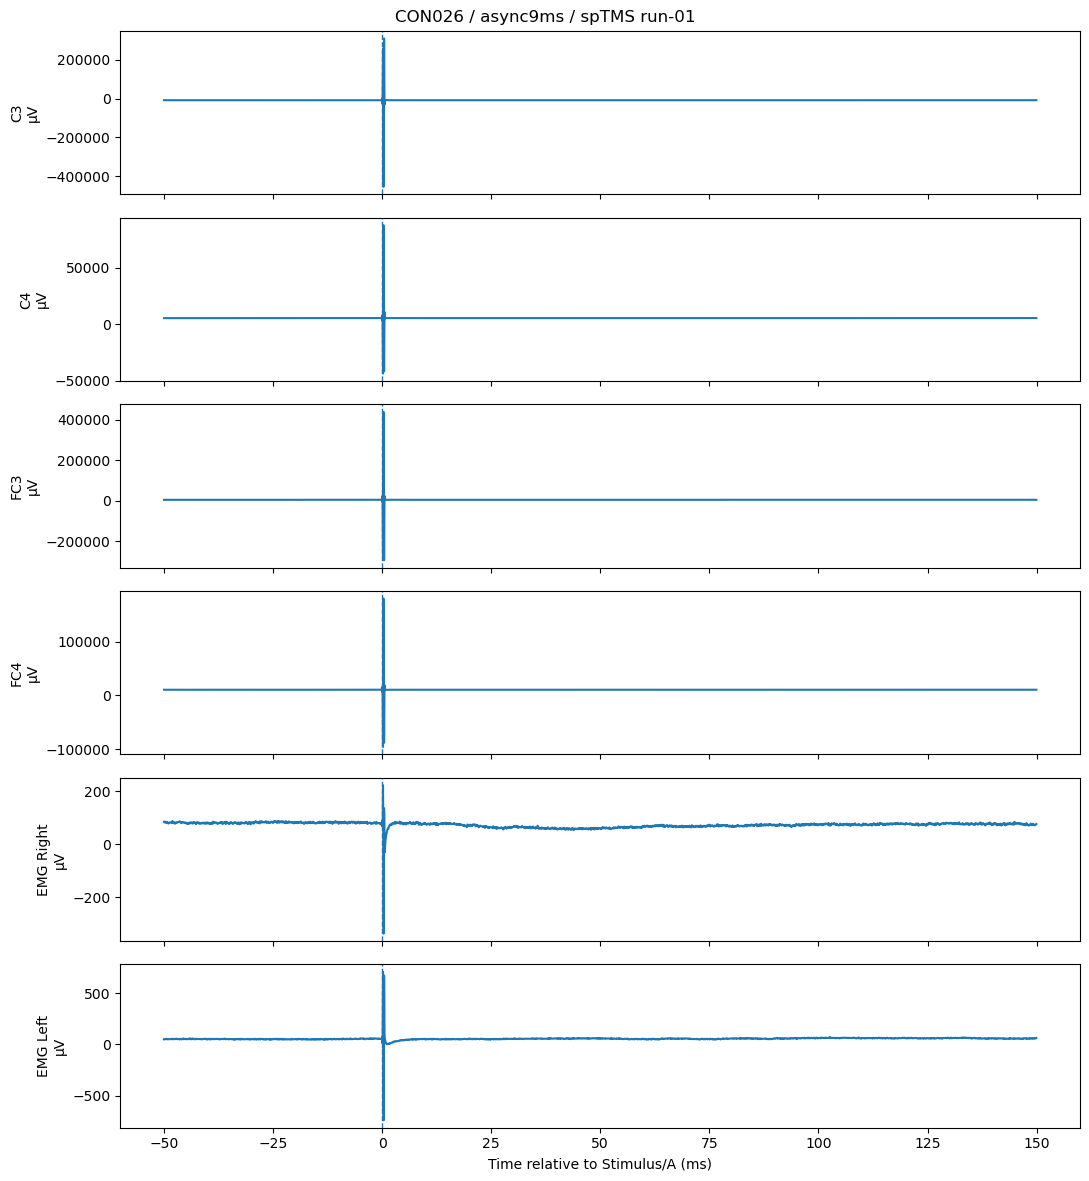

In [38]:
import matplotlib.pyplot as plt

t0 = stim_onsets[0]

candidate_channels = [
    "C3", "C4",
    "FC3", "FC4",
    "EMG Right", "EMG Left",
]

show_channels = [
    ch for ch in candidate_channels
    if ch in raw.ch_names
]

print("Plotting:", show_channels)

start = raw.time_as_index(t0 - 0.050)[0]
stop  = raw.time_as_index(t0 + 0.150)[0]

data, times = raw[
    show_channels,
    start:stop
]

times_ms = (times - t0) * 1000

fig, axes = plt.subplots(
    len(show_channels),
    1,
    figsize=(11, 2 * len(show_channels)),
    sharex=True
)

if len(show_channels) == 1:
    axes = [axes]

for ax, ch, x in zip(
    axes,
    show_channels,
    data
):
    ax.plot(times_ms, x * 1e6)
    ax.axvline(0, linestyle="--", linewidth=1)
    ax.set_ylabel(f"{ch}\nµV")

axes[-1].set_xlabel(
    "Time relative to Stimulus/A (ms)"
)

fig.suptitle(
    f"{subject} / {session} / spTMS run-{run}"
)

plt.tight_layout()
plt.show()

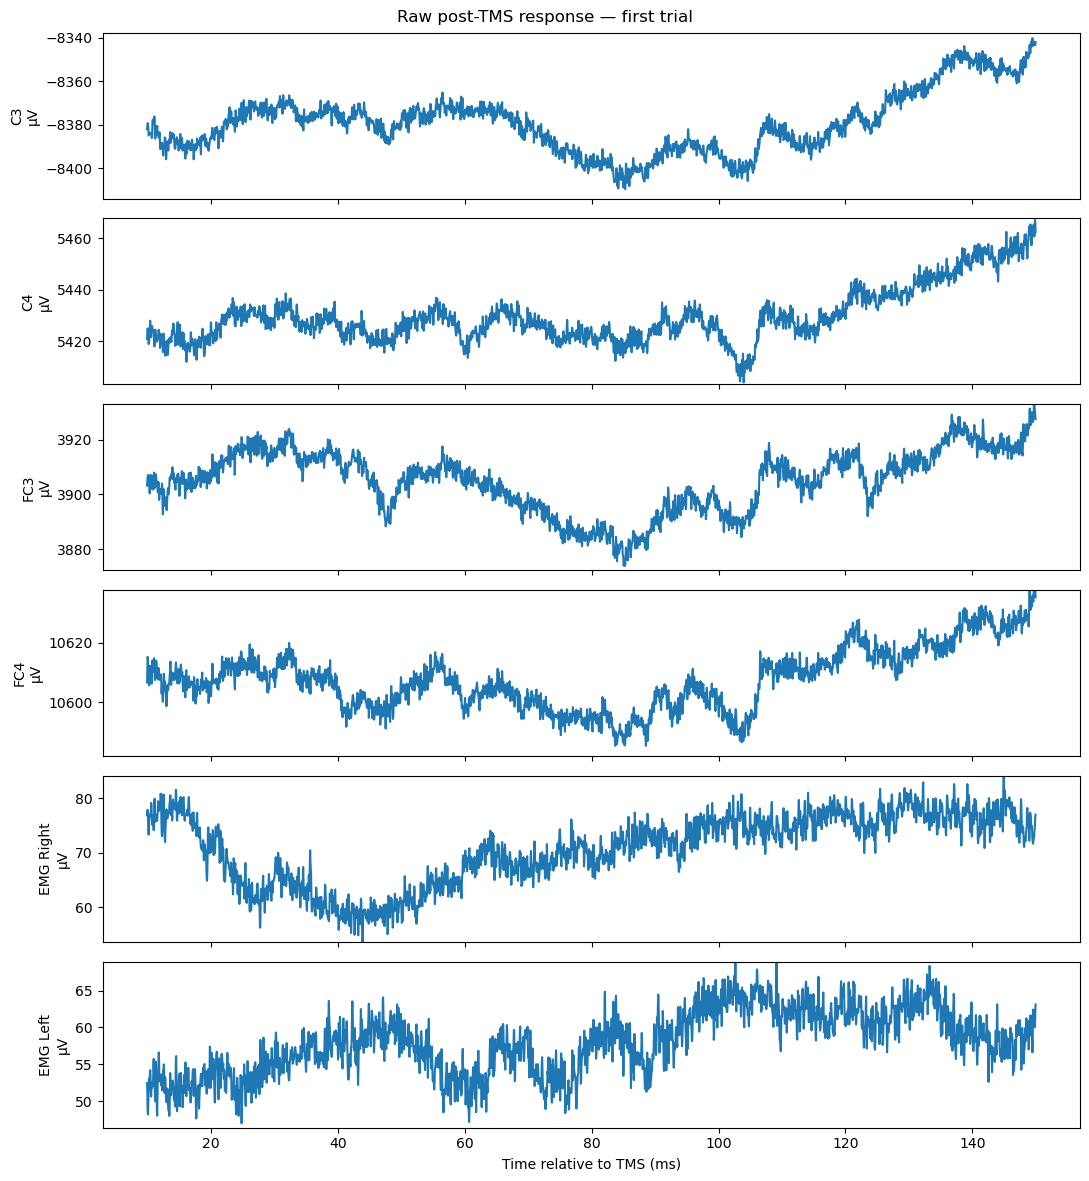

In [41]:
# Cell 27A — inspect post-TMS signal without letting the pulse
# artifact dominate the y-axis

t0 = stim_onsets[0]

show_channels = [
    "C3", "C4",
    "FC3", "FC4",
    "EMG Right", "EMG Left"
]

show_channels = [
    ch for ch in show_channels
    if ch in raw.ch_names
]

start = raw.time_as_index(t0 + 0.010)[0]
stop  = raw.time_as_index(t0 + 0.150)[0]

data, times = raw[
    show_channels,
    start:stop
]

times_ms = (times - t0) * 1000

fig, axes = plt.subplots(
    len(show_channels),
    1,
    figsize=(11, 2 * len(show_channels)),
    sharex=True
)

for ax, ch, x in zip(axes, show_channels, data):

    x_uv = x * 1e6

    ax.plot(times_ms, x_uv)

    # robust plotting limits so isolated spikes do not flatten everything
    lo, hi = np.percentile(x_uv, [1, 99])

    pad = 0.15 * (hi - lo)

    ax.set_ylim(lo - pad, hi + pad)
    ax.set_ylabel(f"{ch}\nµV")

axes[-1].set_xlabel(
    "Time relative to TMS (ms)"
)

fig.suptitle(
    "Raw post-TMS response — first trial"
)

plt.tight_layout()
plt.show()

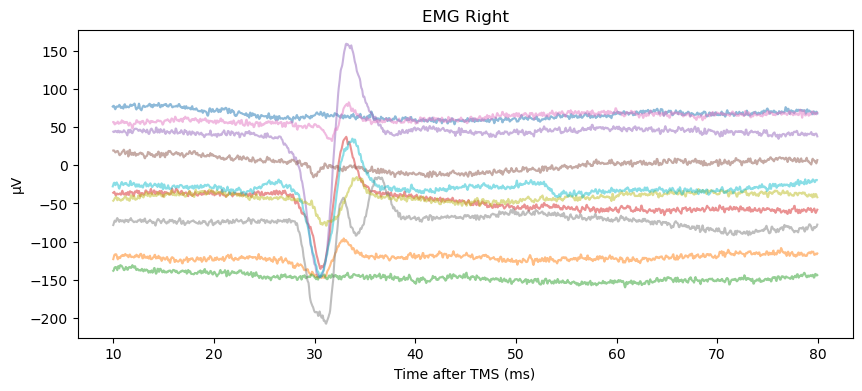

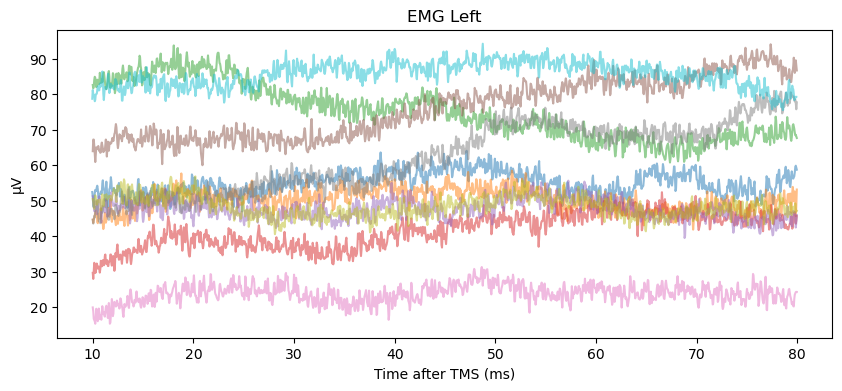

In [42]:
# Cell 27B — EMG response after the immediate TMS artifact

for channel in ["EMG Right", "EMG Left"]:

    plt.figure(figsize=(10, 4))

    for idx in [0, 5, 10, 20, 30, 40, 50, 60, 70, 79]:

        t0 = stim_onsets[idx]

        start = raw.time_as_index(t0 + 0.010)[0]
        stop  = raw.time_as_index(t0 + 0.080)[0]

        x, times = raw[[channel], start:stop]

        plt.plot(
            (times - t0) * 1000,
            x[0] * 1e6,
            alpha=0.5
        )

    plt.xlabel("Time after TMS (ms)")
    plt.ylabel("µV")
    plt.title(channel)

    plt.show()

In [43]:
# Quantify trial-wise MEP amplitude

emg_results = []

for trial_idx, t0 in enumerate(stim_onsets):

    row = {"trial": trial_idx + 1}

    for ch in ["EMG Right", "EMG Left"]:

        # Baseline: -100 to -10 ms
        b0 = raw.time_as_index(t0 - 0.100)[0]
        b1 = raw.time_as_index(t0 - 0.010)[0]

        baseline = raw.get_data(
            picks=[ch],
            start=b0,
            stop=b1
        )[0] * 1e6

        # Candidate MEP window: 20–50 ms
        m0 = raw.time_as_index(t0 + 0.020)[0]
        m1 = raw.time_as_index(t0 + 0.050)[0]

        mep = raw.get_data(
            picks=[ch],
            start=m0,
            stop=m1
        )[0] * 1e6

        # Remove local baseline median
        mep = mep - np.median(baseline)

        row[f"{ch}_p2p"] = np.ptp(mep)

    emg_results.append(row)

mep_df = pd.DataFrame(emg_results)

display(mep_df.head())

print("Median MEP peak-to-peak:")
print(
    "Right:",
    np.median(mep_df["EMG Right_p2p"]),
    "µV"
)
print(
    "Left :",
    np.median(mep_df["EMG Left_p2p"]),
    "µV"
)

,trial,EMG Right_p2p,EMG Left_p2p
0,1,21.640002,17.079999
1,2,499.459979,16.840002
2,3,48.559998,15.860001
3,4,42.160001,17.980005
4,5,41.240001,12.420000


Median MEP peak-to-peak:
Right: 54.45000095367431 µV
Left : 15.530001068115235 µV


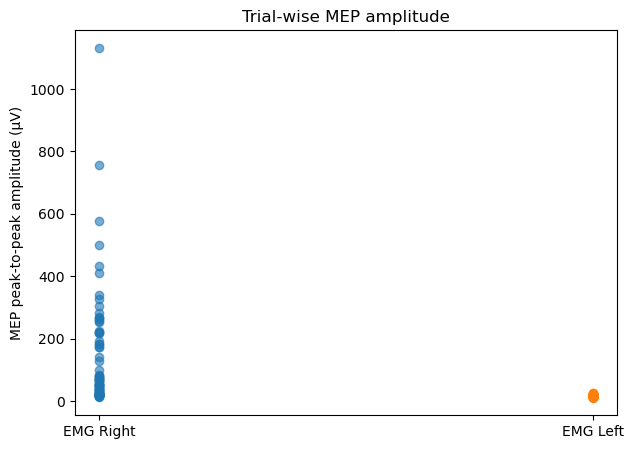

In [44]:
plt.figure(figsize=(7, 5))

plt.scatter(
    np.ones(len(mep_df)),
    mep_df["EMG Right_p2p"],
    alpha=0.6,
    label="Right"
)

plt.scatter(
    np.ones(len(mep_df)) * 2,
    mep_df["EMG Left_p2p"],
    alpha=0.6,
    label="Left"
)

plt.xticks(
    [1, 2],
    ["EMG Right", "EMG Left"]
)

plt.ylabel("MEP peak-to-peak amplitude (µV)")
plt.title("Trial-wise MEP amplitude")

plt.show()

In [46]:
# Cell 30 — exact size audit from manifest

import pandas as pd
from pathlib import Path

size_audit = df.copy()

def classify_file(path):
    p = path.lower()

    if "/eeg/" in p:
        return "EEG"
    if "/anat/" in p:
        return "ANAT"
    if "/dwi/" in p:
        return "DWI"
    if "/func/" in p:
        return "FUNC"
    return "OTHER"

size_audit["datatype"] = size_audit["path"].apply(classify_file)
size_audit["size_GB"] = size_audit["size"] / 1024**3

by_type = (
    size_audit.groupby("datatype")["size_GB"]
    .sum()
    .sort_values(ascending=False)
)

print("Total:", size_audit["size_GB"].sum(), "GiB")
display(by_type)

Total: 1021.2157014487311 GiB


datatype
EEG      1008.660176
FUNC       11.316511
DWI         1.198852
ANAT        0.040126
OTHER       0.000036
Name: size_GB, dtype: float64

In [47]:
# Cell 31 — EEG size by task

import re
import numpy as np

def get_task(path):
    m = re.search(r"task-([^_/.]+)", path)
    return m.group(1) if m else np.nan

eeg_manifest = size_audit[
    size_audit["datatype"] == "EEG"
].copy()

eeg_manifest["task"] = eeg_manifest["path"].apply(get_task)

display(
    eeg_manifest.groupby("task")["size_GB"]
    .sum()
    .sort_values(ascending=False)
)

task
spTMS    748.979229
ccPAS    147.315969
rest     112.364816
Name: size_GB, dtype: float64

data preprocessing

In [49]:
# Cell 32A — freeze exact TMS sample indices

sfreq = raw.info["sfreq"]

stim_events = ev[
    ev["trial_type"].eq("Stimulus/A")
].copy()

stim_samples = stim_events["sample"].astype(int).to_numpy()

print("N TMS trials:", len(stim_samples))
print("First 10 samples:", stim_samples[:10])

# sanity check
print(
    "First onset from sample:",
    stim_samples[0] / sfreq,
    "s"
)

print(
    "First onset in BIDS:",
    stim_events.iloc[0]["onset"],
    "s"
)

N TMS trials: 80
First 10 samples: [ 58586 158594 258600 358607 458613 558619 658626 758633 858641 958647]
First onset from sample: 2.9293 s
First onset in BIDS: 2.9293 s


In [50]:
# Cell 32B — fixed-sample window helper

def get_window(raw, picks, event_sample, tmin, tmax):
    """
    Extract [tmin, tmax) relative to an event using exact integer samples.
    """
    start_offset = int(round(tmin * raw.info["sfreq"]))
    stop_offset  = int(round(tmax * raw.info["sfreq"]))

    start = event_sample + start_offset
    stop  = event_sample + stop_offset

    return raw.get_data(
        picks=picks,
        start=start,
        stop=stop
    )

C3 (80, 3800)


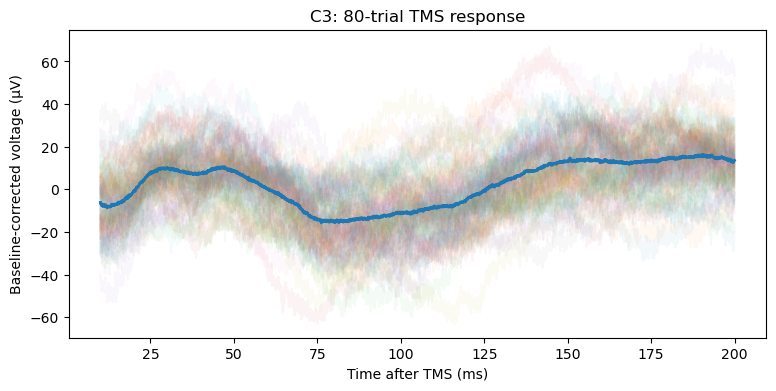

C4 (80, 3800)


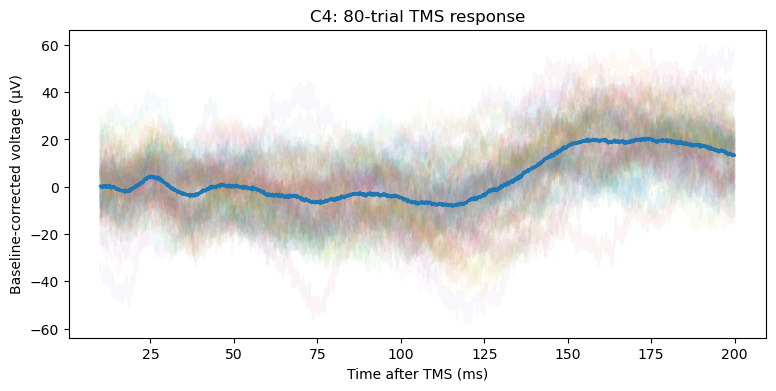

FC3 (80, 3800)


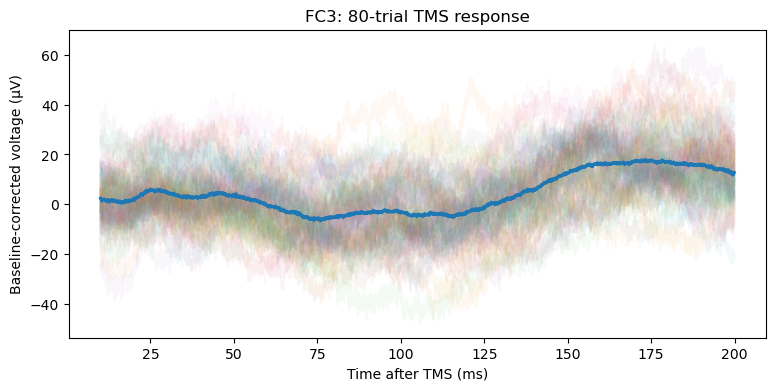

FC4 (80, 3800)


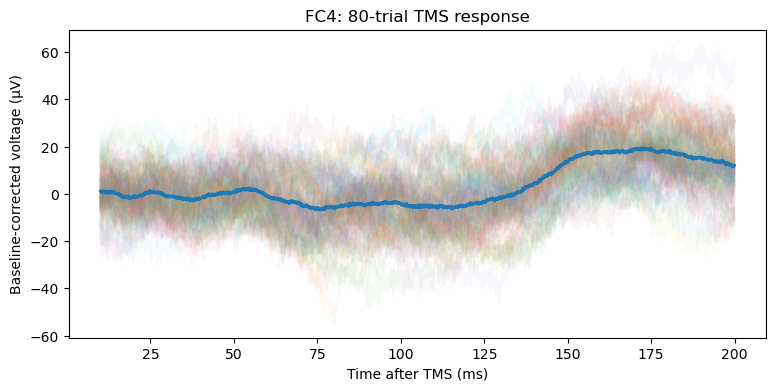

In [51]:
# Cell 32C — first TMS-evoked EEG audit, exact sample alignment

import numpy as np
import matplotlib.pyplot as plt

channels_test = ["C3", "C4", "FC3", "FC4"]

tep_store = {}

for ch in channels_test:

    trials = []

    for s0 in stim_samples:

        # baseline: -200 to -20 ms
        baseline_data = get_window(
            raw,
            [ch],
            s0,
            -0.200,
            -0.020
        )[0]

        baseline = baseline_data.mean()

        # post-TMS: +10 to +200 ms
        x = get_window(
            raw,
            [ch],
            s0,
            0.010,
            0.200
        )[0]

        trials.append(
            (x - baseline) * 1e6
        )

    trials = np.stack(trials, axis=0)
    tep_store[ch] = trials

    print(ch, trials.shape)

    mean_response = trials.mean(axis=0)

    rel_ms = (
        np.arange(trials.shape[1]) / sfreq * 1000
        + 10
    )

    plt.figure(figsize=(9, 4))

    for x in trials:
        plt.plot(
            rel_ms,
            x,
            alpha=0.05
        )

    plt.plot(
        rel_ms,
        mean_response,
        linewidth=2
    )

    plt.xlabel("Time after TMS (ms)")
    plt.ylabel("Baseline-corrected voltage (µV)")
    plt.title(f"{ch}: 80-trial TMS response")

    plt.show()

In [52]:
# Cell 33 — first X0 / Xf using exact sample windows

eeg_picks = mne.pick_types(
    raw.info,
    eeg=True,
    emg=False,
    eog=False,
    ecg=False,
    exclude=[]
)

eeg_names = [
    raw.ch_names[i]
    for i in eeg_picks
]

X0 = []
Xf = []

for s0 in stim_samples:

    # local reference: -200 to -100 ms
    ref = get_window(
        raw,
        eeg_picks,
        s0,
        -0.200,
        -0.100
    ).mean(axis=1)

    # prestimulus state: -50 to -10 ms
    x0 = get_window(
        raw,
        eeg_picks,
        s0,
        -0.050,
        -0.010
    ).mean(axis=1) - ref

    # early post-TMS state: +10 to +20 ms
    xf = get_window(
        raw,
        eeg_picks,
        s0,
        0.010,
        0.020
    ).mean(axis=1) - ref

    X0.append(x0)
    Xf.append(xf)

X0 = np.stack(X0)
Xf = np.stack(Xf)

X0_uv = X0 * 1e6
Xf_uv = Xf * 1e6

print("X0:", X0_uv.shape)
print("Xf:", Xf_uv.shape)

print(
    "Median prestimulus SD:",
    np.median(X0_uv.std(axis=0)),
    "µV"
)

print(
    "Median poststimulus SD:",
    np.median(Xf_uv.std(axis=0)),
    "µV"
)

X0: (80, 64)
Xf: (80, 64)
Median prestimulus SD: 12.732588483067044 µV
Median poststimulus SD: 12.17527475726473 µV


Explained variance ratio, PC1–PC5:
PC1: 0.5520
PC2: 0.2013
PC3: 0.0784
PC4: 0.0600
PC5: 0.0368

Cumulative PC1–PC5: 0.928555067800611

Chronology correlation:


,PC,Spearman_rho_vs_trial,p_value
0,PC1,-0.149391,0.185970
1,PC2,0.067206,0.553638
2,PC3,-0.117440,0.299512
3,PC4,-0.064534,0.569550
4,PC5,-0.093085,0.411499


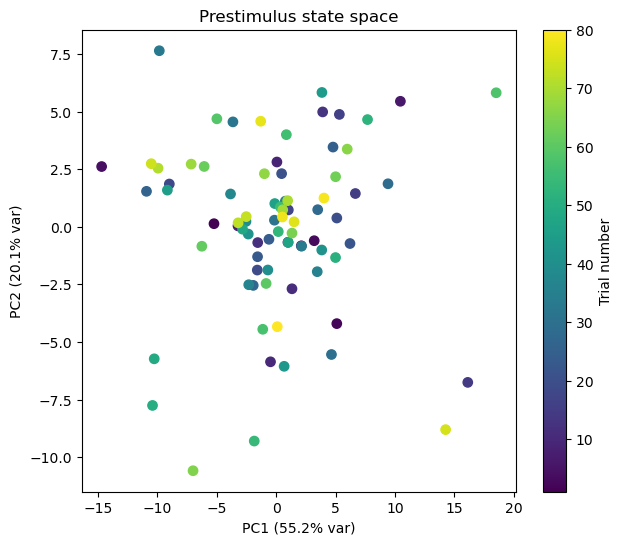

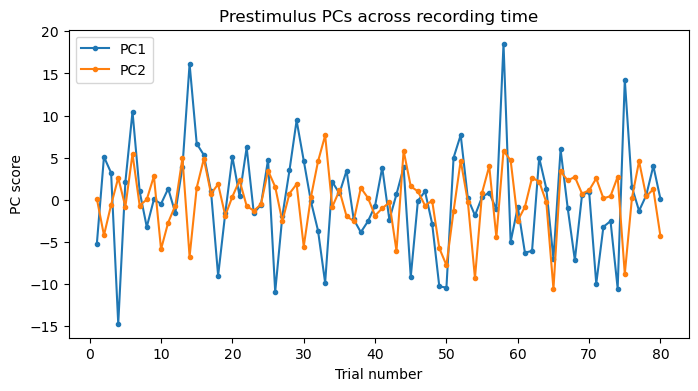

In [53]:
# Cell 34 — Is prestimulus variability just slow temporal drift?

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.stats import spearmanr

# Standardize each EEG channel across trials
X0z = StandardScaler().fit_transform(X0_uv)

# PCA of prestimulus state
pca0 = PCA()
Z0 = pca0.fit_transform(X0z)

print("Explained variance ratio, PC1–PC5:")
for j in range(5):
    print(
        f"PC{j+1}: "
        f"{pca0.explained_variance_ratio_[j]:.4f}"
    )

print(
    "\nCumulative PC1–PC5:",
    pca0.explained_variance_ratio_[:5].sum()
)

# --------------------------------------------------
# Correlation with chronological trial number
# --------------------------------------------------

trial_no = np.arange(1, len(X0_uv) + 1)

rows = []

for j in range(5):
    rho, pval = spearmanr(
        trial_no,
        Z0[:, j]
    )

    rows.append({
        "PC": f"PC{j+1}",
        "Spearman_rho_vs_trial": rho,
        "p_value": pval
    })

drift_table = pd.DataFrame(rows)

print("\nChronology correlation:")
display(drift_table)

# --------------------------------------------------
# PCA state-space plot
# --------------------------------------------------

plt.figure(figsize=(7, 6))

sc = plt.scatter(
    Z0[:, 0],
    Z0[:, 1],
    c=trial_no,
    s=45
)

plt.xlabel(
    f"PC1 "
    f"({100*pca0.explained_variance_ratio_[0]:.1f}% var)"
)
plt.ylabel(
    f"PC2 "
    f"({100*pca0.explained_variance_ratio_[1]:.1f}% var)"
)

plt.title("Prestimulus state space")

cb = plt.colorbar(sc)
cb.set_label("Trial number")

plt.show()

# --------------------------------------------------
# PC1 and PC2 explicitly versus time
# --------------------------------------------------

plt.figure(figsize=(8, 4))

plt.plot(
    trial_no,
    Z0[:, 0],
    marker="o",
    markersize=3,
    label="PC1"
)

plt.plot(
    trial_no,
    Z0[:, 1],
    marker="o",
    markersize=3,
    label="PC2"
)

plt.xlabel("Trial number")
plt.ylabel("PC score")
plt.title("Prestimulus PCs across recording time")
plt.legend()

plt.show()

Y_post shape: (80, 4, 64)
Expected: (80 trials, 4 post windows, 64 EEG channels)
Flattened response shape: (80, 256)
Median feature SD across trials: 8.157688764467173 µV

Post-response PCA:
PC1: 0.1994
PC2: 0.1803
PC3: 0.1455
PC4: 0.0879
PC5: 0.0763
Cumulative PC1–PC5: 0.6894606507088338

Response chronology correlations:
PC1: rho=-0.149, p=0.186
PC2: rho=0.111, p=0.325
PC3: rho=0.053, p=0.638
PC4: rho=0.069, p=0.54
PC5: rho=0.118, p=0.299


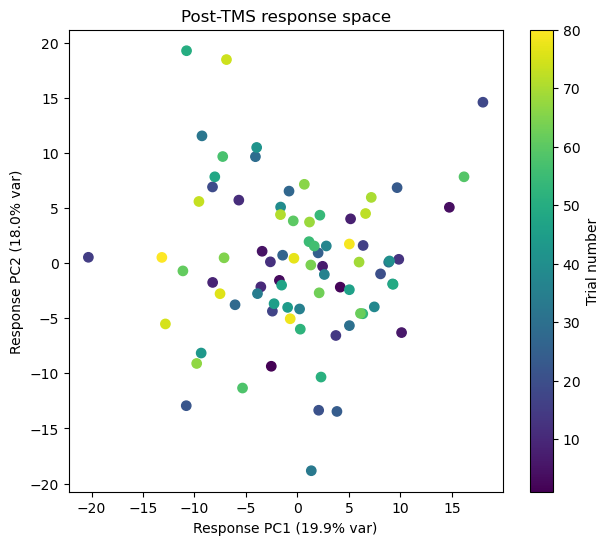

In [54]:
# Cell 35 — construct a post-only response descriptor
# No prestimulus reference is used here.

post_windows = [
    (0.010, 0.020),
    (0.030, 0.050),
    (0.070, 0.100),
    (0.140, 0.180),
]

Y_post = []

for s0 in stim_samples:

    window_states = []

    for tmin, tmax in post_windows:

        x = get_window(
            raw,
            eeg_picks,
            s0,
            tmin,
            tmax
        ).mean(axis=1)

        window_states.append(x)

    # shape: (4 windows, 64 channels)
    window_states = np.stack(window_states, axis=0)

    # Remove per-trial/per-channel post-TMS DC level.
    # This uses POST-TMS data only.
    window_states = (
        window_states
        - window_states.mean(axis=0, keepdims=True)
    )

    Y_post.append(window_states)

Y_post = np.stack(Y_post, axis=0) * 1e6

print("Y_post shape:", Y_post.shape)
print(
    "Expected:",
    "(80 trials, 4 post windows, 64 EEG channels)"
)

# Flatten temporal × spatial response for diagnostics
Y_flat = Y_post.reshape(len(Y_post), -1)

print("Flattened response shape:", Y_flat.shape)

print(
    "Median feature SD across trials:",
    np.median(Y_flat.std(axis=0)),
    "µV"
)

# ------------------------------------------
# PCA: how low-dimensional is the response?
# ------------------------------------------

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

Yz = StandardScaler().fit_transform(Y_flat)

pca_y = PCA()
ZY = pca_y.fit_transform(Yz)

print("\nPost-response PCA:")
for j in range(5):
    print(
        f"PC{j+1}: "
        f"{pca_y.explained_variance_ratio_[j]:.4f}"
    )

print(
    "Cumulative PC1–PC5:",
    pca_y.explained_variance_ratio_[:5].sum()
)

# ------------------------------------------
# Check whether RESPONSE itself drifts in time
# ------------------------------------------

from scipy.stats import spearmanr

trial_no = np.arange(1, len(Y_post) + 1)

print("\nResponse chronology correlations:")

for j in range(5):

    rho, pval = spearmanr(
        trial_no,
        ZY[:, j]
    )

    print(
        f"PC{j+1}: "
        f"rho={rho:.3f}, p={pval:.3g}"
    )

# ------------------------------------------
# Plot response latent space
# ------------------------------------------

import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))

sc = plt.scatter(
    ZY[:, 0],
    ZY[:, 1],
    c=trial_no,
    s=45
)

plt.xlabel(
    f"Response PC1 "
    f"({100*pca_y.explained_variance_ratio_[0]:.1f}% var)"
)
plt.ylabel(
    f"Response PC2 "
    f"({100*pca_y.explained_variance_ratio_[1]:.1f}% var)"
)

plt.title("Post-TMS response space")

cb = plt.colorbar(sc)
cb.set_label("Trial number")

plt.show()

REAL blocked-CV prediction gain:
0.018247339808088903

Outer folds:


,fold,n_test,best_alpha,prediction_gain
0,1,16,1000.0,0.017141
1,2,16,1000.0,0.020285
2,3,16,1000.0,-0.042900
3,4,16,1000.0,0.046600
4,5,16,1000.0,0.025858



Temporal-shift null:
Null median gain: -0.012724932543606071
Null 95th percentile: 0.007969568588658613
Best null gain: 0.02096339557203164
Shift-test p: 0.05


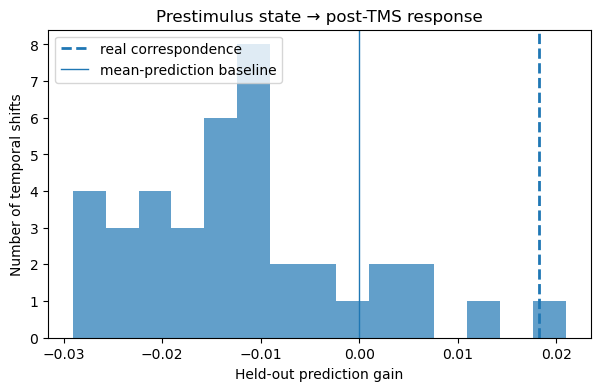

In [55]:
# Cell 36
# Does prestimulus state contain out-of-sample predictive information
# about the post-TMS response?
#
# Strict version:
#   - contiguous 5-fold outer CV
#   - PCA fitted ONLY on training trials
#   - Ridge alpha selected by inner blocked CV
#   - response normalization fitted ONLY on training trials
#   - circular-shift null preserves temporal structure in Y

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge


X = X0_uv.copy()
Y = Y_flat.copy()

n_trials = len(X)

# Five contiguous temporal blocks
blocks = [
    np.asarray(b)
    for b in np.array_split(np.arange(n_trials), 5)
]

alphas = np.logspace(-3, 3, 7)

N_PC_X = 5


def fit_predict_once(X_train, Y_train, X_test, Y_test, alpha):
    """
    Fit preprocessing and Ridge ONLY on training data.
    Returns predictions and targets in training-standardized
    response coordinates.
    """

    # ----- X preprocessing -----
    x_scaler = StandardScaler()
    Xtr_z = x_scaler.fit_transform(X_train)
    Xte_z = x_scaler.transform(X_test)

    pca = PCA(n_components=N_PC_X)
    Ztr = pca.fit_transform(Xtr_z)
    Zte = pca.transform(Xte_z)

    # ----- Y normalization -----
    y_mean = Y_train.mean(axis=0)
    y_std = Y_train.std(axis=0)

    # avoid numerical problems for near-constant response features
    y_std[y_std < 1e-8] = 1.0

    Ytr_z = (Y_train - y_mean) / y_std
    Yte_z = (Y_test - y_mean) / y_std

    # ----- multi-output regression -----
    model = Ridge(alpha=alpha)
    model.fit(Ztr, Ytr_z)

    pred = model.predict(Zte)

    return pred, Yte_z


def blocked_nested_cv_score(X, Y):

    total_model_sse = 0.0
    total_baseline_sse = 0.0

    fold_rows = []

    all_idx = np.arange(len(X))

    for outer_k, test_idx in enumerate(blocks):

        train_idx = np.setdiff1d(
            all_idx,
            test_idx
        )

        # --------------------------------------------------
        # Inner blocked CV for alpha
        # --------------------------------------------------

        candidate_scores = []

        inner_blocks = [
            b for j, b in enumerate(blocks)
            if j != outer_k
        ]

        for alpha in alphas:

            inner_mse = []

            for val_idx in inner_blocks:

                inner_train_idx = np.setdiff1d(
                    train_idx,
                    val_idx
                )

                pred, y_true = fit_predict_once(
                    X[inner_train_idx],
                    Y[inner_train_idx],
                    X[val_idx],
                    Y[val_idx],
                    alpha
                )

                inner_mse.append(
                    np.mean(
                        (pred - y_true) ** 2
                    )
                )

            candidate_scores.append(
                np.mean(inner_mse)
            )

        best_alpha = alphas[
            np.argmin(candidate_scores)
        ]

        # --------------------------------------------------
        # Outer held-out block
        # --------------------------------------------------

        pred, y_true = fit_predict_once(
            X[train_idx],
            Y[train_idx],
            X[test_idx],
            Y[test_idx],
            best_alpha
        )

        model_sse = np.sum(
            (pred - y_true) ** 2
        )

        # baseline = predict training response mean,
        # which is zero in standardized Y coordinates
        baseline_sse = np.sum(
            y_true ** 2
        )

        fold_gain = (
            1.0
            - model_sse / baseline_sse
        )

        total_model_sse += model_sse
        total_baseline_sse += baseline_sse

        fold_rows.append({
            "fold": outer_k + 1,
            "n_test": len(test_idx),
            "best_alpha": best_alpha,
            "prediction_gain": fold_gain
        })

    overall_gain = (
        1.0
        - total_model_sse
        / total_baseline_sse
    )

    return overall_gain, pd.DataFrame(fold_rows)


# ============================================================
# REAL correspondence
# ============================================================

real_gain, real_folds = blocked_nested_cv_score(
    X, Y
)

print("REAL blocked-CV prediction gain:")
print(real_gain)

print("\nOuter folds:")
display(real_folds)


# ============================================================
# TEMPORAL-SHIFT NULL
#
# Circular shifts preserve Y's internal temporal structure
# but destroy the correct trial-by-trial X -> Y correspondence.
# ============================================================

null_shifts = np.arange(
    2,
    n_trials,
    2
)

null_gains = []

for shift in null_shifts:

    Y_shift = np.roll(
        Y,
        shift=shift,
        axis=0
    )

    gain, _ = blocked_nested_cv_score(
        X,
        Y_shift
    )

    null_gains.append(gain)

null_gains = np.asarray(null_gains)

p_shift = (
    1
    + np.sum(null_gains >= real_gain)
) / (
    1
    + len(null_gains)
)

print("\nTemporal-shift null:")
print(
    "Null median gain:",
    np.median(null_gains)
)
print(
    "Null 95th percentile:",
    np.percentile(null_gains, 95)
)
print(
    "Best null gain:",
    null_gains.max()
)
print(
    "Shift-test p:",
    p_shift
)


# ============================================================
# Plot
# ============================================================

plt.figure(figsize=(7, 4))

plt.hist(
    null_gains,
    bins=15,
    alpha=0.7
)

plt.axvline(
    real_gain,
    linestyle="--",
    linewidth=2,
    label="real correspondence"
)

plt.axvline(
    0,
    linewidth=1,
    label="mean-prediction baseline"
)

plt.xlabel(
    "Held-out prediction gain"
)
plt.ylabel(
    "Number of temporal shifts"
)
plt.title(
    "Prestimulus state → post-TMS response"
)

plt.legend()
plt.show()

REAL latent blocked-CV gain:
0.03161481389101084

Outer folds:


,fold,n_test,best_alpha,prediction_gain,train_X_variance_5PC,train_Y_variance_5PC
0,1,16,1000.0,0.029766,0.927802,0.702145
1,2,16,1000.0,0.035571,0.932815,0.686282
2,3,16,1000.0,-0.062433,0.936027,0.701469
3,4,16,1000.0,0.062923,0.924782,0.691165
4,5,16,1000.0,0.048097,0.928495,0.695737



Temporal-shift null:
Null median gain: -0.0010353039848649548
Null 95th percentile: 0.004877077923974153
Best null gain: 0.02725977556734449
Shift-test p: 0.025


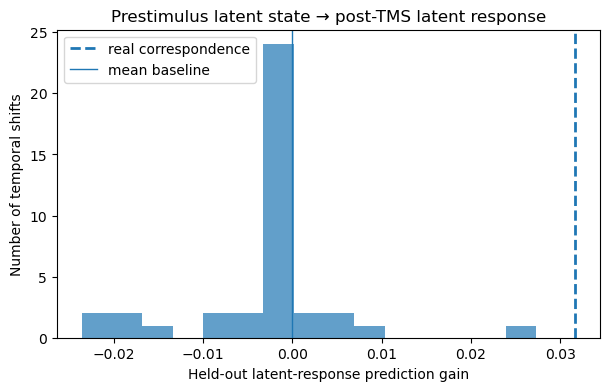

In [56]:
# Cell 37
# Strict latent-state -> latent-response prediction
# All preprocessing is fitted on training trials only.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge


X = X0_uv.copy()
Y = Y_flat.copy()

N_PC_X = 5
N_PC_Y = 5

alphas = np.logspace(-3, 6, 10)

n_trials = len(X)

blocks = [
    np.asarray(b)
    for b in np.array_split(np.arange(n_trials), 5)
]


def fit_predict_latent(
    X_train,
    Y_train,
    X_test,
    Y_test,
    alpha
):
    # ----------------------------------
    # X: training-only scaling + PCA
    # ----------------------------------
    x_scaler = StandardScaler()

    Xtr_z = x_scaler.fit_transform(X_train)
    Xte_z = x_scaler.transform(X_test)

    pca_x = PCA(n_components=N_PC_X)

    Zx_tr = pca_x.fit_transform(Xtr_z)
    Zx_te = pca_x.transform(Xte_z)

    # ----------------------------------
    # Y: training-only scaling + PCA
    # ----------------------------------
    y_scaler = StandardScaler()

    Ytr_z = y_scaler.fit_transform(Y_train)
    Yte_z = y_scaler.transform(Y_test)

    pca_y = PCA(n_components=N_PC_Y)

    Zy_tr = pca_y.fit_transform(Ytr_z)
    Zy_te = pca_y.transform(Yte_z)

    # ----------------------------------
    # Ridge latent mapping
    # ----------------------------------
    model = Ridge(alpha=alpha)

    model.fit(
        Zx_tr,
        Zy_tr
    )

    pred = model.predict(Zx_te)

    # Baseline:
    # training latent-Y mean = zero
    baseline = np.zeros_like(Zy_te)

    return (
        pred,
        Zy_te,
        baseline,
        pca_x.explained_variance_ratio_.sum(),
        pca_y.explained_variance_ratio_.sum()
    )


def blocked_latent_cv_score(X, Y):

    all_idx = np.arange(len(X))

    total_model_sse = 0.0
    total_baseline_sse = 0.0

    fold_rows = []

    for outer_k, test_idx in enumerate(blocks):

        train_idx = np.setdiff1d(
            all_idx,
            test_idx
        )

        # ==================================================
        # INNER blocked CV: choose alpha
        # ==================================================

        inner_blocks = [
            b for j, b in enumerate(blocks)
            if j != outer_k
        ]

        candidate_scores = []

        for alpha in alphas:

            inner_sse = 0.0
            inner_base_sse = 0.0

            for val_idx in inner_blocks:

                inner_train_idx = np.setdiff1d(
                    train_idx,
                    val_idx
                )

                (
                    pred,
                    truth,
                    baseline,
                    _,
                    _
                ) = fit_predict_latent(
                    X[inner_train_idx],
                    Y[inner_train_idx],
                    X[val_idx],
                    Y[val_idx],
                    alpha
                )

                inner_sse += np.sum(
                    (pred - truth) ** 2
                )

                inner_base_sse += np.sum(
                    (baseline - truth) ** 2
                )

            inner_gain = (
                1
                - inner_sse / inner_base_sse
            )

            candidate_scores.append(
                inner_gain
            )

        best_alpha = alphas[
            np.argmax(candidate_scores)
        ]

        # ==================================================
        # OUTER held-out block
        # ==================================================

        (
            pred,
            truth,
            baseline,
            var_x,
            var_y
        ) = fit_predict_latent(
            X[train_idx],
            Y[train_idx],
            X[test_idx],
            Y[test_idx],
            best_alpha
        )

        model_sse = np.sum(
            (pred - truth) ** 2
        )

        baseline_sse = np.sum(
            (baseline - truth) ** 2
        )

        gain = (
            1
            - model_sse / baseline_sse
        )

        total_model_sse += model_sse
        total_baseline_sse += baseline_sse

        fold_rows.append({
            "fold": outer_k + 1,
            "n_test": len(test_idx),
            "best_alpha": best_alpha,
            "prediction_gain": gain,
            "train_X_variance_5PC": var_x,
            "train_Y_variance_5PC": var_y
        })

    overall_gain = (
        1
        - total_model_sse
        / total_baseline_sse
    )

    return (
        overall_gain,
        pd.DataFrame(fold_rows)
    )


# ==========================================================
# REAL trial correspondence
# ==========================================================

real_gain_latent, real_folds_latent = (
    blocked_latent_cv_score(
        X,
        Y
    )
)

print(
    "REAL latent blocked-CV gain:"
)
print(
    real_gain_latent
)

print("\nOuter folds:")
display(
    real_folds_latent
)


# ==========================================================
# CIRCULAR-SHIFT NULL
# ==========================================================

null_shifts = np.arange(
    2,
    n_trials,
    2
)

null_gains_latent = []

for shift in null_shifts:

    Y_shift = np.roll(
        Y,
        shift=shift,
        axis=0
    )

    gain, _ = blocked_latent_cv_score(
        X,
        Y_shift
    )

    null_gains_latent.append(
        gain
    )

null_gains_latent = np.asarray(
    null_gains_latent
)

p_shift_latent = (
    1
    + np.sum(
        null_gains_latent
        >= real_gain_latent
    )
) / (
    1 + len(null_gains_latent)
)

print("\nTemporal-shift null:")
print(
    "Null median gain:",
    np.median(null_gains_latent)
)
print(
    "Null 95th percentile:",
    np.percentile(
        null_gains_latent,
        95
    )
)
print(
    "Best null gain:",
    null_gains_latent.max()
)
print(
    "Shift-test p:",
    p_shift_latent
)


# ==========================================================
# Plot
# ==========================================================

plt.figure(figsize=(7, 4))

plt.hist(
    null_gains_latent,
    bins=15,
    alpha=0.7
)

plt.axvline(
    real_gain_latent,
    linestyle="--",
    linewidth=2,
    label="real correspondence"
)

plt.axvline(
    0,
    linewidth=1,
    label="mean baseline"
)

plt.xlabel(
    "Held-out latent-response prediction gain"
)

plt.ylabel(
    "Number of temporal shifts"
)

plt.title(
    "Prestimulus latent state → post-TMS latent response"
)

plt.legend()
plt.show()

Data cleaning - Level 1

In [58]:
# ============================================================
# LEVEL-1 / CELL 1
# Measurement-preserving TMS-locked epochs
#
# No filtering
# No baseline correction
# No detrending
# No rejection
# No interpolation
# No downsampling
# ============================================================

import numpy as np
import pandas as pd
import mne

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

L1_TMIN = -0.500   # seconds
L1_TMAX =  0.300   # seconds

sfreq = raw.info["sfreq"]

print(f"Raw sampling frequency: {sfreq:.1f} Hz")
print(f"Number of TMS events: {len(stim_samples)}")

# ------------------------------------------------------------
# MNE event array
#
# columns:
#   sample index, previous event value, event ID
# ------------------------------------------------------------

events_l1 = np.column_stack([
    stim_samples,
    np.zeros(len(stim_samples), dtype=int),
    np.ones(len(stim_samples), dtype=int)
]).astype(int)

event_id_l1 = {
    "spTMS": 1
}

# ------------------------------------------------------------
# Explicit boundary check
# ------------------------------------------------------------

pre_samples = int(round(abs(L1_TMIN) * sfreq))
post_samples = int(round(L1_TMAX * sfreq))

valid_left = (
    stim_samples - pre_samples >= 0
)

valid_right = (
    stim_samples + post_samples < raw.n_times
)

valid = valid_left & valid_right

print(
    "Events with complete "
    f"[{L1_TMIN*1000:.0f}, "
    f"{L1_TMAX*1000:.0f}] ms window:",
    valid.sum(),
    "/",
    len(valid)
)

if not np.all(valid):
    bad_idx = np.where(~valid)[0]
    raise RuntimeError(
        f"Some TMS trials exceed raw-data boundaries: "
        f"{bad_idx.tolist()}"
    )

# ------------------------------------------------------------
# Create lazy MNE Epochs
#
# Important:
# preload=False keeps the ~700 MB epoch array out of RAM.
# baseline=None preserves the measured voltages.
# reject=None means NO trial rejection at this stage.
# ------------------------------------------------------------

epochs_l1 = mne.Epochs(
    raw,
    events=events_l1,
    event_id=event_id_l1,
    tmin=L1_TMIN,
    tmax=L1_TMAX,
    baseline=None,
    preload=False,
    reject=None,
    flat=None,
    reject_by_annotation=False,
    detrend=None,
    proj=False,
    verbose=True
)

# ------------------------------------------------------------
# Trial metadata
# ------------------------------------------------------------

trial_metadata_l1 = pd.DataFrame({
    "trial_id": np.arange(1, len(stim_samples) + 1),
    "stim_sample": stim_samples,
    "stim_onset_s": stim_samples / sfreq,
})

epochs_l1.metadata = trial_metadata_l1

# ------------------------------------------------------------
# Audit
# ------------------------------------------------------------

n_epochs_l1 = len(epochs_l1.events)
n_channels_l1 = len(epochs_l1.ch_names)
n_times_l1 = len(epochs_l1.times)

print("\n=== LEVEL-1 EPOCH AUDIT ===")

print(epochs_l1)

print(
    "Number of event-defined epochs:",
    n_epochs_l1
)

print(
    "Channels:",
    n_channels_l1
)

print(
    "Samples per epoch:",
    n_times_l1
)

print(
    "Epoch time range:",
    epochs_l1.times[0],
    "to",
    epochs_l1.times[-1],
    "s"
)

print(
    "Epoch duration:",
    epochs_l1.times[-1]
    - epochs_l1.times[0],
    "s"
)

print(
    "Approx. in-memory size if float64:",
    (
        n_epochs_l1
        * n_channels_l1
        * n_times_l1
        * 8
        / 1024**3
    ),
    "GiB"
)

print("\nChannel types:")
print(
    pd.Series(
        epochs_l1.get_channel_types()
    ).value_counts()
)

print("\nTrial metadata:")
display(
    epochs_l1.metadata.head()
)

Raw sampling frequency: 20000.0 Hz
Number of TMS events: 80
Events with complete [-500, 300] ms window: 80 / 80
Not setting metadata
80 matching events found
No baseline correction applied
Adding metadata with 3 columns

=== LEVEL-1 EPOCH AUDIT ===
<Epochs | 80 events (good & bad), -0.5 – 0.3 s (baseline off), ~60 KiB, data not loaded, with metadata,
 'spTMS': 80>
Number of event-defined epochs: 80
Channels: 69
Samples per epoch: 16001
Epoch time range: -0.5 to 0.3 s
Epoch duration: 0.8 s
Approx. in-memory size if float64: 0.6580764055252075 GiB

Channel types:
eeg    64
emg     2
eog     2
ecg     1
Name: count, dtype: int64

Trial metadata:


,trial_id,stim_sample,stim_onset_s
0,1,58586,2.92930
1,2,158594,7.92970
2,3,258600,12.93000
3,4,358607,17.93035
4,5,458613,22.93065


In [59]:
# ============================================================
# LEVEL-1 / CELL 2
# Paper-compatible detrended QC copy
#
# IMPORTANT:
# - epochs_l1 is NOT modified.
# - detrending is used ONLY for QC.
# - no filtering / baseline / interpolation / rejection.
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

QC_FIT_TMIN = -0.200
QC_FIT_TMAX =  0.100

# Do not let the immediate TMS pulse dominate the trend fit
TMS_MASK_TMIN = -0.005
TMS_MASK_TMAX =  0.005

times_l1 = epochs_l1.times
n_trials = len(epochs_l1.events)
n_channels = len(epochs_l1.ch_names)
n_times = len(times_l1)

# Paper QC interval
qc_interval = (
    (times_l1 >= QC_FIT_TMIN) &
    (times_l1 <= QC_FIT_TMAX)
)

# Immediate pulse-artifact interval
pulse_mask = (
    (times_l1 >= TMS_MASK_TMIN) &
    (times_l1 <= TMS_MASK_TMAX)
)

# Samples actually used to fit the linear trend
fit_mask = qc_interval & (~pulse_mask)

print(
    "QC interval:",
    QC_FIT_TMIN,
    "to",
    QC_FIT_TMAX,
    "s"
)

print(
    "Excluded from trend fit:",
    TMS_MASK_TMIN,
    "to",
    TMS_MASK_TMAX,
    "s"
)

print(
    "Samples used for trend fit:",
    fit_mask.sum()
)

# ------------------------------------------------------------
# Allocate detrended QC copy
#
# float32 is sufficient for QC and halves memory use.
# Measurement-preserving data remain in epochs_l1/raw.
# ------------------------------------------------------------

qc_data_dt = np.empty(
    (n_trials, n_channels, n_times),
    dtype=np.float32
)

# Save trend coefficients for reproducibility
qc_trend_slope = np.empty(
    (n_trials, n_channels),
    dtype=np.float64
)

qc_trend_intercept = np.empty(
    (n_trials, n_channels),
    dtype=np.float64
)

# Diagnostics
raw_abs_medians_uv = []
dt_abs_medians_uv = []

# Time vector used for regression
t_fit = times_l1[fit_mask]
t_mean = t_fit.mean()
t_centered = t_fit - t_mean
t_ss = np.sum(t_centered ** 2)

# Epoch boundaries in raw samples
pre_samples = int(round(abs(L1_TMIN) * sfreq))
post_samples = int(round(L1_TMAX * sfreq))

# ------------------------------------------------------------
# Process one trial at a time
# ------------------------------------------------------------

for trial_idx, s0 in enumerate(stim_samples):

    start = s0 - pre_samples
    stop = s0 + post_samples + 1  # inclusive endpoint

    # shape: (69, 16001), volts
    x = raw.get_data(
        start=start,
        stop=stop
    )

    if x.shape != (n_channels, n_times):
        raise RuntimeError(
            f"Unexpected shape at trial {trial_idx + 1}: "
            f"{x.shape}"
        )

    # --------------------------------------------------------
    # Linear least-squares trend:
    #
    # y(t) = intercept + slope * t
    #
    # Fit only on QC interval excluding immediate pulse.
    # --------------------------------------------------------

    y_fit = x[:, fit_mask]

    y_mean = y_fit.mean(axis=1)

    slope = (
        y_fit @ t_centered
    ) / t_ss

    intercept = (
        y_mean - slope * t_mean
    )

    trend = (
        intercept[:, None]
        + slope[:, None] * times_l1[None, :]
    )

    x_dt = x - trend

    qc_data_dt[trial_idx] = x_dt.astype(
        np.float32
    )

    qc_trend_slope[trial_idx] = slope
    qc_trend_intercept[trial_idx] = intercept

    # Simple diagnostic restricted to fit samples
    raw_abs_medians_uv.append(
        np.median(
            np.abs(y_fit)
        ) * 1e6
    )

    dt_abs_medians_uv.append(
        np.median(
            np.abs(x_dt[:, fit_mask])
        ) * 1e6
    )

# ------------------------------------------------------------
# Audit
# ------------------------------------------------------------

print("\n=== DETRENDED QC COPY AUDIT ===")

print(
    "qc_data_dt shape:",
    qc_data_dt.shape
)

print(
    "qc_data_dt dtype:",
    qc_data_dt.dtype
)

print(
    "Approx memory:",
    qc_data_dt.nbytes / 1024**3,
    "GiB"
)

print(
    "\nMedian |signal| before detrending:",
    np.median(raw_abs_medians_uv),
    "µV"
)

print(
    "Median |signal| after detrending:",
    np.median(dt_abs_medians_uv),
    "µV"
)

# Trend magnitude in useful units
slope_uv_per_s = qc_trend_slope * 1e6

print(
    "\nMedian |linear slope|:",
    np.median(np.abs(slope_uv_per_s)),
    "µV/s"
)

print(
    "95th percentile |linear slope|:",
    np.percentile(
        np.abs(slope_uv_per_s),
        95
    ),
    "µV/s"
)

# ------------------------------------------------------------
# Confirm measurement parent is unchanged
# ------------------------------------------------------------

print(
    "\nMeasurement-preserving parent still lazy:",
    not epochs_l1.preload
)

print(
    "Original epochs still:",
    len(epochs_l1.events),
    "event-defined trials"
)

QC interval: -0.2 to 0.1 s
Excluded from trend fit: -0.005 to 0.005 s
Samples used for trend fit: 5800

=== DETRENDED QC COPY AUDIT ===
qc_data_dt shape: (80, 69, 16001)
qc_data_dt dtype: float32
Approx memory: 0.32903820276260376 GiB

Median |signal| before detrending: 5604.9 µV
Median |signal| after detrending: 6.506112981210141 µV

Median |linear slope|: 28.10467900768038 µV/s
95th percentile |linear slope|: 115.5155568322954 µV/s

Measurement-preserving parent still lazy: True
Original epochs still: 80 event-defined trials


EEG channels: 64
Prestim QC array: (80, 64, 3801)
Paper-window QC array: (80, 64, 5800)

Highest median RMS channels:


,channel,median_rms_uv,median_sd_uv,median_p2p_uv,p95_p2p_uv,median_maxabs_uv,p95_maxabs_uv,rz_rms,rz_p2p,rz_maxabs
34,T8,12.890890,12.875343,79.449684,104.065796,55.599617,74.423187,1.545040,4.302461,4.882211
48,P3,12.461620,12.365417,58.655907,98.682419,36.700592,58.348442,1.334175,1.161004,1.378182
50,Pz,12.333008,12.307232,56.347572,101.650032,32.939949,58.728859,1.270998,0.812268,0.680929
56,PO3,12.239927,12.234420,60.128475,118.900688,35.779358,63.465416,1.225275,1.383475,1.207378
49,P1,12.027223,12.017305,54.944675,103.550385,36.834362,58.048641,1.120790,0.600323,1.402984
38,CP3,12.010713,11.906080,58.277328,84.601700,37.188629,54.058811,1.112680,1.103810,1.468668
57,POz,12.003482,11.926619,56.231594,106.328316,34.182465,58.524792,1.109128,0.794747,0.911301
39,CP1,11.974449,11.804187,56.337845,88.691750,36.491493,52.837650,1.094867,0.810799,1.339413
47,P5,11.823268,11.783781,57.326019,96.165154,32.732376,50.149055,1.020604,0.960089,0.642443
40,CPz,11.717400,11.697714,54.979034,97.664261,34.765442,55.946274,0.968599,0.605514,1.019389



Lowest median RMS channels:


,channel,median_rms_uv,median_sd_uv,median_p2p_uv,p95_p2p_uv,median_maxabs_uv,p95_maxabs_uv,rz_rms,rz_p2p,rz_maxabs
45,TP10,3.379728,3.374091,23.663845,30.297880,12.516766,18.647463,-3.127022,-4.125483,-3.105692
16,F8,6.572207,6.514574,39.565742,54.435524,22.960928,32.717018,-1.558816,-1.723076,-1.169261
63,Iz,6.603546,6.592751,39.085091,56.604282,22.663427,31.998760,-1.543422,-1.795691,-1.224420
44,TP8,7.038232,7.007751,44.580799,58.362621,28.595272,39.157085,-1.329896,-0.965418,-0.124609
33,C6,7.062175,7.029814,40.357368,52.717876,23.253836,29.894590,-1.318135,-1.603480,-1.114954
24,FC6,7.337260,7.276784,42.265388,54.657902,24.632042,32.385071,-1.183008,-1.315222,-0.859423
8,F7,7.606424,7.567219,44.603603,62.690086,24.197567,36.100475,-1.050789,-0.961972,-0.939978
54,P8,7.640041,7.626328,40.343369,63.971092,22.444462,37.796246,-1.034276,-1.605595,-1.265018
61,Oz,7.682576,7.605657,43.102234,70.386353,25.378616,38.898548,-1.013382,-1.188794,-0.721002
35,TP9,7.690370,7.680330,45.659836,92.241310,26.126547,63.710804,-1.009554,-0.802400,-0.582330


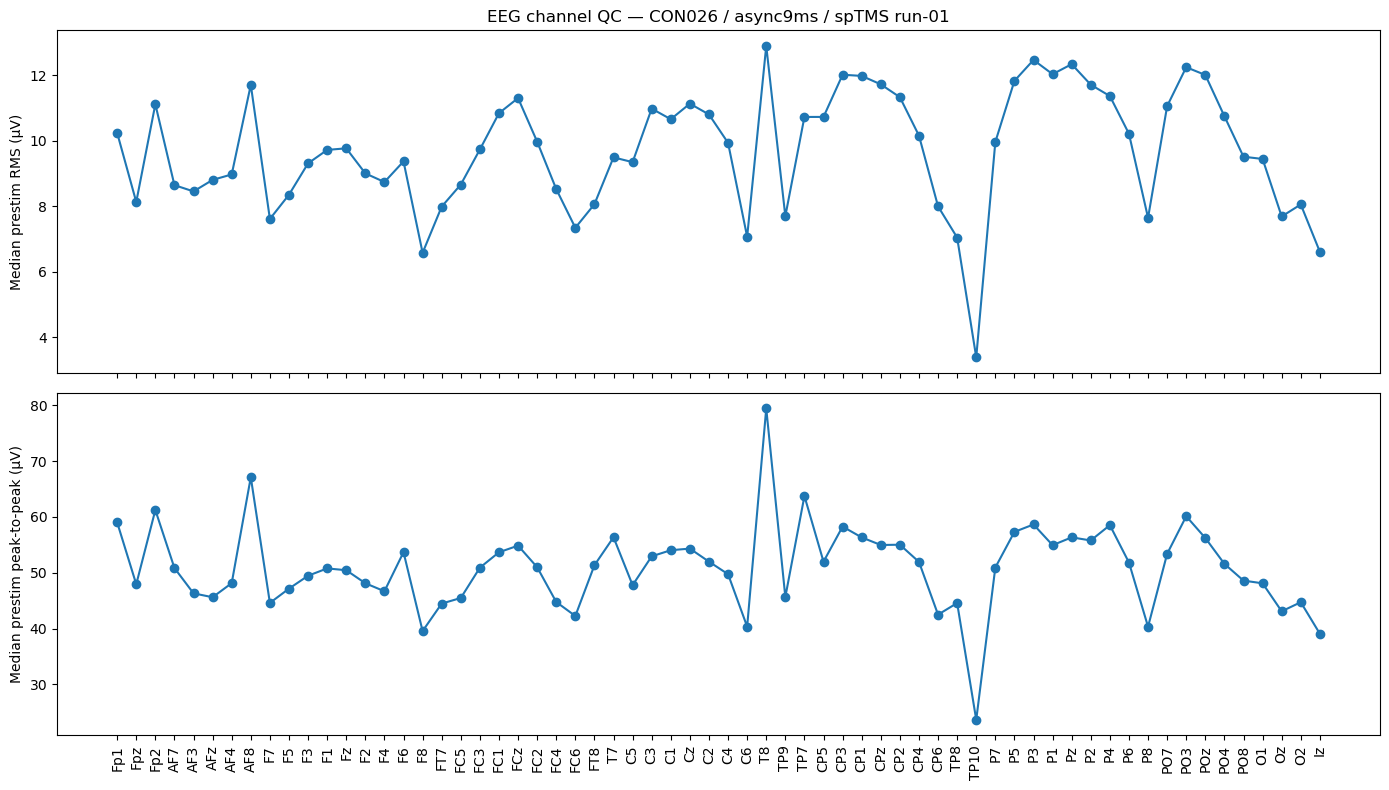


Possible high-noise channels (diagnostic rZ > 5):


,channel,median_rms_uv,median_sd_uv,median_p2p_uv,p95_p2p_uv,median_maxabs_uv,p95_maxabs_uv,rz_rms,rz_p2p,rz_maxabs



Possible unusually flat channels (diagnostic rZ < -5):


,channel,median_rms_uv,median_sd_uv,median_p2p_uv,p95_p2p_uv,median_maxabs_uv,p95_maxabs_uv,rz_rms,rz_p2p,rz_maxabs


In [60]:
# ============================================================
# LEVEL-1 / CELL 3
# Channel-level QC diagnostics
#
# Paper order:
#   detrend -> visual inspection -> bad channels -> bad trials
#
# This cell ONLY computes diagnostics.
# Nothing is rejected yet.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# EEG channels only for neural-channel QC
# Auxiliary EMG/EOG/ECG are retained, but should not be judged
# using EEG amplitude criteria.
# ------------------------------------------------------------

eeg_idx = np.array([
    i for i, typ in enumerate(epochs_l1.get_channel_types())
    if typ == "eeg"
])

eeg_ch_names = np.array(epochs_l1.ch_names)[eeg_idx]

print("EEG channels:", len(eeg_idx))

# ------------------------------------------------------------
# QC windows
#
# Prestimulus interval avoids TMS completely.
# Paper later uses -200 to +100 ms for trial QC,
# but channel noise is easiest to interpret prestimulus.
# ------------------------------------------------------------

pre_qc_mask = (
    (times_l1 >= -0.200) &
    (times_l1 <= -0.010)
)

# For a second metric, use paper's QC interval but
# exclude immediate TMS artifact.
paper_qc_mask_no_pulse = (
    (times_l1 >= -0.200) &
    (times_l1 <=  0.100) &
    ~pulse_mask
)

# ------------------------------------------------------------
# Extract detrended EEG QC data
# ------------------------------------------------------------

X_pre = qc_data_dt[
    :,
    eeg_idx,
    :
][:, :, pre_qc_mask] * 1e6  # µV

X_paper = qc_data_dt[
    :,
    eeg_idx,
    :
][:, :, paper_qc_mask_no_pulse] * 1e6

# shapes:
# trial x channel x time
print("Prestim QC array:", X_pre.shape)
print("Paper-window QC array:", X_paper.shape)

# ------------------------------------------------------------
# Per-trial, per-channel metrics
# ------------------------------------------------------------

# RMS
trial_channel_rms = np.sqrt(
    np.mean(X_pre**2, axis=2)
)

# Peak-to-peak
trial_channel_p2p = np.ptp(
    X_pre,
    axis=2
)

# Standard deviation
trial_channel_sd = np.std(
    X_pre,
    axis=2
)

# Paper-window maximum absolute amplitude,
# excluding immediate pulse artifact
trial_channel_maxabs = np.max(
    np.abs(X_paper),
    axis=2
)

# ------------------------------------------------------------
# Collapse across 80 trials robustly
# ------------------------------------------------------------

channel_qc = pd.DataFrame({
    "channel": eeg_ch_names,

    "median_rms_uv":
        np.median(trial_channel_rms, axis=0),

    "median_sd_uv":
        np.median(trial_channel_sd, axis=0),

    "median_p2p_uv":
        np.median(trial_channel_p2p, axis=0),

    "p95_p2p_uv":
        np.percentile(
            trial_channel_p2p,
            95,
            axis=0
        ),

    "median_maxabs_uv":
        np.median(
            trial_channel_maxabs,
            axis=0
        ),

    "p95_maxabs_uv":
        np.percentile(
            trial_channel_maxabs,
            95,
            axis=0
        ),
})

# ------------------------------------------------------------
# Robust relative scores
# Not rejection thresholds — only ranking diagnostics.
# ------------------------------------------------------------

def robust_z(x):
    x = np.asarray(x, dtype=float)
    med = np.median(x)
    mad = np.median(np.abs(x - med))

    if mad == 0:
        return np.zeros_like(x)

    return 0.67448975 * (x - med) / mad


channel_qc["rz_rms"] = robust_z(
    channel_qc["median_rms_uv"]
)

channel_qc["rz_p2p"] = robust_z(
    channel_qc["median_p2p_uv"]
)

channel_qc["rz_maxabs"] = robust_z(
    channel_qc["median_maxabs_uv"]
)

# ------------------------------------------------------------
# Print extremes
# ------------------------------------------------------------

print("\nHighest median RMS channels:")
display(
    channel_qc
    .sort_values("median_rms_uv", ascending=False)
    .head(10)
)

print("\nLowest median RMS channels:")
display(
    channel_qc
    .sort_values("median_rms_uv", ascending=True)
    .head(10)
)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, axes = plt.subplots(
    2,
    1,
    figsize=(14, 8),
    sharex=True
)

axes[0].plot(
    np.arange(len(channel_qc)),
    channel_qc["median_rms_uv"],
    marker="o"
)

axes[0].set_ylabel(
    "Median prestim RMS (µV)"
)

axes[0].set_title(
    "EEG channel QC — CON026 / async9ms / spTMS run-01"
)

axes[1].plot(
    np.arange(len(channel_qc)),
    channel_qc["median_p2p_uv"],
    marker="o"
)

axes[1].set_ylabel(
    "Median prestim peak-to-peak (µV)"
)

axes[1].set_xticks(
    np.arange(len(channel_qc))
)

axes[1].set_xticklabels(
    channel_qc["channel"],
    rotation=90
)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Compact robust-outlier report
# Again: diagnostic only.
# ------------------------------------------------------------

possible_high_noise = channel_qc[
    (channel_qc["rz_rms"] > 5) |
    (channel_qc["rz_p2p"] > 5)
]

possible_flat = channel_qc[
    channel_qc["rz_rms"] < -5
]

print("\nPossible high-noise channels (diagnostic rZ > 5):")
display(possible_high_noise)

print("\nPossible unusually flat channels (diagnostic rZ < -5):")
display(possible_flat)

Samples:
  pre [-200,-10] ms       : 3801
  post [5,100] ms         : 1901
  paper excl. ±5 ms       : 5800

=== ±30 µV AMPLITUDE AUDIT ===

Prestimulus [-200,-10] ms
  median max |V|: 56.05016 µV
  95th percentile: 81.66423 µV
  trials > ±30 µV: 80 / 80

Post-TMS [5,100] ms
  median max |V|: 52.21444 µV
  95th percentile: 77.64777 µV
  trials > ±30 µV: 80 / 80

Paper window excluding ±5 ms
  median max |V|: 62.058693 µV
  95th percentile: 81.66423 µV
  trials > ±30 µV: 80 / 80

Channels exceeding ±30 µV per trial:
Prestimulus median: 26.0 max: 57
Post 5–100 ms median: 17.0 max: 46
Paper operational median: 31.0 max: 58

Most extreme trials:


,trial_id,maxabs_pre_uv,maxabs_post5_uv,maxabs_paper_uv,nch_gt30_pre,nch_gt30_post5,nch_gt30_paper,flag_pre_gt30,flag_post5_gt30,flag_paper_gt30
73,74,86.056480,157.045013,157.045013,40,36,44,True,True,True
49,50,106.492668,156.524460,156.524460,39,26,40,True,True,True
34,35,89.546043,101.726440,101.726440,14,9,16,True,True,True
64,65,84.161217,69.558884,84.161217,47,27,48,True,True,True
42,43,81.532822,43.688698,81.532822,48,14,49,True,True,True
38,39,56.218315,80.889267,80.889267,32,4,32,True,True,True
16,17,80.190651,76.671242,80.190651,25,15,27,True,True,True
0,1,62.653263,77.477188,77.477188,26,15,31,True,True,True
28,29,77.083649,51.335499,77.083649,51,26,53,True,True,True
68,69,74.262466,43.899334,74.262466,4,8,11,True,True,True


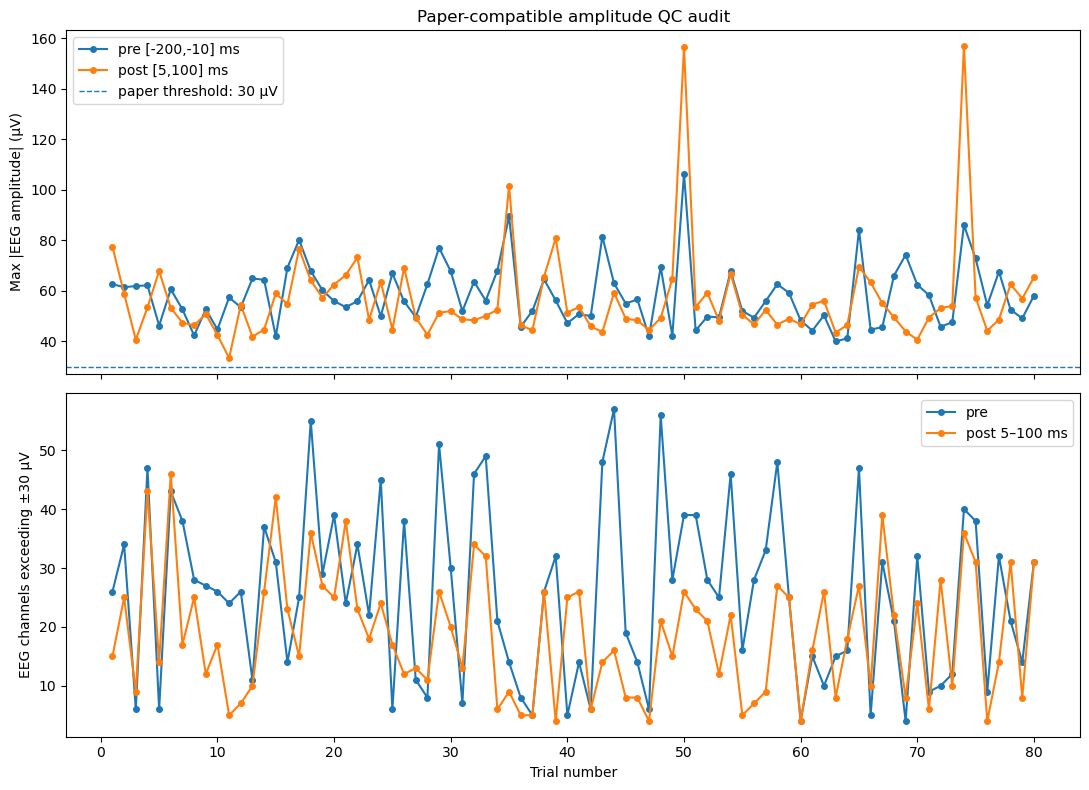

In [61]:
# ============================================================
# LEVEL-1 / CELL 4
# Audit the paper's ±30 µV bad-trial amplitude criterion
#
# IMPORTANT:
# - diagnostic only
# - NO trial is rejected here
# - EEG channels only
# - uses detrended QC copy
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PAPER_AMP_THRESHOLD_UV = 30.0

# ------------------------------------------------------------
# Three diagnostic windows
# ------------------------------------------------------------

mask_pre = (
    (times_l1 >= -0.200) &
    (times_l1 <= -0.010)
)

mask_post5 = (
    (times_l1 >= 0.005) &
    (times_l1 <= 0.100)
)

mask_paper_operational = (
    (times_l1 >= -0.200) &
    (times_l1 <= 0.100) &
    ~(
        (times_l1 >= -0.005) &
        (times_l1 <= 0.005)
    )
)

print("Samples:")
print("  pre [-200,-10] ms       :", mask_pre.sum())
print("  post [5,100] ms         :", mask_post5.sum())
print("  paper excl. ±5 ms       :", mask_paper_operational.sum())

# ------------------------------------------------------------
# EEG detrended data in µV
# trial × EEG channel × time
# ------------------------------------------------------------

qc_eeg_uv = (
    qc_data_dt[:, eeg_idx, :] * 1e6
)

# ------------------------------------------------------------
# Per-trial maximum absolute amplitude across
# ALL EEG channels and samples in each window
# ------------------------------------------------------------

def trial_maxabs(data_uv, mask):
    return np.max(
        np.abs(data_uv[:, :, mask]),
        axis=(1, 2)
    )

maxabs_pre = trial_maxabs(
    qc_eeg_uv,
    mask_pre
)

maxabs_post5 = trial_maxabs(
    qc_eeg_uv,
    mask_post5
)

maxabs_paper = trial_maxabs(
    qc_eeg_uv,
    mask_paper_operational
)

# ------------------------------------------------------------
# Also count how many EEG channels exceed ±30 µV
# in each trial.
# This is much more informative than a single max.
# ------------------------------------------------------------

def n_channels_exceed(data_uv, mask, threshold):
    max_per_channel = np.max(
        np.abs(data_uv[:, :, mask]),
        axis=2
    )

    return (
        max_per_channel > threshold
    ).sum(axis=1)

nch_pre = n_channels_exceed(
    qc_eeg_uv,
    mask_pre,
    PAPER_AMP_THRESHOLD_UV
)

nch_post5 = n_channels_exceed(
    qc_eeg_uv,
    mask_post5,
    PAPER_AMP_THRESHOLD_UV
)

nch_paper = n_channels_exceed(
    qc_eeg_uv,
    mask_paper_operational,
    PAPER_AMP_THRESHOLD_UV
)

# ------------------------------------------------------------
# Trial table
# ------------------------------------------------------------

trial_amp_qc = pd.DataFrame({
    "trial_id": np.arange(1, n_trials + 1),

    "maxabs_pre_uv":
        maxabs_pre,

    "maxabs_post5_uv":
        maxabs_post5,

    "maxabs_paper_uv":
        maxabs_paper,

    "nch_gt30_pre":
        nch_pre,

    "nch_gt30_post5":
        nch_post5,

    "nch_gt30_paper":
        nch_paper,

    "flag_pre_gt30":
        maxabs_pre > PAPER_AMP_THRESHOLD_UV,

    "flag_post5_gt30":
        maxabs_post5 > PAPER_AMP_THRESHOLD_UV,

    "flag_paper_gt30":
        maxabs_paper > PAPER_AMP_THRESHOLD_UV,
})

# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

print("\n=== ±30 µV AMPLITUDE AUDIT ===")

for label, values, flags in [
    (
        "Prestimulus [-200,-10] ms",
        maxabs_pre,
        trial_amp_qc["flag_pre_gt30"]
    ),
    (
        "Post-TMS [5,100] ms",
        maxabs_post5,
        trial_amp_qc["flag_post5_gt30"]
    ),
    (
        "Paper window excluding ±5 ms",
        maxabs_paper,
        trial_amp_qc["flag_paper_gt30"]
    ),
]:

    print(f"\n{label}")

    print(
        "  median max |V|:",
        np.median(values),
        "µV"
    )

    print(
        "  95th percentile:",
        np.percentile(values, 95),
        "µV"
    )

    print(
        "  trials > ±30 µV:",
        int(flags.sum()),
        "/",
        n_trials
    )

# ------------------------------------------------------------
# Distribution of number of violating channels
# ------------------------------------------------------------

print("\nChannels exceeding ±30 µV per trial:")

print(
    "Prestimulus median:",
    np.median(nch_pre),
    "max:",
    nch_pre.max()
)

print(
    "Post 5–100 ms median:",
    np.median(nch_post5),
    "max:",
    nch_post5.max()
)

print(
    "Paper operational median:",
    np.median(nch_paper),
    "max:",
    nch_paper.max()
)

# ------------------------------------------------------------
# Show the most extreme trials
# ------------------------------------------------------------

print("\nMost extreme trials:")
display(
    trial_amp_qc
    .sort_values(
        "maxabs_paper_uv",
        ascending=False
    )
    .head(15)
)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, axes = plt.subplots(
    2,
    1,
    figsize=(11, 8),
    sharex=True
)

trial_no = np.arange(1, n_trials + 1)

axes[0].plot(
    trial_no,
    maxabs_pre,
    marker="o",
    markersize=4,
    label="pre [-200,-10] ms"
)

axes[0].plot(
    trial_no,
    maxabs_post5,
    marker="o",
    markersize=4,
    label="post [5,100] ms"
)

axes[0].axhline(
    PAPER_AMP_THRESHOLD_UV,
    linestyle="--",
    linewidth=1,
    label="paper threshold: 30 µV"
)

axes[0].set_ylabel(
    "Max |EEG amplitude| (µV)"
)

axes[0].set_title(
    "Paper-compatible amplitude QC audit"
)

axes[0].legend()

axes[1].plot(
    trial_no,
    nch_pre,
    marker="o",
    markersize=4,
    label="pre"
)

axes[1].plot(
    trial_no,
    nch_post5,
    marker="o",
    markersize=4,
    label="post 5–100 ms"
)

axes[1].set_xlabel(
    "Trial number"
)

axes[1].set_ylabel(
    "EEG channels exceeding ±30 µV"
)

axes[1].legend()

plt.tight_layout()
plt.show()

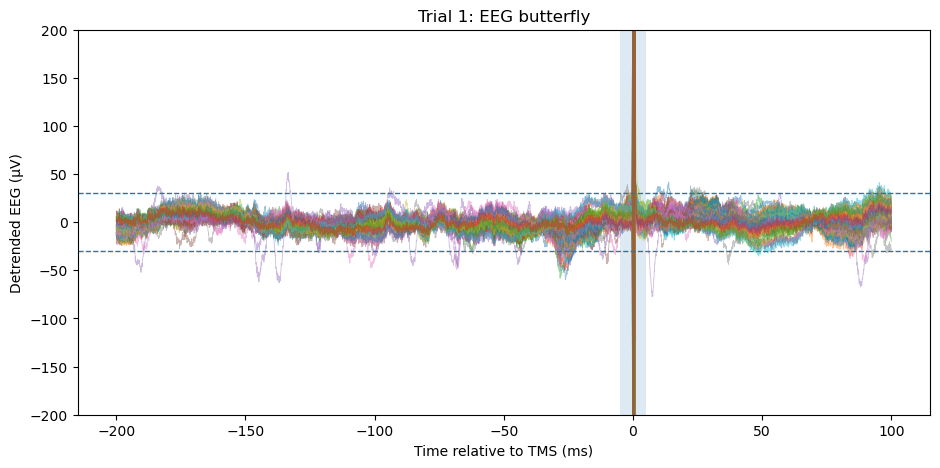

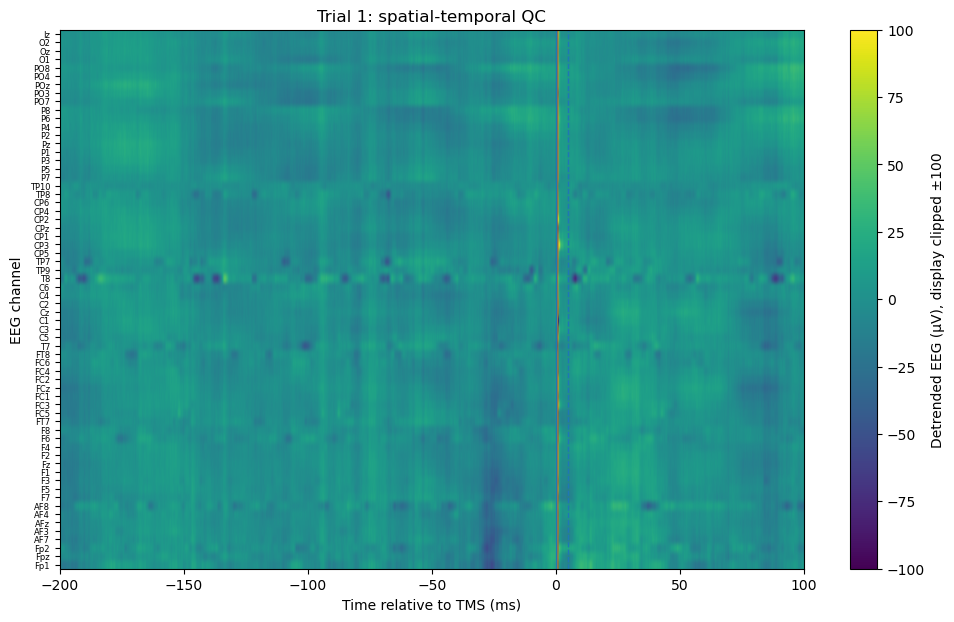

Trial 1:
  pre max |V| = 62.653263 µV
  post max |V| = 77.47719 µV



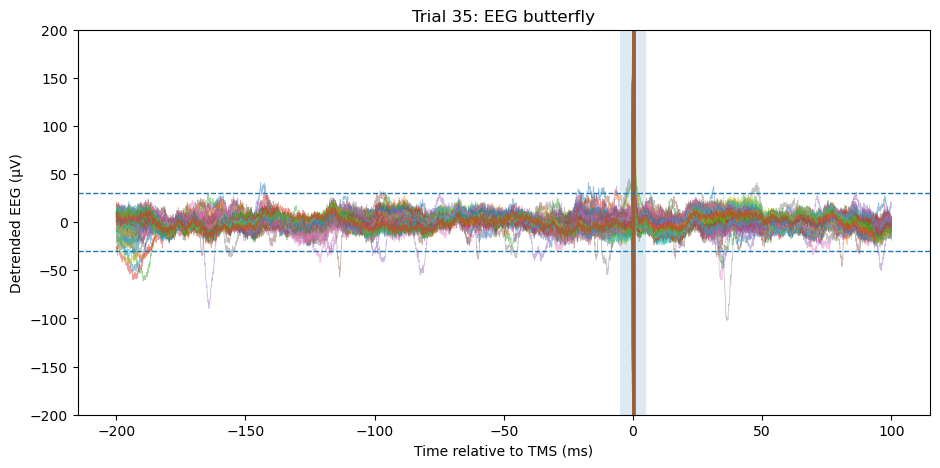

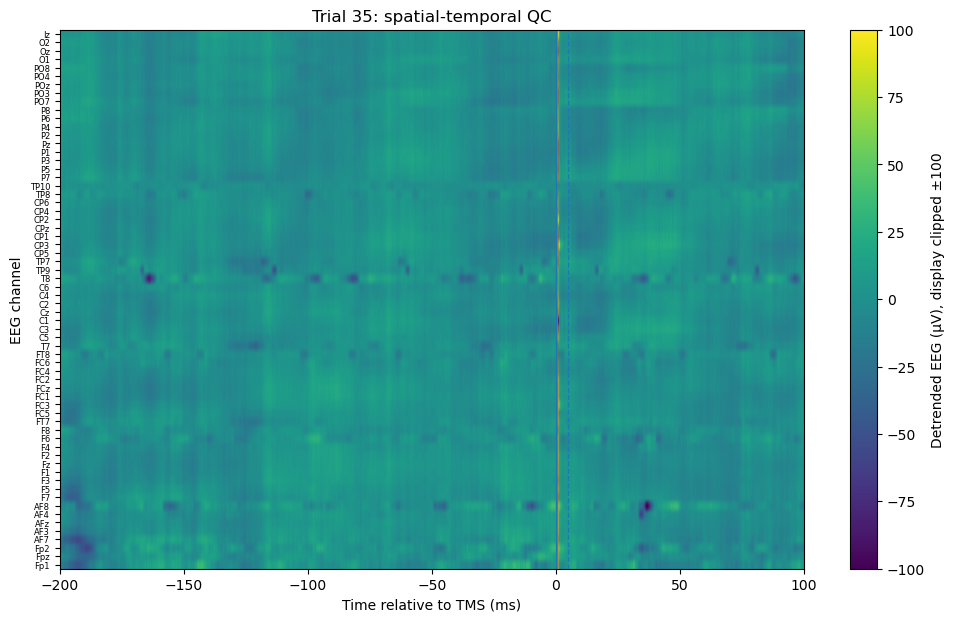

Trial 35:
  pre max |V| = 89.54604 µV
  post max |V| = 101.72644 µV



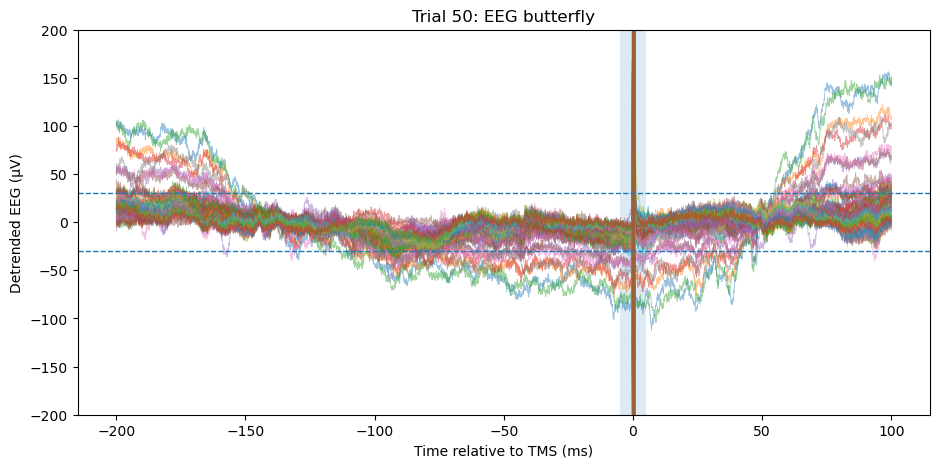

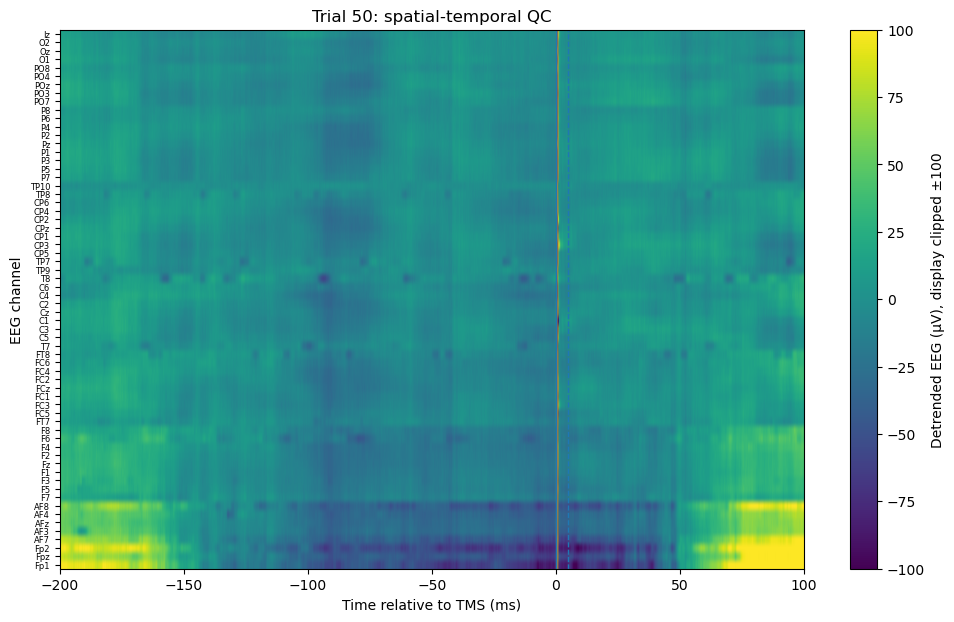

Trial 50:
  pre max |V| = 106.49267 µV
  post max |V| = 156.52446 µV



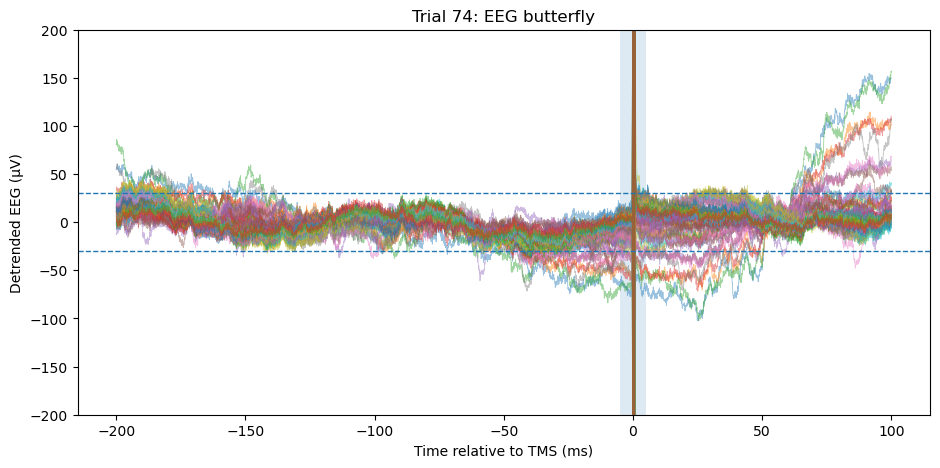

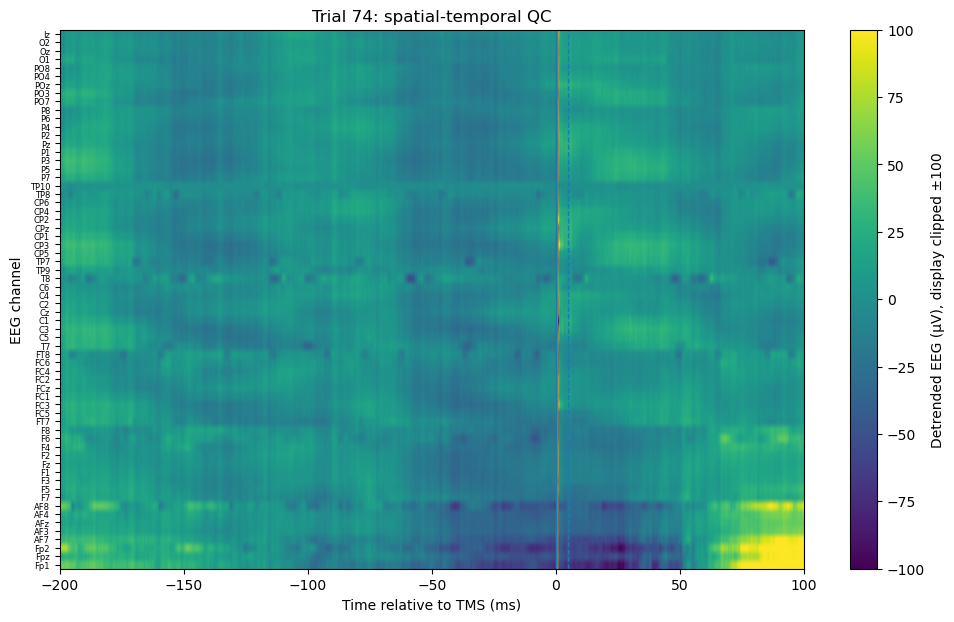

Trial 74:
  pre max |V| = 86.05648 µV
  post max |V| = 157.04501 µV



In [62]:
# ============================================================
# LEVEL-1 / CELL 5
# Paper-style visual trial inspection
#
# No rejection yet.
# Uses detrended QC copy only.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

inspect_trials = [1, 35, 50, 74]

# Original paper's visual QC interval
vis_mask = (
    (times_l1 >= -0.200) &
    (times_l1 <= 0.100)
)

vis_times_ms = times_l1[vis_mask] * 1000

# EEG only, µV
qc_eeg_uv = (
    qc_data_dt[:, eeg_idx, :] * 1e6
)

for trial_id in inspect_trials:

    idx = trial_id - 1

    x = qc_eeg_uv[
        idx,
        :,
        :
    ][:, vis_mask]

    # --------------------------------------------------------
    # 1. Butterfly plot
    # --------------------------------------------------------

    plt.figure(figsize=(11, 5))

    for ch_data in x:
        plt.plot(
            vis_times_ms,
            ch_data,
            linewidth=0.6,
            alpha=0.45
        )

    plt.axvspan(
        -5,
        5,
        alpha=0.15,
        label="TMS pulse region"
    )

    plt.axhline(
        30,
        linestyle="--",
        linewidth=1
    )

    plt.axhline(
        -30,
        linestyle="--",
        linewidth=1
    )

    plt.xlabel("Time relative to TMS (ms)")
    plt.ylabel("Detrended EEG (µV)")

    plt.title(
        f"Trial {trial_id}: EEG butterfly"
    )

    plt.ylim(-200, 200)
    plt.show()

    # --------------------------------------------------------
    # 2. Channel × time heatmap
    # Clip only for DISPLAY, not data.
    # --------------------------------------------------------

    plt.figure(figsize=(12, 7))

    plt.imshow(
        np.clip(x, -100, 100),
        aspect="auto",
        origin="lower",
        extent=[
            vis_times_ms[0],
            vis_times_ms[-1],
            0,
            len(eeg_ch_names)
        ]
    )

    plt.axvline(
        0,
        linewidth=1
    )

    plt.axvline(
        5,
        linestyle="--",
        linewidth=1
    )

    plt.yticks(
        np.arange(len(eeg_ch_names)) + 0.5,
        eeg_ch_names,
        fontsize=6
    )

    plt.xlabel("Time relative to TMS (ms)")
    plt.ylabel("EEG channel")

    plt.title(
        f"Trial {trial_id}: spatial-temporal QC"
    )

    plt.colorbar(
        label="Detrended EEG (µV), display clipped ±100"
    )

    plt.show()

    # --------------------------------------------------------
    # Numerical summary
    # --------------------------------------------------------

    pre_mask_local = (
        (vis_times_ms >= -200) &
        (vis_times_ms <= -10)
    )

    post_mask_local = (
        (vis_times_ms >= 5) &
        (vis_times_ms <= 100)
    )

    print(
        f"Trial {trial_id}:"
    )

    print(
        "  pre max |V| =",
        np.max(
            np.abs(x[:, pre_mask_local])
        ),
        "µV"
    )

    print(
        "  post max |V| =",
        np.max(
            np.abs(x[:, post_mask_local])
        ),
        "µV"
    )

    print()

EEG array shape: (80, 64, 16001)
Pre samples: 3801
Post samples: 1901

Sanity checks:
max simultaneous PRE: 40
max simultaneous POST: 29
max possible PRE duration: 190.04999999999998 ms
observed max PRE widespread duration: 22.75 ms

Top trials by longest widespread PRE excursion:


,trial_id,max_simultaneous_pre,frac_time_widespread_pre,longest_widespread_ms_pre,max_spatial_median_abs_pre_uv,p95_spatial_median_abs_pre_uv,max_simultaneous_post,frac_time_widespread_post,longest_widespread_ms_post,max_spatial_median_abs_post_uv,p95_spatial_median_abs_post_uv,VEOG_pre_p2p_uv,HEOG_pre_p2p_uv
42,43,36,0.165483,22.75,32.720417,20.830540,7,0.000000,0.00,10.454517,7.720363,29.876701,35.912888
47,48,40,0.117074,20.85,35.549858,28.922916,5,0.000000,0.00,14.441017,11.280984,27.885473,31.785156
17,18,37,0.216785,19.80,31.961262,28.277151,24,0.097317,3.45,27.316494,21.996983,30.937347,39.981682
74,75,29,0.118653,18.20,23.850517,17.954851,20,0.081010,0.75,20.669245,17.055370,33.766148,42.003525
57,58,33,0.171008,10.35,30.279808,25.245766,13,0.000000,0.00,22.460838,16.430323,26.305191,35.264034
64,65,25,0.091555,9.80,24.569483,19.797112,21,0.004208,0.15,25.865437,19.420528,114.342918,67.666061
6,7,26,0.060773,6.50,24.957901,20.319658,8,0.000000,0.00,17.732834,12.210099,25.138664,28.395390
28,29,23,0.103394,5.90,28.141621,19.362015,14,0.000000,0.00,22.133078,16.295887,36.708981,41.718960
49,50,24,0.018679,1.85,27.125650,20.242138,24,0.093635,4.60,19.331551,15.614403,131.032104,53.425606
43,44,25,0.028150,1.60,25.058702,20.185688,5,0.000000,0.00,15.794132,12.831781,41.605881,24.730831



Selected visual-audit trials:


,trial_id,max_simultaneous_pre,frac_time_widespread_pre,longest_widespread_ms_pre,max_spatial_median_abs_pre_uv,p95_spatial_median_abs_pre_uv,max_simultaneous_post,frac_time_widespread_post,longest_widespread_ms_post,max_spatial_median_abs_post_uv,p95_spatial_median_abs_post_uv,VEOG_pre_p2p_uv,HEOG_pre_p2p_uv
0,1,14,0.000000,0.00,18.454565,10.401566,6,0.000000,0.00,14.489097,11.737660,38.850311,48.583748
34,35,7,0.000000,0.00,13.877959,8.937880,4,0.000000,0.00,10.261321,8.573442,40.573803,70.224815
49,50,24,0.018679,1.85,27.125650,20.242138,24,0.093635,4.60,19.331551,15.614403,131.032104,53.425606
73,74,18,0.007366,0.25,25.850048,19.464062,16,0.000526,0.05,18.138935,14.905224,104.961487,45.299957


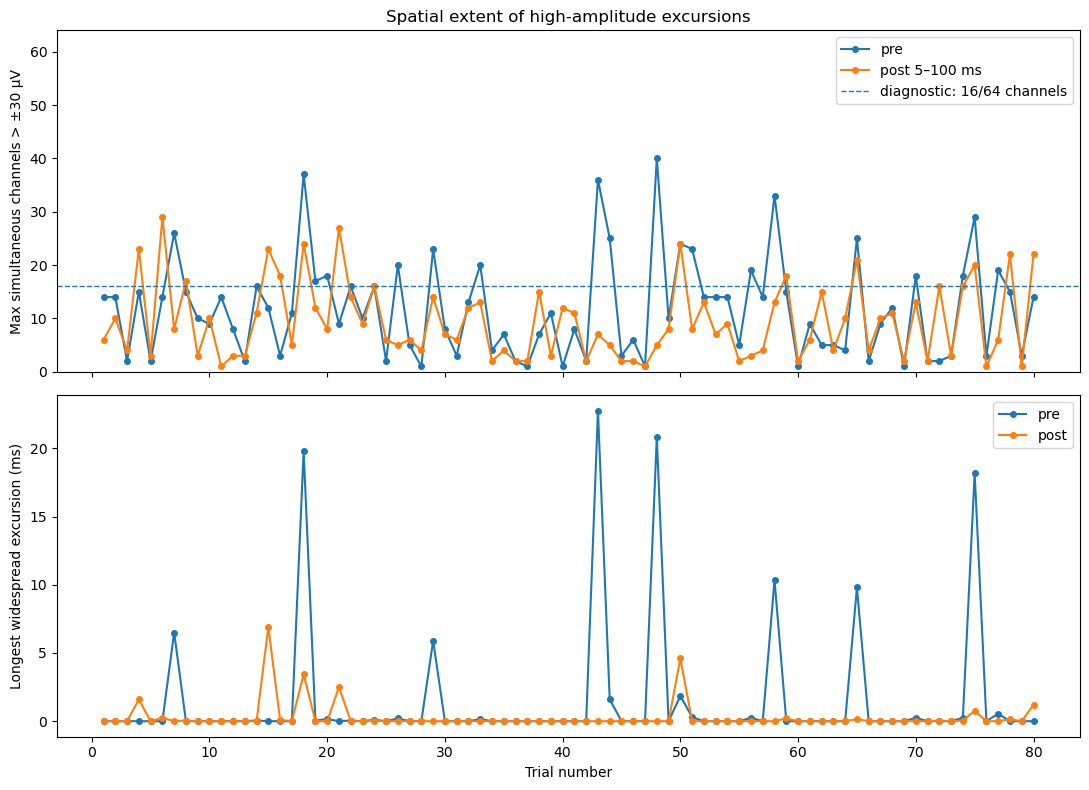

In [64]:
# ============================================================
# LEVEL-1 / CELL 6 — CORRECTED
# Quantify widespread / sustained EEG excursions
#
# Diagnostic only — NO rejection.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

AMP_UV = 30.0
N_WIDESPREAD = 16   # diagnostic only: 25% of 64 EEG channels

# ------------------------------------------------------------
# Windows
# ------------------------------------------------------------

pre_mask = (
    (times_l1 >= -0.200) &
    (times_l1 <= -0.010)
)

post_mask = (
    (times_l1 >= 0.005) &
    (times_l1 <= 0.100)
)

# detrended EEG only, µV
# shape = trial × channel × time
eeg_uv = qc_data_dt[:, eeg_idx, :] * 1e6

print("EEG array shape:", eeg_uv.shape)
print("Pre samples:", pre_mask.sum())
print("Post samples:", post_mask.sum())


# ------------------------------------------------------------
# Helper
# ------------------------------------------------------------

def longest_true_run_ms(mask_1d, sfreq):

    mask_1d = np.asarray(
        mask_1d,
        dtype=bool
    )

    if not np.any(mask_1d):
        return 0.0

    padded = np.concatenate([
        [False],
        mask_1d,
        [False]
    ])

    changes = np.diff(
        padded.astype(int)
    )

    starts = np.where(
        changes == 1
    )[0]

    stops = np.where(
        changes == -1
    )[0]

    longest_samples = np.max(
        stops - starts
    )

    return (
        longest_samples
        / sfreq
        * 1000
    )


# ------------------------------------------------------------
# Morphological metrics
# ------------------------------------------------------------

rows = []

for tr in range(n_trials):

    row = {
        "trial_id": tr + 1
    }

    for label, mask in [
        ("pre", pre_mask),
        ("post", post_mask)
    ]:

        # IMPORTANT:
        # first select trial, THEN select time.
        #
        # Guaranteed shape:
        # (64 EEG channels, n_time_samples)
        x = eeg_uv[tr][:, mask]

        if x.shape[0] != 64:
            raise RuntimeError(
                f"Unexpected EEG axis shape: {x.shape}"
            )

        # channel × time
        exceed = (
            np.abs(x) > AMP_UV
        )

        # number of channels above threshold
        # at each time sample
        n_simultaneous = exceed.sum(
            axis=0
        )

        # sanity check
        if n_simultaneous.max() > 64:
            raise RuntimeError(
                "Simultaneous-channel count exceeds 64"
            )

        widespread = (
            n_simultaneous
            >= N_WIDESPREAD
        )

        row[
            f"max_simultaneous_{label}"
        ] = int(
            n_simultaneous.max()
        )

        row[
            f"frac_time_widespread_{label}"
        ] = float(
            widespread.mean()
        )

        row[
            f"longest_widespread_ms_{label}"
        ] = longest_true_run_ms(
            widespread,
            sfreq
        )

        # At each time point:
        # median absolute signal across 64 channels.
        # Large values indicate spatially broad excursions.
        spatial_median_abs = np.median(
            np.abs(x),
            axis=0
        )

        row[
            f"max_spatial_median_abs_{label}_uv"
        ] = float(
            spatial_median_abs.max()
        )

        # 95th percentile gives a less extreme version
        row[
            f"p95_spatial_median_abs_{label}_uv"
        ] = float(
            np.percentile(
                spatial_median_abs,
                95
            )
        )

    rows.append(row)


morph_qc = pd.DataFrame(rows)


# ------------------------------------------------------------
# Add EOG diagnostics
# ------------------------------------------------------------

for ch in ["VEOG", "HEOG"]:

    if ch not in epochs_l1.ch_names:
        continue

    ch_idx = epochs_l1.ch_names.index(ch)

    x_all = (
        qc_data_dt[:, ch_idx, :]
        * 1e6
    )

    pre_p2p = []

    for tr in range(n_trials):

        # x_all[tr] first, same safe indexing convention
        x = x_all[tr][pre_mask]

        pre_p2p.append(
            np.ptp(x)
        )

    morph_qc[
        f"{ch}_pre_p2p_uv"
    ] = pre_p2p


# ------------------------------------------------------------
# Sanity check ranges
# ------------------------------------------------------------

print("\nSanity checks:")

print(
    "max simultaneous PRE:",
    morph_qc[
        "max_simultaneous_pre"
    ].max()
)

print(
    "max simultaneous POST:",
    morph_qc[
        "max_simultaneous_post"
    ].max()
)

print(
    "max possible PRE duration:",
    pre_mask.sum() / sfreq * 1000,
    "ms"
)

print(
    "observed max PRE widespread duration:",
    morph_qc[
        "longest_widespread_ms_pre"
    ].max(),
    "ms"
)


# ------------------------------------------------------------
# Rank
# ------------------------------------------------------------

print(
    "\nTop trials by longest widespread PRE excursion:"
)

display(
    morph_qc
    .sort_values(
        [
            "longest_widespread_ms_pre",
            "max_simultaneous_pre",
            "max_spatial_median_abs_pre_uv"
        ],
        ascending=False
    )
    .head(15)
)


print(
    "\nSelected visual-audit trials:"
)

display(
    morph_qc[
        morph_qc["trial_id"].isin(
            [1, 35, 50, 74]
        )
    ]
)


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

trial_no = morph_qc["trial_id"]

fig, axes = plt.subplots(
    2,
    1,
    figsize=(11, 8),
    sharex=True
)

axes[0].plot(
    trial_no,
    morph_qc[
        "max_simultaneous_pre"
    ],
    marker="o",
    markersize=4,
    label="pre"
)

axes[0].plot(
    trial_no,
    morph_qc[
        "max_simultaneous_post"
    ],
    marker="o",
    markersize=4,
    label="post 5–100 ms"
)

axes[0].axhline(
    N_WIDESPREAD,
    linestyle="--",
    linewidth=1,
    label="diagnostic: 16/64 channels"
)

axes[0].set_ylim(0, 64)

axes[0].set_ylabel(
    "Max simultaneous channels > ±30 µV"
)

axes[0].set_title(
    "Spatial extent of high-amplitude excursions"
)

axes[0].legend()


axes[1].plot(
    trial_no,
    morph_qc[
        "longest_widespread_ms_pre"
    ],
    marker="o",
    markersize=4,
    label="pre"
)

axes[1].plot(
    trial_no,
    morph_qc[
        "longest_widespread_ms_post"
    ],
    marker="o",
    markersize=4,
    label="post"
)

axes[1].set_xlabel(
    "Trial number"
)

axes[1].set_ylabel(
    "Longest widespread excursion (ms)"
)

axes[1].legend()

plt.tight_layout()
plt.show()

EOG QC samples: 5800

EOG metric summary:

VEOG
median: 35.855003 µV
95th percentile: 61.971416 µV
max: 189.14837646484375 µV

HEOG
median: 35.485325 µV
95th percentile: 67.69657 µV
max: 89.90225219726562 µV

Ocular candidates: 6 / 80

Top ocular-artifact candidates:


,trial_id,VEOG_p2p_qc_uv,VEOG_p2p_pre_uv,VEOG_maxabs_qc_uv,VEOG_maxdiff_uv_per_sample,HEOG_p2p_qc_uv,HEOG_p2p_pre_uv,HEOG_maxabs_qc_uv,HEOG_maxdiff_uv_per_sample,VEOG_rz,HEOG_rz,ocular_rz_max,ocular_candidate
49,50,189.148376,131.032104,113.135590,7.843216,89.902252,53.425606,46.966835,5.468035,23.244134,11.408061,23.244134,True
73,74,160.241211,104.961487,103.162025,11.346785,67.493134,45.299957,35.335384,5.572294,18.860892,6.710174,18.860892,True
64,65,114.342918,114.342918,65.512833,5.478935,67.666061,67.666061,35.450413,11.766749,11.901256,6.746427,11.901256,True
66,67,35.897278,34.609962,17.981270,5.567075,70.987000,61.448997,35.684769,12.113342,0.006410,7.442634,7.442634,True
34,35,70.658173,40.573803,50.302349,12.510754,70.224815,70.224815,49.516434,6.119106,5.277263,7.282848,7.282848,True
11,12,49.498009,22.451532,25.688759,9.327285,68.276299,68.276299,41.396152,8.624511,2.068712,6.874358,6.874358,True
53,54,61.514263,61.514263,38.121174,19.083050,38.393631,35.000210,23.357292,7.199341,3.890757,0.609702,3.890757,False
79,80,49.953362,36.411560,31.274023,6.678749,53.078335,41.209427,28.955856,6.305324,2.137758,3.688230,3.688230,False
38,39,52.152672,52.152672,32.618198,5.401656,53.056465,50.357674,31.515898,12.708275,2.471243,3.683645,3.683645,False
25,26,47.085445,45.866600,25.745672,5.259705,51.440384,51.440384,27.286444,9.399832,1.702891,3.344847,3.344847,False



Trials 1 / 35 / 50 / 65 / 74:


,trial_id,VEOG_p2p_qc_uv,VEOG_p2p_pre_uv,VEOG_maxabs_qc_uv,VEOG_maxdiff_uv_per_sample,HEOG_p2p_qc_uv,HEOG_p2p_pre_uv,HEOG_maxabs_qc_uv,HEOG_maxdiff_uv_per_sample,VEOG_rz,HEOG_rz,ocular_rz_max,ocular_candidate
0,1,43.208069,38.850311,22.549862,6.973840,50.462734,48.583748,25.860044,6.444550,1.114958,3.139891,3.139891,False
34,35,70.658173,40.573803,50.302349,12.510754,70.224815,70.224815,49.516434,6.119106,5.277263,7.282848,7.282848,True
49,50,189.148376,131.032104,113.135590,7.843216,89.902252,53.425606,46.966835,5.468035,23.244134,11.408061,23.244134,True
64,65,114.342918,114.342918,65.512833,5.478935,67.666061,67.666061,35.450413,11.766749,11.901256,6.746427,11.901256,True
73,74,160.241211,104.961487,103.162025,11.346785,67.493134,45.299957,35.335384,5.572294,18.860892,6.710174,18.860892,True


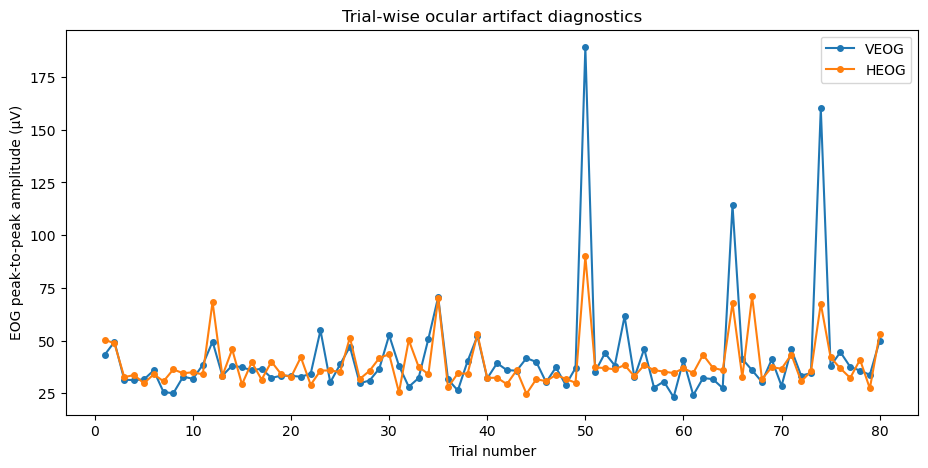

In [65]:
# ============================================================
# LEVEL-1 / CELL 7
# EOG-based ocular-artifact diagnostics
#
# Goal:
# identify candidate blink / eye-movement trials in a
# reproducible way while preserving all trials.
#
# NO rejection yet.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# QC interval follows the paper:
# -200 to +100 ms
#
# Exclude ±5 ms only so the TMS pulse itself cannot dominate
# the EOG metric.
# ------------------------------------------------------------

eog_qc_mask = (
    (times_l1 >= -0.200) &
    (times_l1 <= 0.100) &
    ~(
        (times_l1 >= -0.005) &
        (times_l1 <= 0.005)
    )
)

eog_pre_mask = (
    (times_l1 >= -0.200) &
    (times_l1 <= -0.010)
)

print(
    "EOG QC samples:",
    eog_qc_mask.sum()
)

# ------------------------------------------------------------
# Robust z helper
# ------------------------------------------------------------

def robust_z(x):

    x = np.asarray(x, dtype=float)

    med = np.median(x)

    mad = np.median(
        np.abs(x - med)
    )

    if mad == 0:
        return np.zeros_like(x)

    return (
        0.67448975
        * (x - med)
        / mad
    )


# ------------------------------------------------------------
# Calculate trial-wise EOG metrics
# ------------------------------------------------------------

eog_rows = []

for tr in range(n_trials):

    row = {
        "trial_id": tr + 1
    }

    for ch in ["VEOG", "HEOG"]:

        if ch not in epochs_l1.ch_names:
            continue

        ch_idx = epochs_l1.ch_names.index(ch)

        x = (
            qc_data_dt[tr, ch_idx, :]
            * 1e6
        )

        x_qc = x[eog_qc_mask]
        x_pre = x[eog_pre_mask]

        row[f"{ch}_p2p_qc_uv"] = (
            np.ptp(x_qc)
        )

        row[f"{ch}_p2p_pre_uv"] = (
            np.ptp(x_pre)
        )

        row[f"{ch}_maxabs_qc_uv"] = (
            np.max(np.abs(x_qc))
        )

        # temporal derivative:
        # useful for sharp blink / eye-movement transients
        dx = np.diff(x_qc)

        row[f"{ch}_maxdiff_uv_per_sample"] = (
            np.max(np.abs(dx))
        )

    eog_rows.append(row)


eog_qc = pd.DataFrame(eog_rows)


# ------------------------------------------------------------
# Robust relative scores across the 80 trials
# ------------------------------------------------------------

for ch in ["VEOG", "HEOG"]:

    col = f"{ch}_p2p_qc_uv"

    if col in eog_qc.columns:

        eog_qc[f"{ch}_rz"] = robust_z(
            eog_qc[col]
        )


# ------------------------------------------------------------
# Combined ocular score
#
# Diagnostic only:
# take the more extreme of VEOG / HEOG robust scores.
# ------------------------------------------------------------

rz_cols = [
    c for c in [
        "VEOG_rz",
        "HEOG_rz"
    ]
    if c in eog_qc.columns
]

eog_qc["ocular_rz_max"] = (
    eog_qc[rz_cols]
    .max(axis=1)
)


# ------------------------------------------------------------
# Candidate flag
#
# rZ > 5 is a conservative anomaly flag,
# NOT yet the final bad-trial criterion.
# ------------------------------------------------------------

EOG_RZ_CANDIDATE = 5.0

eog_qc["ocular_candidate"] = (
    eog_qc["ocular_rz_max"]
    > EOG_RZ_CANDIDATE
)


# ------------------------------------------------------------
# Print distribution
# ------------------------------------------------------------

print("\nEOG metric summary:")

for ch in ["VEOG", "HEOG"]:

    col = f"{ch}_p2p_qc_uv"

    if col in eog_qc.columns:

        print(f"\n{ch}")

        print(
            "median:",
            np.median(eog_qc[col]),
            "µV"
        )

        print(
            "95th percentile:",
            np.percentile(
                eog_qc[col],
                95
            ),
            "µV"
        )

        print(
            "max:",
            eog_qc[col].max(),
            "µV"
        )


print(
    "\nOcular candidates:",
    int(
        eog_qc[
            "ocular_candidate"
        ].sum()
    ),
    "/",
    n_trials
)


print(
    "\nTop ocular-artifact candidates:"
)

display(
    eog_qc
    .sort_values(
        "ocular_rz_max",
        ascending=False
    )
    .head(15)
)


print(
    "\nTrials 1 / 35 / 50 / 65 / 74:"
)

display(
    eog_qc[
        eog_qc["trial_id"].isin(
            [1, 35, 50, 65, 74]
        )
    ]
)


# ------------------------------------------------------------
# Merge with morphology diagnostics for inspection
# ------------------------------------------------------------

qc_joint = morph_qc.merge(
    eog_qc,
    on="trial_id",
    how="left"
)


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(figsize=(11, 5))

if "VEOG_p2p_qc_uv" in eog_qc:

    plt.plot(
        eog_qc["trial_id"],
        eog_qc["VEOG_p2p_qc_uv"],
        marker="o",
        markersize=4,
        label="VEOG"
    )

if "HEOG_p2p_qc_uv" in eog_qc:

    plt.plot(
        eog_qc["trial_id"],
        eog_qc["HEOG_p2p_qc_uv"],
        marker="o",
        markersize=4,
        label="HEOG"
    )

plt.xlabel(
    "Trial number"
)

plt.ylabel(
    "EOG peak-to-peak amplitude (µV)"
)

plt.title(
    "Trial-wise ocular artifact diagnostics"
)

plt.legend()

plt.show()

Filter segment: -0.4 to -0.005 s
Measurement samples: 3801

High-frequency RMS summary:
median across trials: 1.6419661499887817 µV
95th percentile: 2.042263916137953 µV
max: 2.4056286745100968 µV

Muscle candidates: 0 / 80

Top muscle-artifact candidates:


,trial_id,hf_rms_median_uv,hf_rms_p90_uv,hf_rms_max_uv,hf_rms_channel_iqr_uv,hf_rz_median,hf_rz_p90,muscle_rz_max,muscle_candidate
37,38,1.932597,4.350004,8.675509,0.289124,0.755262,1.997395,1.997395,False
1,2,2.405629,3.717267,7.134631,0.433831,1.984526,0.652446,1.984526,False
29,30,1.898944,4.295856,9.039829,1.153280,0.667807,1.882297,1.882297,False
16,17,1.876939,4.247714,13.149045,0.680090,0.610622,1.779967,1.779967,False
0,1,2.041336,4.183888,11.554563,0.988416,1.037841,1.644297,1.644297,False
41,42,2.232223,3.672278,7.877022,0.314711,1.533898,0.556818,1.533898,False
43,44,1.854780,4.123692,8.485353,0.325067,0.553038,1.516344,1.516344,False
18,19,2.215389,3.591858,7.797272,0.200535,1.490151,0.385876,1.490151,False
66,67,1.337238,4.029488,7.357155,0.580302,-0.791897,1.316104,1.316104,False
5,6,1.990518,3.995737,7.777210,0.586489,0.905781,1.244363,1.244363,False



Trials 1 / 12 / 35 / 43 / 48 / 50 / 65 / 67 / 74:


,trial_id,hf_rms_median_uv,hf_rms_p90_uv,hf_rms_max_uv,hf_rms_channel_iqr_uv,hf_rz_median,hf_rz_p90,muscle_rz_max,muscle_candidate
0,1,2.041336,4.183888,11.554563,0.988416,1.037841,1.644297,1.644297,False
11,12,1.893882,3.485965,8.623975,0.713034,0.654653,0.160789,0.654653,False
34,35,1.863944,3.734618,8.770384,0.478760,0.576854,0.689327,0.689327,False
42,43,1.639207,3.660069,6.484483,0.328786,-0.007170,0.530865,0.530865,False
47,48,1.299801,2.978826,7.174894,0.550522,-0.889182,-0.917187,-0.889182,False
49,50,1.584888,3.557781,6.480788,0.641893,-0.148330,0.313443,0.313443,False
64,65,1.478461,3.401721,6.453671,0.555206,-0.424900,-0.018280,-0.018280,False
66,67,1.337238,4.029488,7.357155,0.580302,-0.791897,1.316104,1.316104,False
73,74,1.922428,3.528244,7.770235,0.515494,0.728835,0.250659,0.728835,False


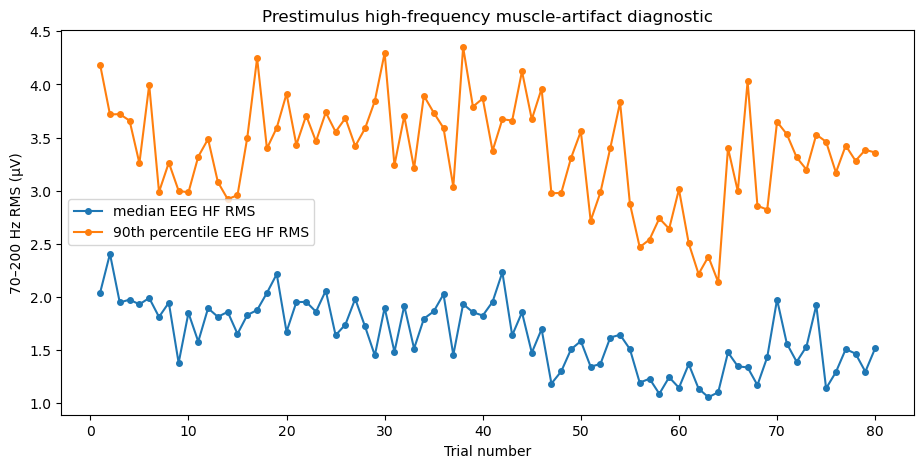

In [66]:
# ============================================================
# LEVEL-1 / CELL 8
# Prestimulus high-frequency muscle-artifact diagnostics
#
# Temporary QC transformation only.
# Nothing is filtered or altered in epochs_l1.
# Nothing is rejected.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import butter, sosfiltfilt

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

MUSCLE_FMIN = 70.0
MUSCLE_FMAX = 200.0

MUSCLE_RZ_CANDIDATE = 5.0

# We use a wider segment for filtering, then measure only
# the central [-200,-10] ms interval to reduce edge effects.
filter_mask = (
    (times_l1 >= -0.400) &
    (times_l1 <= -0.005)
)

measure_mask_local = (
    (times_l1[filter_mask] >= -0.200) &
    (times_l1[filter_mask] <= -0.010)
)

print(
    "Filter segment:",
    times_l1[filter_mask][0],
    "to",
    times_l1[filter_mask][-1],
    "s"
)

print(
    "Measurement samples:",
    measure_mask_local.sum()
)

# ------------------------------------------------------------
# Temporary high-frequency filter
# ------------------------------------------------------------

sos = butter(
    N=4,
    Wn=[
        MUSCLE_FMIN,
        MUSCLE_FMAX
    ],
    btype="bandpass",
    fs=sfreq,
    output="sos"
)

# ------------------------------------------------------------
# Trial metrics
# ------------------------------------------------------------

rows = []

for tr in range(n_trials):

    # EEG only
    # shape: channel x time
    x = (
        qc_data_dt[tr, eeg_idx, :]
        [:, filter_mask]
        * 1e6
    )

    # temporary QC filtered copy
    x_hf = sosfiltfilt(
        sos,
        x,
        axis=1
    )

    x_measure = x_hf[
        :,
        measure_mask_local
    ]

    # RMS for every EEG channel
    rms_ch = np.sqrt(
        np.mean(
            x_measure ** 2,
            axis=1
        )
    )

    # Several robust trial summaries
    rows.append({
        "trial_id": tr + 1,

        # Typical scalp HF activity
        "hf_rms_median_uv":
            np.median(rms_ch),

        # Upper tail: useful if muscle affects
        # a subset of peripheral electrodes
        "hf_rms_p90_uv":
            np.percentile(
                rms_ch,
                90
            ),

        "hf_rms_max_uv":
            np.max(rms_ch),

        # How many channels have unusually strong
        # high-frequency activity relative to this trial
        "hf_rms_channel_iqr_uv":
            np.percentile(rms_ch, 75)
            - np.percentile(rms_ch, 25),
    })


muscle_qc = pd.DataFrame(rows)


# ------------------------------------------------------------
# Robust Z across trials
# ------------------------------------------------------------

def robust_z(x):

    x = np.asarray(
        x,
        dtype=float
    )

    med = np.median(x)

    mad = np.median(
        np.abs(x - med)
    )

    if mad == 0:
        return np.zeros_like(x)

    return (
        0.67448975
        * (x - med)
        / mad
    )


muscle_qc["hf_rz_median"] = robust_z(
    muscle_qc["hf_rms_median_uv"]
)

muscle_qc["hf_rz_p90"] = robust_z(
    muscle_qc["hf_rms_p90_uv"]
)

# Candidate if either widespread or upper-tail
# high-frequency activity is a strong outlier.
muscle_qc["muscle_rz_max"] = np.maximum(
    muscle_qc["hf_rz_median"],
    muscle_qc["hf_rz_p90"]
)

muscle_qc["muscle_candidate"] = (
    muscle_qc["muscle_rz_max"]
    > MUSCLE_RZ_CANDIDATE
)


# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

print("\nHigh-frequency RMS summary:")

print(
    "median across trials:",
    np.median(
        muscle_qc["hf_rms_median_uv"]
    ),
    "µV"
)

print(
    "95th percentile:",
    np.percentile(
        muscle_qc["hf_rms_median_uv"],
        95
    ),
    "µV"
)

print(
    "max:",
    muscle_qc[
        "hf_rms_median_uv"
    ].max(),
    "µV"
)

print(
    "\nMuscle candidates:",
    int(
        muscle_qc[
            "muscle_candidate"
        ].sum()
    ),
    "/",
    n_trials
)


print(
    "\nTop muscle-artifact candidates:"
)

display(
    muscle_qc
    .sort_values(
        "muscle_rz_max",
        ascending=False
    )
    .head(15)
)


# ------------------------------------------------------------
# Compare with our previous interesting trials
# ------------------------------------------------------------

print(
    "\nTrials 1 / 12 / 35 / 43 / 48 / 50 / 65 / 67 / 74:"
)

display(
    muscle_qc[
        muscle_qc[
            "trial_id"
        ].isin(
            [
                1, 12, 35,
                43, 48, 50,
                65, 67, 74
            ]
        )
    ]
)


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(
    figsize=(11, 5)
)

plt.plot(
    muscle_qc["trial_id"],
    muscle_qc[
        "hf_rms_median_uv"
    ],
    marker="o",
    markersize=4,
    label="median EEG HF RMS"
)

plt.plot(
    muscle_qc["trial_id"],
    muscle_qc[
        "hf_rms_p90_uv"
    ],
    marker="o",
    markersize=4,
    label="90th percentile EEG HF RMS"
)

plt.xlabel(
    "Trial number"
)

plt.ylabel(
    "70–200 Hz RMS (µV)"
)

plt.title(
    "Prestimulus high-frequency muscle-artifact diagnostic"
)

plt.legend()

plt.show()

In [67]:
# ============================================================
# LEVEL-1 / CELL 9
# Build a compact manual-review candidate list
#
# No rejection yet.
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# Candidate criteria
#
# 1. strong EOG anomaly
# 2. sustained widespread prestimulus excursion
# 3. sustained widespread poststimulus excursion
#
# These are REVIEW triggers, not rejection thresholds.
# ------------------------------------------------------------

PRE_WIDESPREAD_REVIEW_MS = 10.0
POST_WIDESPREAD_REVIEW_MS = 3.0

review = morph_qc.merge(
    eog_qc[
        [
            "trial_id",
            "ocular_rz_max",
            "ocular_candidate",
            "VEOG_p2p_qc_uv",
            "HEOG_p2p_qc_uv",
        ]
    ],
    on="trial_id",
    how="left"
)

review = review.merge(
    muscle_qc[
        [
            "trial_id",
            "muscle_rz_max",
            "muscle_candidate",
        ]
    ],
    on="trial_id",
    how="left"
)

# ------------------------------------------------------------
# Reason flags
# ------------------------------------------------------------

review["review_ocular"] = (
    review["ocular_candidate"]
)

review["review_pre_morph"] = (
    review["longest_widespread_ms_pre"]
    >= PRE_WIDESPREAD_REVIEW_MS
)

review["review_post_morph"] = (
    review["longest_widespread_ms_post"]
    >= POST_WIDESPREAD_REVIEW_MS
)

review["review_muscle"] = (
    review["muscle_candidate"]
)

review["manual_review"] = (
    review[
        [
            "review_ocular",
            "review_pre_morph",
            "review_post_morph",
            "review_muscle",
        ]
    ]
    .any(axis=1)
)

# ------------------------------------------------------------
# Human-readable reason string
# ------------------------------------------------------------

def make_reason(row):

    reasons = []

    if row["review_ocular"]:
        reasons.append("ocular")

    if row["review_pre_morph"]:
        reasons.append("broad-pre")

    if row["review_post_morph"]:
        reasons.append("broad-post")

    if row["review_muscle"]:
        reasons.append("muscle")

    return ", ".join(reasons)

review["review_reason"] = review.apply(
    make_reason,
    axis=1
)

# ------------------------------------------------------------
# Candidate table
# ------------------------------------------------------------

review_candidates = (
    review[
        review["manual_review"]
    ]
    .copy()
    .sort_values(
        [
            "ocular_rz_max",
            "longest_widespread_ms_pre",
            "longest_widespread_ms_post",
        ],
        ascending=False
    )
)

print(
    "Manual-review candidates:",
    len(review_candidates),
    "/",
    n_trials
)

display(
    review_candidates[
        [
            "trial_id",
            "review_reason",

            "ocular_rz_max",
            "VEOG_p2p_qc_uv",
            "HEOG_p2p_qc_uv",

            "max_simultaneous_pre",
            "longest_widespread_ms_pre",

            "max_simultaneous_post",
            "longest_widespread_ms_post",

            "muscle_rz_max",
        ]
    ]
)

Manual-review candidates: 12 / 80


,trial_id,review_reason,ocular_rz_max,VEOG_p2p_qc_uv,HEOG_p2p_qc_uv,max_simultaneous_pre,longest_widespread_ms_pre,max_simultaneous_post,longest_widespread_ms_post,muscle_rz_max
49,50,"ocular, broad-post",23.244134,189.148376,89.902252,24,1.85,24,4.60,0.313443
73,74,ocular,18.860892,160.241211,67.493134,18,0.25,16,0.05,0.728835
64,65,ocular,11.901256,114.342918,67.666061,25,9.80,21,0.15,-0.018280
66,67,ocular,7.442634,35.897278,70.987000,9,0.00,10,0.00,1.316104
34,35,ocular,7.282848,70.658173,70.224815,7,0.00,4,0.00,0.689327
11,12,ocular,6.874358,49.498009,68.276299,8,0.00,3,0.00,0.654653
74,75,broad-pre,1.366487,37.960880,42.003525,29,18.20,20,0.75,0.106381
17,18,"broad-pre, broad-post",0.942624,32.278347,39.981682,37,19.80,24,3.45,1.029893
14,15,broad-post,0.216825,37.284950,29.206421,12,0.00,23,6.90,0.027856
42,43,broad-pre,0.089635,35.716599,35.912888,36,22.75,7,0.00,0.530865


Candidates: [50, 74, 65, 67, 35, 12, 75, 18, 15, 43, 58, 48]

Reviewing: [50, 74, 65, 67]


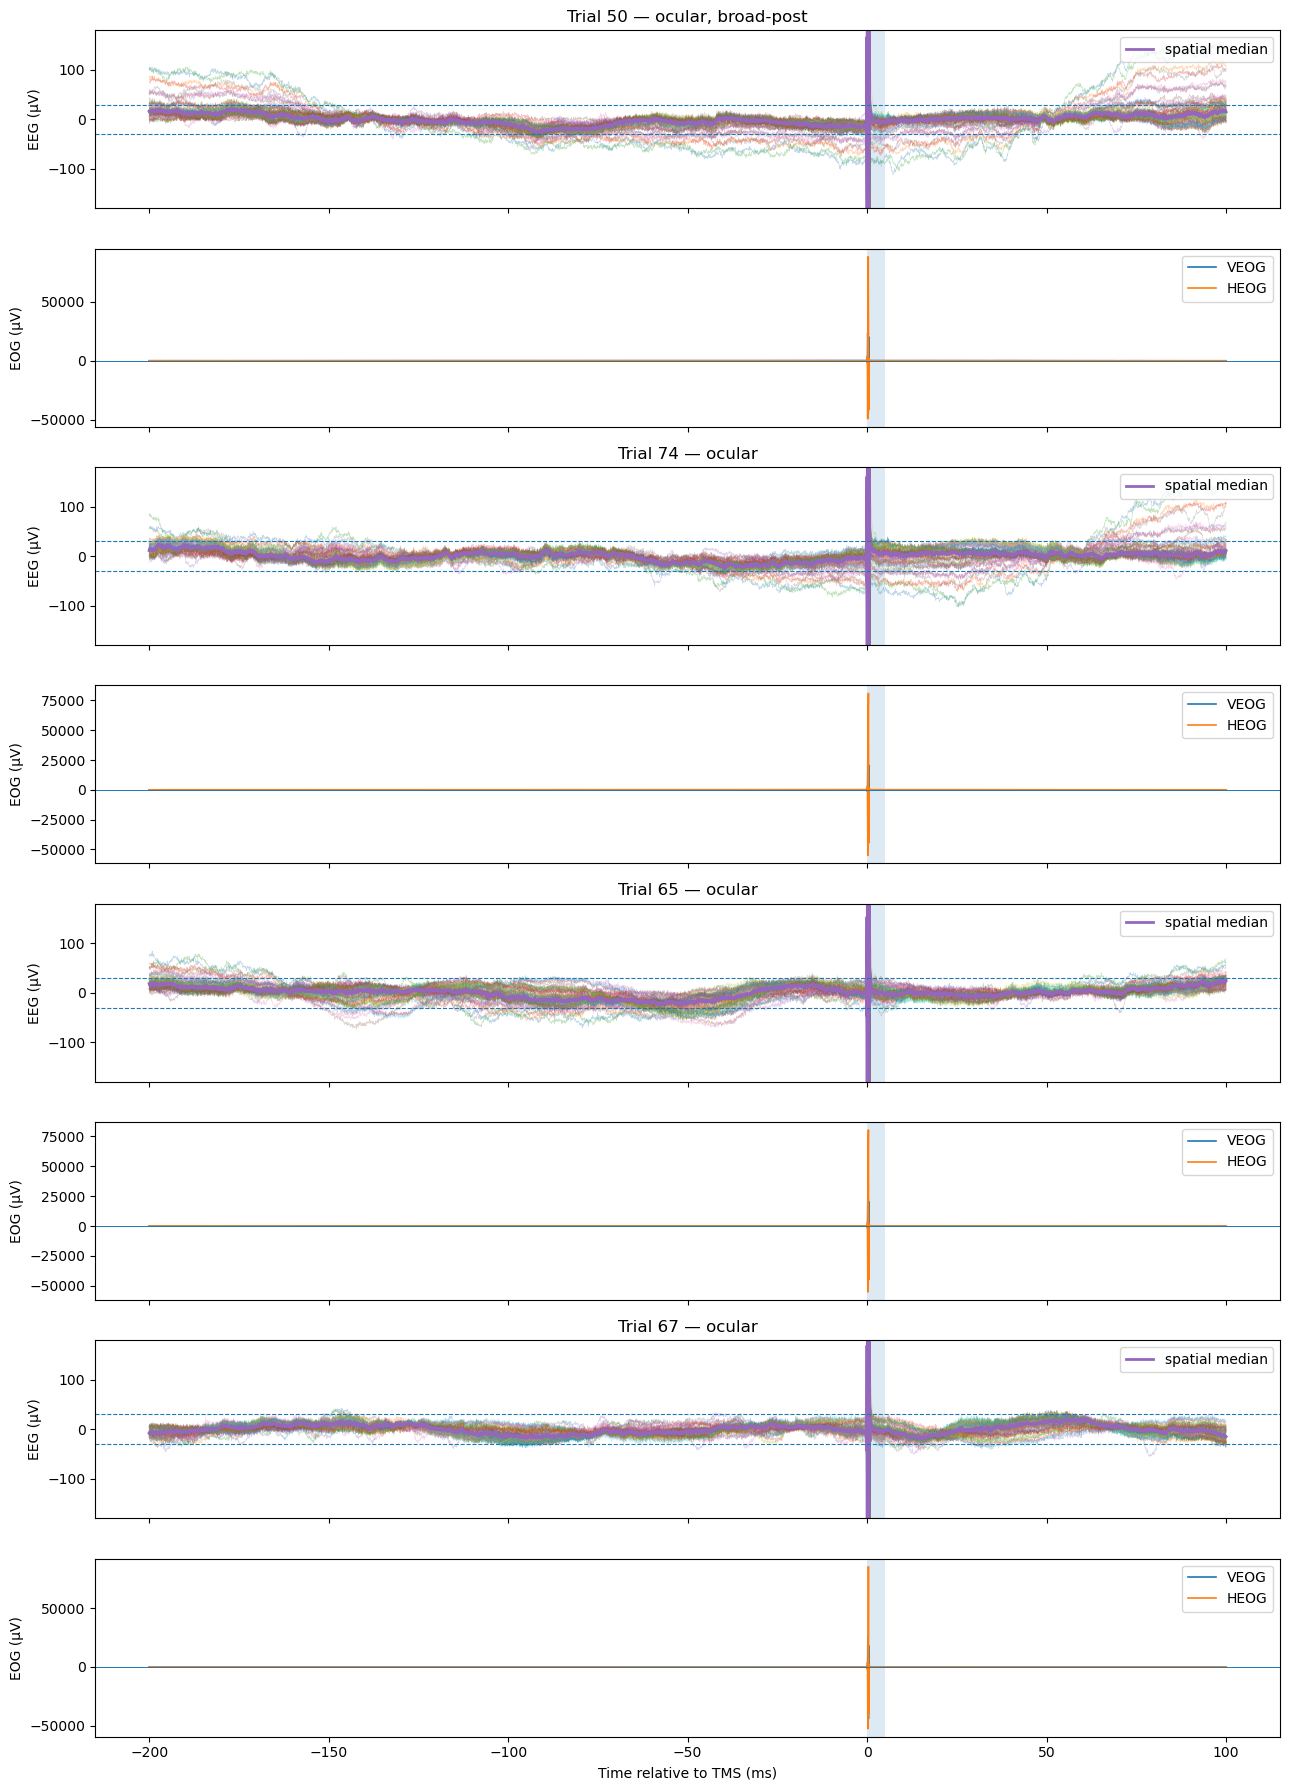


Reviewing: [35, 12, 75, 18]


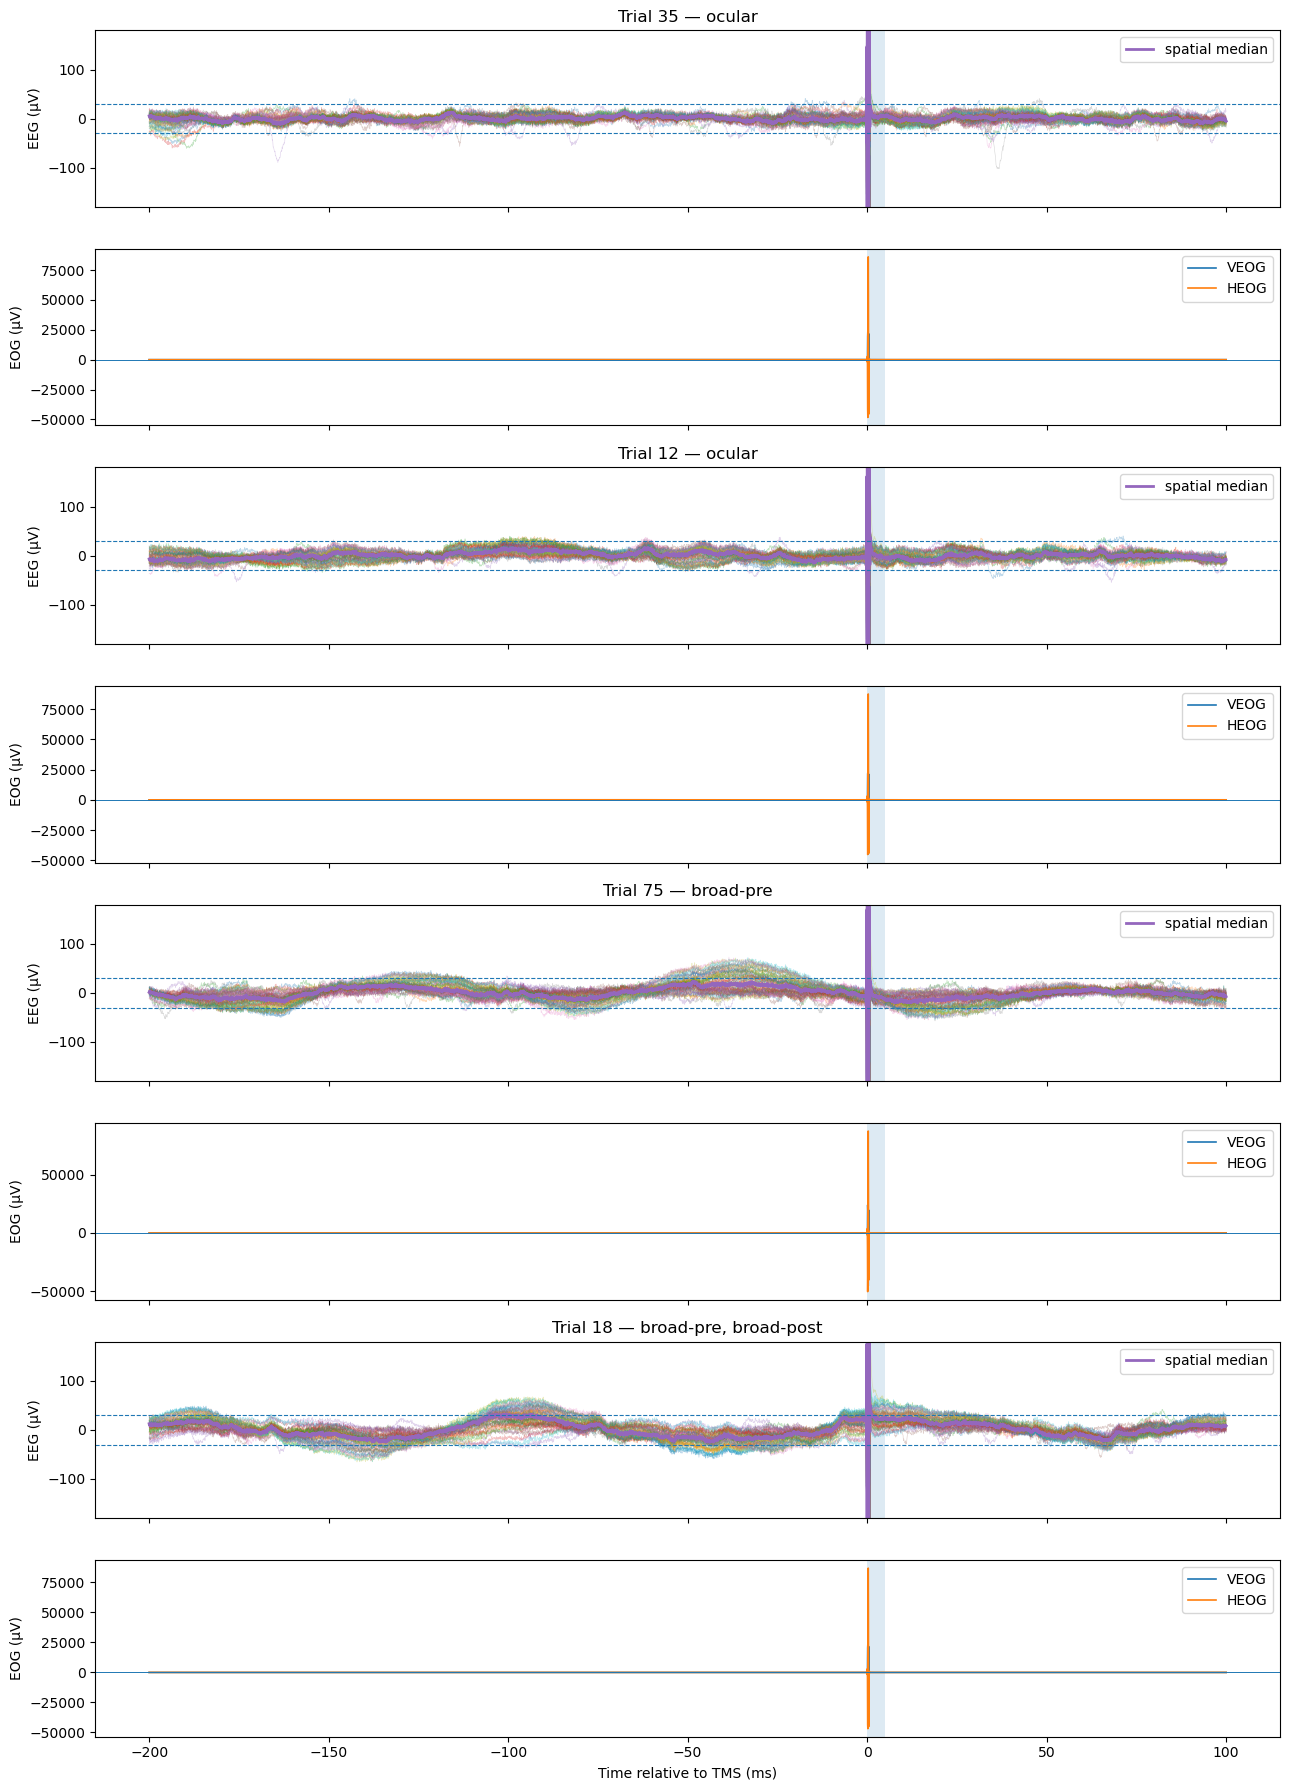


Reviewing: [15, 43, 58, 48]


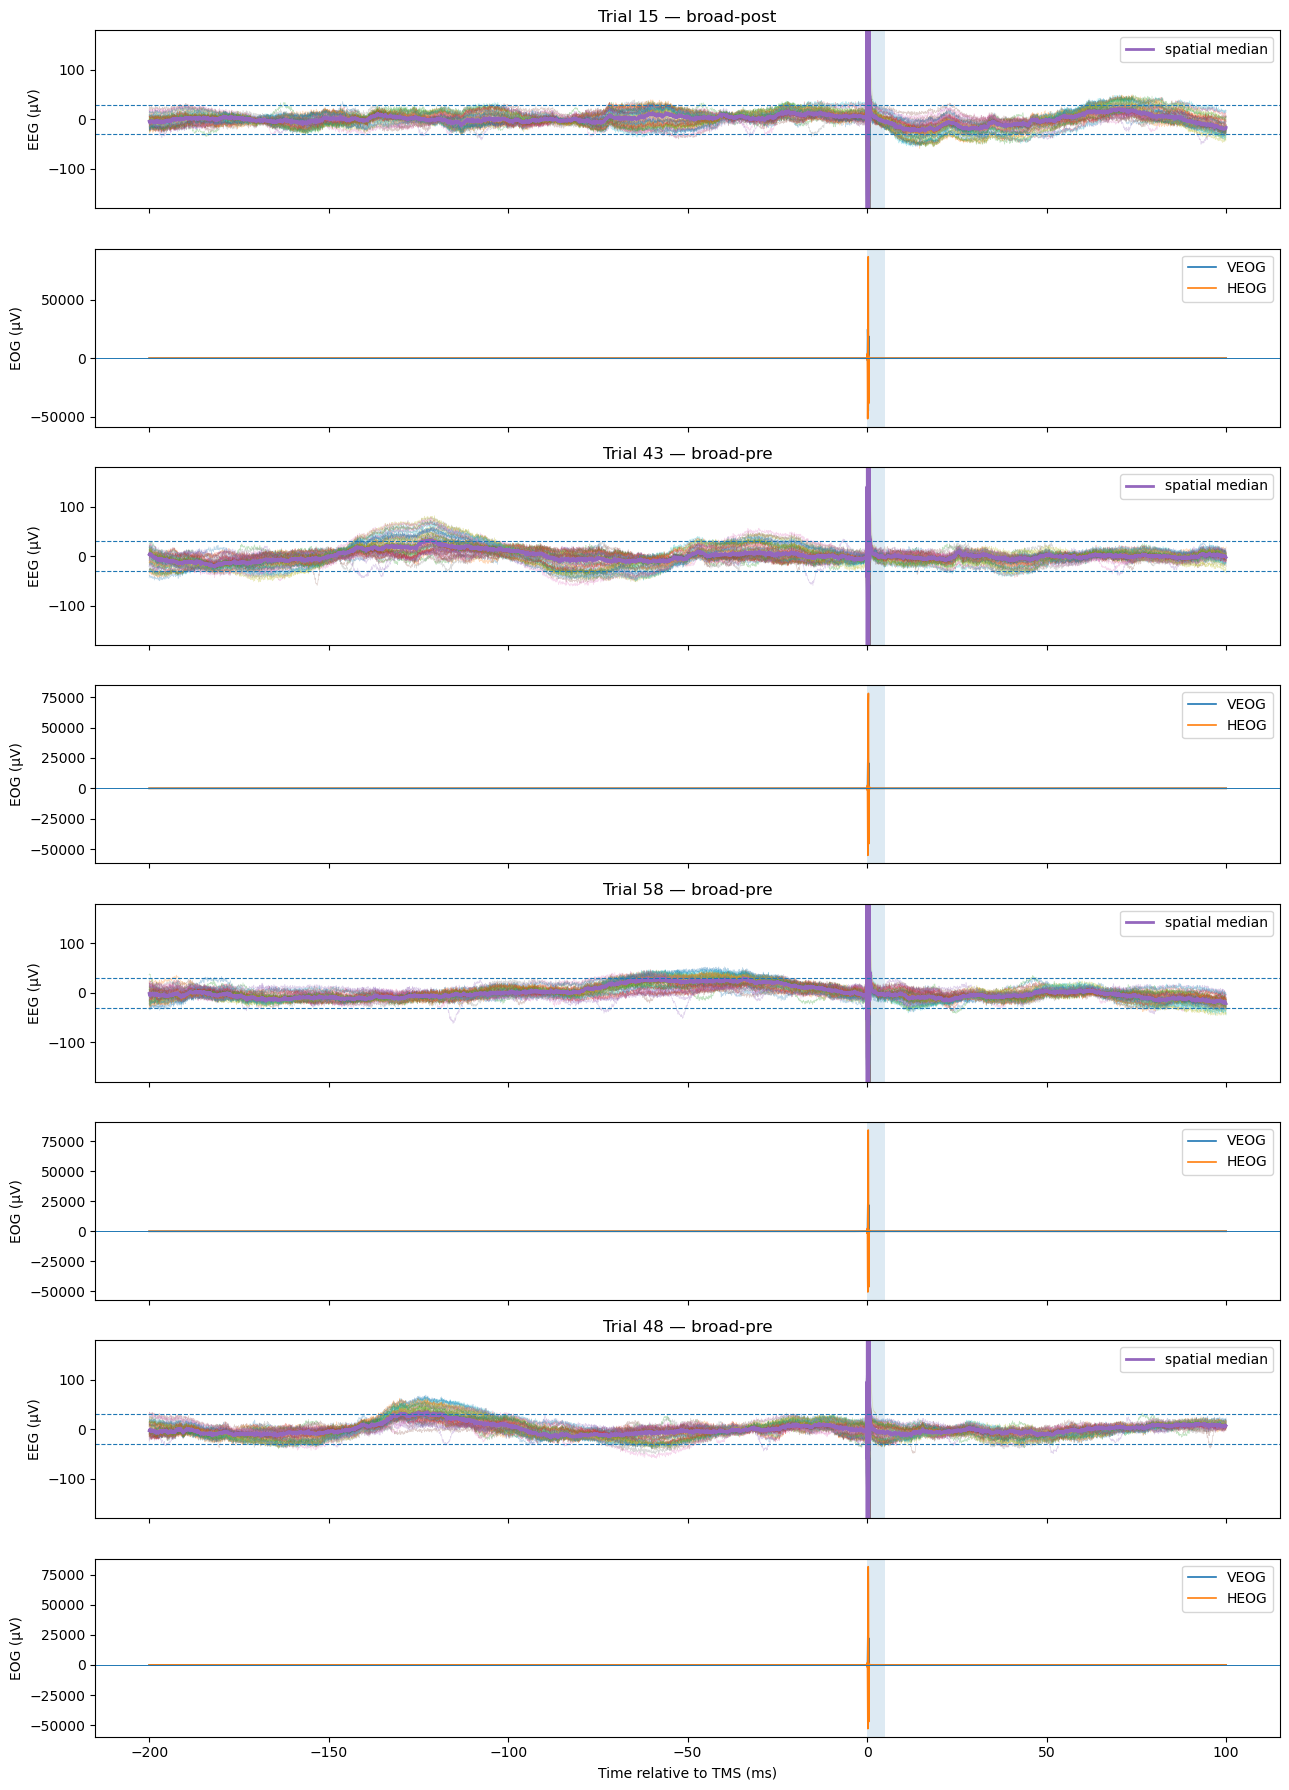

In [68]:
# ============================================================
# LEVEL-1 / CELL 10
# Manual review panels for the 12 candidate trials
#
# Paper-style visual inspection.
# Nothing is rejected automatically.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

candidate_ids = (
    review_candidates["trial_id"]
    .astype(int)
    .tolist()
)

print("Candidates:", candidate_ids)

# ------------------------------------------------------------
# Display window
# ------------------------------------------------------------

display_mask = (
    (times_l1 >= -0.200) &
    (times_l1 <= 0.100)
)

t_ms = times_l1[display_mask] * 1000

# EEG, µV
eeg_all_uv = (
    qc_data_dt[:, eeg_idx, :] * 1e6
)

# EOG indices
veog_idx = (
    epochs_l1.ch_names.index("VEOG")
    if "VEOG" in epochs_l1.ch_names
    else None
)

heog_idx = (
    epochs_l1.ch_names.index("HEOG")
    if "HEOG" in epochs_l1.ch_names
    else None
)


def plot_review_batch(trial_ids):

    fig, axes = plt.subplots(
        2 * len(trial_ids),
        1,
        figsize=(13, 4.5 * len(trial_ids)),
        sharex=True
    )

    if len(trial_ids) == 1:
        axes = np.asarray(axes)

    for j, trial_id in enumerate(trial_ids):

        tr = trial_id - 1

        # ----------------------------------------------------
        # EEG butterfly
        # ----------------------------------------------------

        ax_eeg = axes[2*j]

        eeg = (
            eeg_all_uv[tr]
            [:, display_mask]
        )

        for x in eeg:
            ax_eeg.plot(
                t_ms,
                x,
                linewidth=0.45,
                alpha=0.28
            )

        # Spatial median highlights broad/common excursions
        spatial_median = np.median(
            eeg,
            axis=0
        )

        ax_eeg.plot(
            t_ms,
            spatial_median,
            linewidth=2.0,
            label="spatial median"
        )

        ax_eeg.axhline(
            +30,
            linestyle="--",
            linewidth=0.8
        )

        ax_eeg.axhline(
            -30,
            linestyle="--",
            linewidth=0.8
        )

        # TMS-artifact interval
        ax_eeg.axvspan(
            0,
            5,
            alpha=0.15
        )

        reason = review_candidates.loc[
            review_candidates["trial_id"] == trial_id,
            "review_reason"
        ].iloc[0]

        ax_eeg.set_title(
            f"Trial {trial_id} — {reason}"
        )

        ax_eeg.set_ylabel(
            "EEG (µV)"
        )

        # same scale across trials for fair comparison
        ax_eeg.set_ylim(
            -180,
            180
        )

        ax_eeg.legend(
            loc="upper right"
        )

        # ----------------------------------------------------
        # EOG
        # ----------------------------------------------------

        ax_eog = axes[2*j + 1]

        if veog_idx is not None:

            veog = (
                qc_data_dt[
                    tr,
                    veog_idx,
                    :
                ][display_mask]
                * 1e6
            )

            ax_eog.plot(
                t_ms,
                veog,
                linewidth=1.2,
                label="VEOG"
            )

        if heog_idx is not None:

            heog = (
                qc_data_dt[
                    tr,
                    heog_idx,
                    :
                ][display_mask]
                * 1e6
            )

            ax_eog.plot(
                t_ms,
                heog,
                linewidth=1.2,
                label="HEOG"
            )

        ax_eog.axvspan(
            0,
            5,
            alpha=0.15
        )

        ax_eog.axhline(
            0,
            linewidth=0.7
        )

        ax_eog.set_ylabel(
            "EOG (µV)"
        )

        ax_eog.legend(
            loc="upper right"
        )

    axes[-1].set_xlabel(
        "Time relative to TMS (ms)"
    )

    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# Plot in batches of four
# ------------------------------------------------------------

for start in range(
    0,
    len(candidate_ids),
    4
):

    batch = candidate_ids[
        start:start+4
    ]

    print(
        "\nReviewing:",
        batch
    )

    plot_review_batch(batch)

In [69]:
# ============================================================
# LEVEL-1 / CELL 11
# Freeze manual QC decisions for this run
#
# IMPORTANT:
# - measurement-preserving epochs remain unchanged
# - no data are physically deleted
# - good/bad status is stored as metadata
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# Final manual bad trials
# ------------------------------------------------------------

manual_bad_trials = [
    12,
    35,
    50,
    65,
    67,
    74,
]

# Morphology-only candidates that we deliberately KEEP
morphology_keep_trials = [
    15,
    18,
    43,
    48,
    58,
    75,
]

# ------------------------------------------------------------
# Build final QC table
# ------------------------------------------------------------

qc_final = pd.DataFrame({
    "trial_id": np.arange(1, n_trials + 1)
})

# Merge existing diagnostics
qc_final = qc_final.merge(
    review[
        [
            "trial_id",
            "manual_review",
            "review_reason",
            "ocular_rz_max",
            "muscle_rz_max",
            "max_simultaneous_pre",
            "longest_widespread_ms_pre",
            "max_simultaneous_post",
            "longest_widespread_ms_post",
        ]
    ],
    on="trial_id",
    how="left"
)

# ------------------------------------------------------------
# Manual decisions
# ------------------------------------------------------------

qc_final["manual_bad"] = (
    qc_final["trial_id"]
    .isin(manual_bad_trials)
)

qc_final["morphology_flag_keep"] = (
    qc_final["trial_id"]
    .isin(morphology_keep_trials)
)

qc_final["good_trial"] = (
    ~qc_final["manual_bad"]
)

# ------------------------------------------------------------
# Explicit rejection reason
# ------------------------------------------------------------

bad_reason_map = {
    12: "ocular",
    35: "ocular",
    50: "ocular+broad",
    65: "ocular",
    67: "ocular",
    74: "ocular+broad",
}

qc_final["bad_reason"] = (
    qc_final["trial_id"]
    .map(bad_reason_map)
)

qc_final["bad_reason"] = (
    qc_final["bad_reason"]
    .fillna("")
)

# ------------------------------------------------------------
# Add original event information
# ------------------------------------------------------------

qc_final["stim_sample"] = stim_samples
qc_final["stim_onset_s"] = (
    stim_samples / sfreq
)

# ------------------------------------------------------------
# Sanity checks
# ------------------------------------------------------------

n_good = int(
    qc_final["good_trial"].sum()
)

n_bad = int(
    qc_final["manual_bad"].sum()
)

print("=== FINAL LEVEL-1 TRIAL QC ===")

print(
    "Total:",
    len(qc_final)
)

print(
    "Good:",
    n_good
)

print(
    "Bad:",
    n_bad
)

print(
    "Retained fraction:",
    n_good / len(qc_final)
)

print(
    "\nBad trials:"
)

display(
    qc_final[
        qc_final["manual_bad"]
    ][
        [
            "trial_id",
            "bad_reason",
            "review_reason",
            "ocular_rz_max",
            "muscle_rz_max",
        ]
    ]
)

print(
    "\nFlagged but retained morphology trials:"
)

display(
    qc_final[
        qc_final["morphology_flag_keep"]
    ][
        [
            "trial_id",
            "review_reason",
            "longest_widespread_ms_pre",
            "longest_widespread_ms_post",
        ]
    ]
)

# ------------------------------------------------------------
# Boolean mask used by downstream processing
# ------------------------------------------------------------

good_trial_mask = (
    qc_final["good_trial"]
    .to_numpy(dtype=bool)
)

print(
    "\ngood_trial_mask shape:",
    good_trial_mask.shape
)

print(
    "good_trial_mask sum:",
    good_trial_mask.sum()
)

=== FINAL LEVEL-1 TRIAL QC ===
Total: 80
Good: 74
Bad: 6
Retained fraction: 0.925

Bad trials:


,trial_id,bad_reason,review_reason,ocular_rz_max,muscle_rz_max
11,12,ocular,ocular,6.874358,0.654653
34,35,ocular,ocular,7.282848,0.689327
49,50,ocular+broad,"ocular, broad-post",23.244134,0.313443
64,65,ocular,ocular,11.901256,-0.018280
66,67,ocular,ocular,7.442634,1.316104
73,74,ocular+broad,ocular,18.860892,0.728835



Flagged but retained morphology trials:


,trial_id,review_reason,longest_widespread_ms_pre,longest_widespread_ms_post
14,15,broad-post,0.00,6.90
17,18,"broad-pre, broad-post",19.80,3.45
42,43,broad-pre,22.75,0.00
47,48,broad-pre,20.85,0.00
57,58,broad-pre,10.35,0.00
74,75,broad-pre,18.20,0.75



good_trial_mask shape: (80,)
good_trial_mask sum: 74


In [70]:
# ============================================================
# LEVEL-1 / CELL 12
# Save frozen Level-1 derivative for this run
#
# Saved objects:
#   1. measurement-preserving epochs (.fif)
#   2. complete QC table (.tsv)
#   3. detrend/QC parameters (.npz)
#   4. provenance/configuration (.json)
#
# No waveform is discarded.
# ============================================================

from pathlib import Path
import json
import numpy as np
import pandas as pd
import mne


# ------------------------------------------------------------
# Dataset identity
# ------------------------------------------------------------

L1_SUBJECT = "CON026"
L1_SESSION = "async9ms"
L1_TASK = "spTMS"
L1_RUN = "01"

# Change this if you want another permanent location
L1_ROOT = Path("./Data_HumanEEG_level1").resolve()

run_dir = (
    L1_ROOT
    / f"sub-{L1_SUBJECT}"
    / f"ses-{L1_SESSION}"
    / "eeg"
)

run_dir.mkdir(
    parents=True,
    exist_ok=True
)

stem_l1 = (
    f"sub-{L1_SUBJECT}_"
    f"ses-{L1_SESSION}_"
    f"task-{L1_TASK}_"
    f"run-{L1_RUN}"
)

print("Level-1 output directory:")
print(run_dir)


# ============================================================
# 1. Measurement-preserving epochs
# ============================================================

epo_path = (
    run_dir
    / f"{stem_l1}_desc-measurement_epo.fif"
)

# Materialize the lazy epochs.
# This does NOT apply filtering, detrending, baseline,
# interpolation, or rejection.
epochs_save = epochs_l1.copy().load_data()

# Keep all 80 trials.
assert len(epochs_save.events) == 80

print("\nSaving measurement-preserving epochs...")

epochs_save.save(
    epo_path,
    overwrite=True,
    fmt="single"       # float32 on disk; suitable for EEG
)

print("Saved:")
print(epo_path)


# ============================================================
# 2. Complete QC table
# ============================================================

# Start from frozen final QC decisions
qc_save = qc_final.copy()

# Add amplitude diagnostics
amp_cols = [
    c for c in trial_amp_qc.columns
    if c != "trial_id"
]

qc_save = qc_save.merge(
    trial_amp_qc[
        ["trial_id"] + amp_cols
    ],
    on="trial_id",
    how="left"
)

# Add EOG diagnostics
eog_cols = [
    c for c in eog_qc.columns
    if c != "trial_id"
]

qc_save = qc_save.merge(
    eog_qc[
        ["trial_id"] + eog_cols
    ],
    on="trial_id",
    how="left"
)

# Add muscle diagnostics
muscle_cols = [
    c for c in muscle_qc.columns
    if c != "trial_id"
]

qc_save = qc_save.merge(
    muscle_qc[
        ["trial_id"] + muscle_cols
    ],
    on="trial_id",
    how="left"
)

# Remove duplicate columns if merges created any
qc_save = qc_save.loc[
    :,
    ~qc_save.columns.duplicated()
]

qc_path = (
    run_dir
    / f"{stem_l1}_desc-qc_trials.tsv"
)

qc_save.to_csv(
    qc_path,
    sep="\t",
    index=False
)

print("\nSaved QC table:")
print(qc_path)

print(
    "QC table shape:",
    qc_save.shape
)


# ============================================================
# 3. QC transform metadata
#
# These are enough to reproduce our temporary detrended
# QC copy from the measurement-preserving epochs.
# ============================================================

detrend_path = (
    run_dir
    / f"{stem_l1}_desc-qcdetrend_params.npz"
)

np.savez_compressed(
    detrend_path,

    slope_v_per_s=qc_trend_slope,
    intercept_v=qc_trend_intercept,

    trial_id=np.arange(
        1,
        n_trials + 1
    ),

    channel_names=np.asarray(
        epochs_l1.ch_names
    ),

    sfreq=np.asarray(
        sfreq
    ),

    fit_tmin_s=np.asarray(
        QC_FIT_TMIN
    ),

    fit_tmax_s=np.asarray(
        QC_FIT_TMAX
    ),

    excluded_tmin_s=np.asarray(
        TMS_MASK_TMIN
    ),

    excluded_tmax_s=np.asarray(
        TMS_MASK_TMAX
    ),
)

print("\nSaved QC detrend parameters:")
print(detrend_path)


# ============================================================
# 4. Provenance / configuration
# ============================================================

provenance = {

    "pipeline": "TSC Level-1",

    "pipeline_stage":
        "measurement-preserving TMS-EEG epochs with QC annotations",

    "subject": L1_SUBJECT,
    "session": L1_SESSION,
    "task": L1_TASK,
    "run": L1_RUN,

    "raw_sampling_frequency_hz":
        float(sfreq),

    "epoch_tmin_s":
        float(L1_TMIN),

    "epoch_tmax_s":
        float(L1_TMAX),

    "n_trials_total":
        int(n_trials),

    "n_trials_good":
        int(good_trial_mask.sum()),

    "n_trials_bad":
        int((~good_trial_mask).sum()),

    "bad_trial_ids":
        [
            int(x)
            for x in manual_bad_trials
        ],

    "morphology_flag_but_retained_ids":
        [
            int(x)
            for x in morphology_keep_trials
        ],

    "n_channels":
        int(len(epochs_l1.ch_names)),

    "channel_type_counts": {
        str(k): int(v)
        for k, v in
        pd.Series(
            epochs_l1.get_channel_types()
        )
        .value_counts()
        .items()
    },

    # Measurement branch
    "measurement_signal_processing": {
        "filtering": False,
        "baseline_correction": False,
        "detrending": False,
        "interpolation": False,
        "ica": False,
        "downsampling": False,
        "trial_averaging": False
    },

    # QC branch
    "qc_processing": {

        "temporary_linear_detrend": True,

        "detrend_fit_window_s": [
            float(QC_FIT_TMIN),
            float(QC_FIT_TMAX)
        ],

        "detrend_fit_excluded_tms_window_s": [
            float(TMS_MASK_TMIN),
            float(TMS_MASK_TMAX)
        ],

        "paper_amplitude_reference_uv":
            float(PAPER_AMP_THRESHOLD_UV),

        "ocular_candidate_robust_z":
            float(EOG_RZ_CANDIDATE),

        "muscle_band_hz": [
            float(MUSCLE_FMIN),
            float(MUSCLE_FMAX)
        ],

        "muscle_candidate_robust_z":
            float(MUSCLE_RZ_CANDIDATE),

        "manual_review_used":
            True
    },

    "notes": [
        "All 80 measurement-defined trials are preserved.",
        "Bad trials are represented by QC metadata and are not physically removed.",
        "Morphology-only deviations were retained unless independent artifact evidence was present.",
        "Temporary detrending was used only for QC and was not written into the measurement-preserving signal."
    ]
}

json_path = (
    run_dir
    / f"{stem_l1}_desc-level1_provenance.json"
)

with open(
    json_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        provenance,
        f,
        indent=2,
        ensure_ascii=False
    )

print("\nSaved provenance:")
print(json_path)


# ============================================================
# 5. Final file audit
# ============================================================

print("\n=== LEVEL-1 FILE AUDIT ===")

for p in [
    epo_path,
    qc_path,
    detrend_path,
    json_path
]:

    size_mb = (
        p.stat().st_size
        / 1024**2
    )

    print(
        f"{p.name:<75} "
        f"{size_mb:8.2f} MB"
    )

Level-1 output directory:
C:\Users\liu.xuanc\Desktop\Code\TSC-TemporalStructureClosure\Data_HumanEEG_level1\sub-CON026\ses-async9ms\eeg
Loading data for 80 events and 16001 original time points ...
0 bad epochs dropped

Saving measurement-preserving epochs...
Saved:
C:\Users\liu.xuanc\Desktop\Code\TSC-TemporalStructureClosure\Data_HumanEEG_level1\sub-CON026\ses-async9ms\eeg\sub-CON026_ses-async9ms_task-spTMS_run-01_desc-measurement_epo.fif

Saved QC table:
C:\Users\liu.xuanc\Desktop\Code\TSC-TemporalStructureClosure\Data_HumanEEG_level1\sub-CON026\ses-async9ms\eeg\sub-CON026_ses-async9ms_task-spTMS_run-01_desc-qc_trials.tsv
QC table shape: (80, 44)

Saved QC detrend parameters:
C:\Users\liu.xuanc\Desktop\Code\TSC-TemporalStructureClosure\Data_HumanEEG_level1\sub-CON026\ses-async9ms\eeg\sub-CON026_ses-async9ms_task-spTMS_run-01_desc-qcdetrend_params.npz

Saved provenance:
C:\Users\liu.xuanc\Desktop\Code\TSC-TemporalStructureClosure\Data_HumanEEG_level1\sub-CON026\ses-async9ms\eeg\sub-CO

In [71]:
# ============================================================
# LEVEL-1 / CELL 13
# Round-trip integrity check
#
# If this passes, Level 1 for this run is frozen.
# ============================================================

from pathlib import Path
import json
import numpy as np
import pandas as pd
import mne


# ------------------------------------------------------------
# Reconstruct saved paths independently
# ------------------------------------------------------------

L1_ROOT = Path("./Data_HumanEEG_level1").resolve()

L1_SUBJECT = "CON026"
L1_SESSION = "async9ms"
L1_TASK = "spTMS"
L1_RUN = "01"

run_dir_rt = (
    L1_ROOT
    / f"sub-{L1_SUBJECT}"
    / f"ses-{L1_SESSION}"
    / "eeg"
)

stem_rt = (
    f"sub-{L1_SUBJECT}_"
    f"ses-{L1_SESSION}_"
    f"task-{L1_TASK}_"
    f"run-{L1_RUN}"
)

epo_path_rt = (
    run_dir_rt
    / f"{stem_rt}_desc-measurement_epo.fif"
)

qc_path_rt = (
    run_dir_rt
    / f"{stem_rt}_desc-qc_trials.tsv"
)

detrend_path_rt = (
    run_dir_rt
    / f"{stem_rt}_desc-qcdetrend_params.npz"
)

json_path_rt = (
    run_dir_rt
    / f"{stem_rt}_desc-level1_provenance.json"
)


# ------------------------------------------------------------
# Check all files exist
# ------------------------------------------------------------

paths = [
    epo_path_rt,
    qc_path_rt,
    detrend_path_rt,
    json_path_rt,
]

for p in paths:
    assert p.exists(), f"Missing file: {p}"

print("All Level-1 files found.")


# ============================================================
# 1. Read measurement epochs from disk
# ============================================================

epochs_rt = mne.read_epochs(
    epo_path_rt,
    preload=False,
    verbose=False
)

print("\n=== MEASUREMENT FILE ===")

print(epochs_rt)

print(
    "Events:",
    len(epochs_rt.events)
)

print(
    "Channels:",
    len(epochs_rt.ch_names)
)

print(
    "Samples/epoch:",
    len(epochs_rt.times)
)

print(
    "Sampling frequency:",
    epochs_rt.info["sfreq"]
)

print(
    "Time range:",
    epochs_rt.times[0],
    "to",
    epochs_rt.times[-1]
)


# Hard assertions
assert len(epochs_rt.events) == 80
assert len(epochs_rt.ch_names) == 69
assert len(epochs_rt.times) == 16001

assert np.isclose(
    epochs_rt.info["sfreq"],
    20000.0
)

assert np.isclose(
    epochs_rt.times[0],
    -0.5
)

assert np.isclose(
    epochs_rt.times[-1],
    0.3
)


# ============================================================
# 2. QC table
# ============================================================

qc_rt = pd.read_csv(
    qc_path_rt,
    sep="\t"
)

print("\n=== QC TABLE ===")

print(
    "Shape:",
    qc_rt.shape
)

print(
    "Good:",
    int(qc_rt["good_trial"].sum())
)

print(
    "Bad:",
    int(qc_rt["manual_bad"].sum())
)

bad_ids_rt = (
    qc_rt.loc[
        qc_rt["manual_bad"],
        "trial_id"
    ]
    .astype(int)
    .tolist()
)

print(
    "Bad trial IDs:",
    bad_ids_rt
)

assert len(qc_rt) == 80
assert int(qc_rt["good_trial"].sum()) == 74

assert bad_ids_rt == [
    12, 35, 50, 65, 67, 74
]


# ============================================================
# 3. Detrend parameters
# ============================================================

dt_rt = np.load(
    detrend_path_rt,
    allow_pickle=False
)

print("\n=== QC DETREND PARAMETERS ===")

print(
    "Slope shape:",
    dt_rt["slope_v_per_s"].shape
)

print(
    "Intercept shape:",
    dt_rt["intercept_v"].shape
)

print(
    "Stored sfreq:",
    float(dt_rt["sfreq"])
)

print(
    "Fit window:",
    float(dt_rt["fit_tmin_s"]),
    "to",
    float(dt_rt["fit_tmax_s"]),
    "s"
)

assert (
    dt_rt["slope_v_per_s"].shape
    == (80, 69)
)

assert (
    dt_rt["intercept_v"].shape
    == (80, 69)
)


# ============================================================
# 4. Provenance JSON
# ============================================================

with open(
    json_path_rt,
    "r",
    encoding="utf-8"
) as f:
    provenance_rt = json.load(f)

print("\n=== PROVENANCE ===")

print(
    "Pipeline:",
    provenance_rt["pipeline"]
)

print(
    "Trials total/good/bad:",
    provenance_rt["n_trials_total"],
    provenance_rt["n_trials_good"],
    provenance_rt["n_trials_bad"]
)

print(
    "Measurement processing:",
    provenance_rt[
        "measurement_signal_processing"
    ]
)

assert (
    provenance_rt["n_trials_total"]
    == 80
)

assert (
    provenance_rt["n_trials_good"]
    == 74
)

assert (
    provenance_rt["n_trials_bad"]
    == 6
)


# ============================================================
# 5. Waveform round-trip check
#
# Compare saved FIF against original BrainVision raw.
# We test a few trials and channels, not the whole 337 MB.
# ============================================================

test_trial_ids = [
    1,
    35,
    50,
    80
]

test_channels = [
    "C3",
    "C4",
    "VEOG",
    "EMG Right"
]

# indices inside the saved epoch
test_ch_idx = [
    epochs_rt.ch_names.index(ch)
    for ch in test_channels
]

# Load only selected epochs
saved_test = epochs_rt[
    np.asarray(test_trial_ids) - 1
].get_data(
    picks=test_channels,
    copy=True
)

# shape:
# selected trials × selected channels × 16001

raw_test = []

pre_samples_rt = int(
    round(
        abs(L1_TMIN)
        * sfreq
    )
)

post_samples_rt = int(
    round(
        L1_TMAX
        * sfreq
    )
)

for trial_id in test_trial_ids:

    s0 = stim_samples[
        trial_id - 1
    ]

    start = (
        s0
        - pre_samples_rt
    )

    stop = (
        s0
        + post_samples_rt
        + 1
    )

    x = raw.get_data(
        picks=test_channels,
        start=start,
        stop=stop
    )

    raw_test.append(x)

raw_test = np.stack(
    raw_test,
    axis=0
)


# Difference from float32 FIF storage
difference_uv = (
    saved_test
    - raw_test
) * 1e6

max_abs_error_uv = np.max(
    np.abs(difference_uv)
)

median_abs_error_uv = np.median(
    np.abs(difference_uv)
)

print("\n=== WAVEFORM ROUND-TRIP ===")

print(
    "Compared shape:",
    saved_test.shape
)

print(
    "Median absolute error:",
    median_abs_error_uv,
    "µV"
)

print(
    "Maximum absolute error:",
    max_abs_error_uv,
    "µV"
)

# Float32 storage should be far below physiologically
# meaningful EEG amplitudes.
assert max_abs_error_uv < 0.05


# ============================================================
# FINAL
# ============================================================

print(
    "\n============================================"
)

print(
    "LEVEL-1 ROUND-TRIP CHECK: PASSED"
)

print(
    "============================================"
)

All Level-1 files found.

=== MEASUREMENT FILE ===
<EpochsFIF | 80 events (all good), -0.5 – 0.3 s (baseline off), ~60 KiB, data not loaded, with metadata,
 'spTMS': 80>
Events: 80
Channels: 69
Samples/epoch: 16001
Sampling frequency: 20000.0
Time range: -0.5 to 0.3

=== QC TABLE ===
Shape: (80, 44)
Good: 74
Bad: 6
Bad trial IDs: [12, 35, 50, 65, 67, 74]

=== QC DETREND PARAMETERS ===
Slope shape: (80, 69)
Intercept shape: (80, 69)
Stored sfreq: 20000.0
Fit window: -0.2 to 0.1 s

=== PROVENANCE ===
Pipeline: TSC Level-1
Trials total/good/bad: 80 74 6
Measurement processing: {'filtering': False, 'baseline_correction': False, 'detrending': False, 'interpolation': False, 'ica': False, 'downsampling': False, 'trial_averaging': False}
Loading data for 4 events and 16001 original time points ...

=== WAVEFORM ROUND-TRIP ===
Compared shape: (4, 4, 16001)
Median absolute error: 6.940364895204748e-06 µV
Maximum absolute error: 0.0269518125040058 µV

LEVEL-1 ROUND-TRIP CHECK: PASSED


In [72]:
# ============================================================
# LEVEL-1 / CELL 14
# Standard loader for downstream analysis
#
# From this point onward, downstream notebooks should access
# Level-1 data ONLY through this interface.
# ============================================================

from pathlib import Path
import json
import numpy as np
import pandas as pd
import mne


LEVEL1_ROOT = Path(
    "./Data_HumanEEG_level1"
).resolve()


def load_level1_run(
    subject,
    session,
    run,
    task="spTMS",
    preload=False
):
    """
    Load one frozen TSC Level-1 run.

    Returns
    -------
    dict containing:
        epochs_all
        qc
        good_trial_mask
        good_trial_ids
        bad_trial_ids
        provenance
        detrend_params
        paths
    """

    subject = str(subject)
    session = str(session)
    run = str(run).zfill(2)

    run_dir = (
        LEVEL1_ROOT
        / f"sub-{subject}"
        / f"ses-{session}"
        / "eeg"
    )

    stem = (
        f"sub-{subject}_"
        f"ses-{session}_"
        f"task-{task}_"
        f"run-{run}"
    )

    paths = {
        "epochs":
            run_dir
            / f"{stem}_desc-measurement_epo.fif",

        "qc":
            run_dir
            / f"{stem}_desc-qc_trials.tsv",

        "detrend":
            run_dir
            / f"{stem}_desc-qcdetrend_params.npz",

        "provenance":
            run_dir
            / f"{stem}_desc-level1_provenance.json",
    }

    # ----------------------------------------------
    # Integrity: all required files
    # ----------------------------------------------

    for name, path in paths.items():

        if not path.exists():
            raise FileNotFoundError(
                f"Missing Level-1 {name}: {path}"
            )

    # ----------------------------------------------
    # Load
    # ----------------------------------------------

    epochs_all = mne.read_epochs(
        paths["epochs"],
        preload=preload,
        verbose=False
    )

    qc = pd.read_csv(
        paths["qc"],
        sep="\t"
    )

    with open(
        paths["provenance"],
        "r",
        encoding="utf-8"
    ) as f:
        provenance = json.load(f)

    detrend_params = np.load(
        paths["detrend"],
        allow_pickle=False
    )

    # ----------------------------------------------
    # Trial masks
    # ----------------------------------------------

    good_trial_mask = (
        qc["good_trial"]
        .to_numpy(dtype=bool)
    )

    good_trial_ids = (
        qc.loc[
            good_trial_mask,
            "trial_id"
        ]
        .astype(int)
        .to_numpy()
    )

    bad_trial_ids = (
        qc.loc[
            ~good_trial_mask,
            "trial_id"
        ]
        .astype(int)
        .to_numpy()
    )

    # ----------------------------------------------
    # Cross-file sanity checks
    # ----------------------------------------------

    if len(epochs_all.events) != len(qc):
        raise RuntimeError(
            "Epoch/QC trial-count mismatch"
        )

    if (
        provenance["n_trials_total"]
        != len(qc)
    ):
        raise RuntimeError(
            "Provenance/QC trial-count mismatch"
        )

    if (
        provenance["n_trials_good"]
        != int(good_trial_mask.sum())
    ):
        raise RuntimeError(
            "Provenance/QC good-trial mismatch"
        )

    # ----------------------------------------------
    # Return
    # ----------------------------------------------

    return {
        "epochs_all": epochs_all,

        "qc": qc,

        "good_trial_mask":
            good_trial_mask,

        "good_trial_ids":
            good_trial_ids,

        "bad_trial_ids":
            bad_trial_ids,

        "provenance":
            provenance,

        "detrend_params":
            detrend_params,

        "paths":
            paths,
    }


# ============================================================
# Test the interface on our frozen pilot run
# ============================================================

l1 = load_level1_run(
    subject="CON026",
    session="async9ms",
    run="01",
    preload=False
)

print("=== STANDARD LEVEL-1 INTERFACE ===")

print(
    "All epochs:",
    len(l1["epochs_all"].events)
)

print(
    "Good trials:",
    len(l1["good_trial_ids"])
)

print(
    "Bad trials:",
    l1["bad_trial_ids"].tolist()
)

print(
    "Sampling frequency:",
    l1["epochs_all"].info["sfreq"]
)

print(
    "Channels:",
    len(l1["epochs_all"].ch_names)
)

print(
    "Time range:",
    l1["epochs_all"].times[0],
    "to",
    l1["epochs_all"].times[-1]
)

print(
    "Level-1 root:",
    LEVEL1_ROOT
)

=== STANDARD LEVEL-1 INTERFACE ===
All epochs: 80
Good trials: 74
Bad trials: [12, 35, 50, 65, 67, 74]
Sampling frequency: 20000.0
Channels: 69
Time range: -0.5 to 0.3
Level-1 root: C:\Users\liu.xuanc\Desktop\Code\TSC-TemporalStructureClosure\Data_HumanEEG_level1


In [73]:
# ============================================================
# LEVEL-1 / CELL 15
# Frozen Level-1 processing configuration
#
# This becomes the single source of truth for all runs.
# ============================================================

from dataclasses import dataclass, asdict
from pathlib import Path
import json


@dataclass(frozen=True)
class Level1Config:

    # --------------------------------------------------------
    # Stored measurement epoch
    # --------------------------------------------------------

    epoch_tmin_s: float = -0.500
    epoch_tmax_s: float =  0.300

    # --------------------------------------------------------
    # Temporary QC detrending
    # --------------------------------------------------------

    qc_detrend_fit_tmin_s: float = -0.200
    qc_detrend_fit_tmax_s: float =  0.100

    qc_detrend_exclude_tmin_s: float = -0.005
    qc_detrend_exclude_tmax_s: float =  0.005

    # --------------------------------------------------------
    # Paper-derived amplitude reference
    #
    # IMPORTANT:
    # used as a morphology/QC reference,
    # NOT as an automatic global rejection criterion.
    # --------------------------------------------------------

    paper_amplitude_reference_uv: float = 30.0

    # --------------------------------------------------------
    # Morphological review triggers
    #
    # Diagnostic / review selection only.
    # They do NOT automatically reject trials.
    # --------------------------------------------------------

    widespread_n_channels: int = 16

    review_pre_widespread_ms: float = 10.0
    review_post_widespread_ms: float = 3.0

    # --------------------------------------------------------
    # Ocular candidate trigger
    #
    # Review trigger only.
    # --------------------------------------------------------

    ocular_robust_z: float = 5.0

    # --------------------------------------------------------
    # Muscle diagnostic
    #
    # Temporary QC transformation only.
    # --------------------------------------------------------

    muscle_fmin_hz: float = 70.0
    muscle_fmax_hz: float = 200.0
    muscle_robust_z: float = 5.0

    # --------------------------------------------------------
    # Filtering window for muscle diagnostic
    # --------------------------------------------------------

    muscle_filter_tmin_s: float = -0.400
    muscle_filter_tmax_s: float = -0.005

    muscle_measure_tmin_s: float = -0.200
    muscle_measure_tmax_s: float = -0.010

    # --------------------------------------------------------
    # Expected dataset properties
    # --------------------------------------------------------

    expected_sfreq_hz: float = 20000.0
    expected_n_channels: int = 69
    expected_n_eeg: int = 64

    # --------------------------------------------------------
    # Storage
    # --------------------------------------------------------

    fif_format: str = "single"

    pipeline_name: str = "TSC Level-1"
    pipeline_version: str = "1.0"


# ============================================================
# Instantiate frozen configuration
# ============================================================

L1_CONFIG = Level1Config()

print("=== FROZEN LEVEL-1 CONFIG ===")

for key, value in asdict(L1_CONFIG).items():
    print(
        f"{key:<38} {value}"
    )


# ============================================================
# Save one global copy beside the dataset root
# ============================================================

LEVEL1_ROOT = Path(
    "./Data_HumanEEG_level1"
).resolve()

LEVEL1_ROOT.mkdir(
    parents=True,
    exist_ok=True
)

config_path = (
    LEVEL1_ROOT
    / "TSC_level1_config_v1.json"
)

with open(
    config_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        asdict(L1_CONFIG),
        f,
        indent=2,
        ensure_ascii=False
    )


print(
    "\nSaved global config:"
)

print(
    config_path
)

=== FROZEN LEVEL-1 CONFIG ===
epoch_tmin_s                           -0.5
epoch_tmax_s                           0.3
qc_detrend_fit_tmin_s                  -0.2
qc_detrend_fit_tmax_s                  0.1
qc_detrend_exclude_tmin_s              -0.005
qc_detrend_exclude_tmax_s              0.005
paper_amplitude_reference_uv           30.0
widespread_n_channels                  16
review_pre_widespread_ms               10.0
review_post_widespread_ms              3.0
ocular_robust_z                        5.0
muscle_fmin_hz                         70.0
muscle_fmax_hz                         200.0
muscle_robust_z                        5.0
muscle_filter_tmin_s                   -0.4
muscle_filter_tmax_s                   -0.005
muscle_measure_tmin_s                  -0.2
muscle_measure_tmax_s                  -0.01
expected_sfreq_hz                      20000.0
expected_n_channels                    69
expected_n_eeg                         64
fif_format                             single
p

In [74]:
# ============================================================
# LEVEL-1 / CELL 16
# Automatic preparation of one raw run for manual QC
#
# Input:
#     path to *_eeg.vhdr
#
# Automatically:
#     - loads BrainVision raw
#     - applies BIDS channel types
#     - reads exact BIDS event samples
#     - creates measurement-preserving epochs
#     - builds temporary detrended QC copy
#     - computes channel / amplitude / morphology / EOG /
#       muscle diagnostics
#     - generates manual-review candidate list
#
# Does NOT:
#     - reject channels
#     - reject trials
#     - modify measurement waveform
#     - save final Level-1 derivative
# ============================================================

from pathlib import Path
import re

import numpy as np
import pandas as pd
import mne

from scipy.signal import butter, sosfiltfilt


# ============================================================
# Helpers
# ============================================================

def _robust_z(x):
    """
    Median/MAD robust z-score.
    """
    x = np.asarray(x, dtype=float)

    med = np.median(x)
    mad = np.median(np.abs(x - med))

    if mad == 0:
        return np.zeros_like(x)

    return (
        0.67448975
        * (x - med)
        / mad
    )


def _longest_true_run_ms(mask_1d, sfreq):
    """
    Longest consecutive True segment in milliseconds.
    """
    mask_1d = np.asarray(
        mask_1d,
        dtype=bool
    )

    if not np.any(mask_1d):
        return 0.0

    padded = np.concatenate([
        [False],
        mask_1d,
        [False]
    ])

    changes = np.diff(
        padded.astype(int)
    )

    starts = np.where(
        changes == 1
    )[0]

    stops = np.where(
        changes == -1
    )[0]

    longest_samples = np.max(
        stops - starts
    )

    return float(
        longest_samples
        / sfreq
        * 1000
    )


def _parse_bids_run_from_vhdr(vhdr_path):
    """
    Parse:
      subject / session / task / run

    from a filename such as:
      sub-CON026_ses-async9ms_task-spTMS_run-01_eeg.vhdr
    """

    name = Path(vhdr_path).name

    pattern = re.compile(
        r"sub-(?P<subject>[^_]+)_"
        r"ses-(?P<session>[^_]+)_"
        r"task-(?P<task>[^_]+)_"
        r"run-(?P<run>[^_]+)_"
        r"eeg\.vhdr$"
    )

    match = pattern.match(name)

    if match is None:
        raise ValueError(
            "Could not parse BIDS identifiers from:\n"
            f"{name}"
        )

    return match.groupdict()


# ============================================================
# Main preparation function
# ============================================================

def prepare_level1_run(
    vhdr_path,
    config=L1_CONFIG,
    verbose=True
):
    """
    Prepare one spTMS BrainVision/BIDS recording for Level-1 QC.

    Returns a dictionary containing all measurement/QC objects
    required for manual review.

    No trial or channel is rejected in this function.
    """

    vhdr_path = Path(vhdr_path).resolve()

    if not vhdr_path.exists():
        raise FileNotFoundError(
            f"Missing VHDR file:\n{vhdr_path}"
        )

    # --------------------------------------------------------
    # Identity / companion paths
    # --------------------------------------------------------

    identity = _parse_bids_run_from_vhdr(
        vhdr_path
    )

    subject = identity["subject"]
    session = identity["session"]
    task = identity["task"]
    run = identity["run"]

    eeg_dir = vhdr_path.parent

    stem = (
        f"sub-{subject}_"
        f"ses-{session}_"
        f"task-{task}_"
        f"run-{run}"
    )

    channels_path = (
        eeg_dir
        / f"{stem}_channels.tsv"
    )

    events_path = (
        eeg_dir
        / f"{stem}_events.tsv"
    )

    if not channels_path.exists():
        raise FileNotFoundError(
            f"Missing channels.tsv:\n{channels_path}"
        )

    if not events_path.exists():
        raise FileNotFoundError(
            f"Missing events.tsv:\n{events_path}"
        )

    if verbose:
        print(
            "============================================"
        )
        print(
            f"PREPARING LEVEL-1: "
            f"{subject} / {session} / {task} / run-{run}"
        )
        print(
            "============================================"
        )

    # ========================================================
    # 1. Load raw BrainVision measurement
    # ========================================================

    raw = mne.io.read_raw_brainvision(
        vhdr_path,
        preload=False,
        verbose=False
    )

    sfreq = float(
        raw.info["sfreq"]
    )

    # --------------------------------------------------------
    # Dataset-level integrity checks
    # --------------------------------------------------------

    if not np.isclose(
        sfreq,
        config.expected_sfreq_hz
    ):
        raise RuntimeError(
            f"Unexpected sampling frequency: {sfreq}"
        )

    if len(raw.ch_names) != config.expected_n_channels:
        raise RuntimeError(
            "Unexpected channel count: "
            f"{len(raw.ch_names)}"
        )

    # ========================================================
    # 2. Apply channel types from BIDS metadata
    # ========================================================

    channels = pd.read_csv(
        channels_path,
        sep="\t"
    )

    bids_to_mne = {
        "EEG": "eeg",
        "EMG": "emg",
        "EOG": "eog",
        "ECG": "ecg",
    }

    type_map = {}

    for _, row in channels.iterrows():

        ch = row["name"]
        typ = str(
            row["type"]
        ).upper()

        if (
            ch in raw.ch_names
            and typ in bids_to_mne
        ):
            type_map[ch] = (
                bids_to_mne[typ]
            )

    raw.set_channel_types(
        type_map
    )

    channel_types = np.asarray(
        raw.get_channel_types()
    )

    eeg_idx = np.where(
        channel_types == "eeg"
    )[0]

    eeg_names = np.asarray(
        raw.ch_names
    )[eeg_idx]

    if len(eeg_idx) != config.expected_n_eeg:
        raise RuntimeError(
            f"Expected {config.expected_n_eeg} EEG channels, "
            f"found {len(eeg_idx)}"
        )

    # ========================================================
    # 3. Exact BIDS stimulation samples
    # ========================================================

    events_bids = pd.read_csv(
        events_path,
        sep="\t"
    )

    stim_events = events_bids[
        events_bids["trial_type"]
        .eq("Stimulus/A")
    ].copy()

    if len(stim_events) == 0:
        raise RuntimeError(
            "No Stimulus/A events found."
        )

    stim_samples = (
        stim_events["sample"]
        .astype(int)
        .to_numpy()
    )

    n_trials = len(
        stim_samples
    )

    # ========================================================
    # 4. Measurement-preserving epochs
    # ========================================================

    pre_samples = int(
        round(
            abs(config.epoch_tmin_s)
            * sfreq
        )
    )

    post_samples = int(
        round(
            config.epoch_tmax_s
            * sfreq
        )
    )

    valid = (
        (stim_samples - pre_samples >= 0)
        &
        (
            stim_samples
            + post_samples
            < raw.n_times
        )
    )

    if not np.all(valid):
        bad_boundary = (
            np.where(~valid)[0] + 1
        )

        raise RuntimeError(
            "TMS trials outside epoch boundaries: "
            f"{bad_boundary.tolist()}"
        )

    events_mne = np.column_stack([
        stim_samples,
        np.zeros(
            n_trials,
            dtype=int
        ),
        np.ones(
            n_trials,
            dtype=int
        )
    ])

    trial_metadata = pd.DataFrame({
        "trial_id":
            np.arange(
                1,
                n_trials + 1
            ),

        "stim_sample":
            stim_samples,

        "stim_onset_s":
            stim_samples / sfreq,
    })

    epochs_measurement = mne.Epochs(
        raw,
        events=events_mne,
        event_id={"spTMS": 1},

        tmin=config.epoch_tmin_s,
        tmax=config.epoch_tmax_s,

        baseline=None,
        detrend=None,

        preload=False,

        reject=None,
        flat=None,
        reject_by_annotation=False,

        proj=False,

        metadata=trial_metadata,

        verbose=False
    )

    times = epochs_measurement.times

    n_times = len(times)
    n_channels = len(raw.ch_names)

    # ========================================================
    # 5. Temporary detrended QC copy
    # ========================================================

    qc_interval = (
        (times >= config.qc_detrend_fit_tmin_s)
        &
        (times <= config.qc_detrend_fit_tmax_s)
    )

    pulse_exclusion = (
        (
            times
            >= config.qc_detrend_exclude_tmin_s
        )
        &
        (
            times
            <= config.qc_detrend_exclude_tmax_s
        )
    )

    fit_mask = (
        qc_interval
        &
        (~pulse_exclusion)
    )

    t_fit = times[
        fit_mask
    ]

    t_mean = t_fit.mean()

    t_centered = (
        t_fit - t_mean
    )

    t_ss = np.sum(
        t_centered ** 2
    )

    qc_data_dt = np.empty(
        (
            n_trials,
            n_channels,
            n_times
        ),
        dtype=np.float32
    )

    trend_slope = np.empty(
        (
            n_trials,
            n_channels
        ),
        dtype=np.float64
    )

    trend_intercept = np.empty(
        (
            n_trials,
            n_channels
        ),
        dtype=np.float64
    )

    for tr, s0 in enumerate(
        stim_samples
    ):

        start = (
            s0 - pre_samples
        )

        stop = (
            s0
            + post_samples
            + 1
        )

        x = raw.get_data(
            start=start,
            stop=stop
        )

        expected_shape = (
            n_channels,
            n_times
        )

        if x.shape != expected_shape:
            raise RuntimeError(
                f"Unexpected trial shape {x.shape}; "
                f"expected {expected_shape}"
            )

        y_fit = x[
            :,
            fit_mask
        ]

        y_mean = y_fit.mean(
            axis=1
        )

        slope = (
            y_fit
            @ t_centered
        ) / t_ss

        intercept = (
            y_mean
            - slope * t_mean
        )

        trend = (
            intercept[:, None]
            +
            slope[:, None]
            * times[None, :]
        )

        qc_data_dt[tr] = (
            x - trend
        ).astype(
            np.float32
        )

        trend_slope[tr] = slope
        trend_intercept[tr] = intercept

    # ========================================================
    # 6. Safe EEG-only QC array
    # ========================================================

    eeg_dt_uv = (
        np.take(
            qc_data_dt,
            eeg_idx,
            axis=1
        )
        * 1e6
    )

    # ========================================================
    # 7. Channel-level QC diagnostics
    # ========================================================

    pre_channel_mask = (
        (times >= -0.200)
        &
        (times <= -0.010)
    )

    paper_mask_no_pulse = (
        (times >= -0.200)
        &
        (times <= 0.100)
        &
        (~pulse_exclusion)
    )

    X_pre = eeg_dt_uv[
        :,
        :,
        pre_channel_mask
    ]

    X_paper = eeg_dt_uv[
        :,
        :,
        paper_mask_no_pulse
    ]

    trial_channel_rms = np.sqrt(
        np.mean(
            X_pre ** 2,
            axis=2
        )
    )

    trial_channel_p2p = np.ptp(
        X_pre,
        axis=2
    )

    trial_channel_sd = np.std(
        X_pre,
        axis=2
    )

    trial_channel_maxabs = np.max(
        np.abs(X_paper),
        axis=2
    )

    channel_qc = pd.DataFrame({
        "channel":
            eeg_names,

        "median_rms_uv":
            np.median(
                trial_channel_rms,
                axis=0
            ),

        "median_sd_uv":
            np.median(
                trial_channel_sd,
                axis=0
            ),

        "median_p2p_uv":
            np.median(
                trial_channel_p2p,
                axis=0
            ),

        "p95_p2p_uv":
            np.percentile(
                trial_channel_p2p,
                95,
                axis=0
            ),

        "median_maxabs_uv":
            np.median(
                trial_channel_maxabs,
                axis=0
            ),

        "p95_maxabs_uv":
            np.percentile(
                trial_channel_maxabs,
                95,
                axis=0
            ),
    })

    channel_qc["rz_rms"] = (
        _robust_z(
            channel_qc[
                "median_rms_uv"
            ]
        )
    )

    channel_qc["rz_p2p"] = (
        _robust_z(
            channel_qc[
                "median_p2p_uv"
            ]
        )
    )

    channel_qc["rz_maxabs"] = (
        _robust_z(
            channel_qc[
                "median_maxabs_uv"
            ]
        )
    )

    channel_qc[
        "channel_review_candidate"
    ] = (
        (channel_qc["rz_rms"] > 5)
        |
        (channel_qc["rz_p2p"] > 5)
        |
        (channel_qc["rz_rms"] < -5)
    )

    channel_review_candidates = (
        channel_qc[
            channel_qc[
                "channel_review_candidate"
            ]
        ]
        .copy()
    )

    # ========================================================
    # 8. Paper ±30 µV amplitude audit
    # ========================================================

    amp_ref = (
        config.paper_amplitude_reference_uv
    )

    pre_amp_mask = (
        (times >= -0.200)
        &
        (times <= -0.010)
    )

    post_amp_mask = (
        (times >= 0.005)
        &
        (times <= 0.100)
    )

    paper_amp_mask = (
        (times >= -0.200)
        &
        (times <= 0.100)
        &
        (~pulse_exclusion)
    )

    def trial_maxabs(mask):

        return np.max(
            np.abs(
                eeg_dt_uv[
                    :,
                    :,
                    mask
                ]
            ),
            axis=(1, 2)
        )

    def n_channels_exceed(mask):

        mx = np.max(
            np.abs(
                eeg_dt_uv[
                    :,
                    :,
                    mask
                ]
            ),
            axis=2
        )

        return (
            mx > amp_ref
        ).sum(
            axis=1
        )

    trial_amp_qc = pd.DataFrame({
        "trial_id":
            np.arange(
                1,
                n_trials + 1
            ),

        "maxabs_pre_uv":
            trial_maxabs(
                pre_amp_mask
            ),

        "maxabs_post5_uv":
            trial_maxabs(
                post_amp_mask
            ),

        "maxabs_paper_uv":
            trial_maxabs(
                paper_amp_mask
            ),

        "nch_gt30_pre":
            n_channels_exceed(
                pre_amp_mask
            ),

        "nch_gt30_post5":
            n_channels_exceed(
                post_amp_mask
            ),

        "nch_gt30_paper":
            n_channels_exceed(
                paper_amp_mask
            ),
    })

    # ========================================================
    # 9. Morphological QC
    # ========================================================

    morph_rows = []

    for tr in range(
        n_trials
    ):

        row = {
            "trial_id": tr + 1
        }

        for label, mask in [
            (
                "pre",
                pre_amp_mask
            ),
            (
                "post",
                post_amp_mask
            ),
        ]:

            # Guaranteed:
            # channel × time
            x = (
                eeg_dt_uv[tr]
                [:, mask]
            )

            exceed = (
                np.abs(x)
                > amp_ref
            )

            n_simultaneous = (
                exceed.sum(
                    axis=0
                )
            )

            widespread = (
                n_simultaneous
                >= config.widespread_n_channels
            )

            spatial_median_abs = (
                np.median(
                    np.abs(x),
                    axis=0
                )
            )

            row[
                f"max_simultaneous_{label}"
            ] = int(
                n_simultaneous.max()
            )

            row[
                f"frac_time_widespread_{label}"
            ] = float(
                widespread.mean()
            )

            row[
                f"longest_widespread_ms_{label}"
            ] = (
                _longest_true_run_ms(
                    widespread,
                    sfreq
                )
            )

            row[
                f"max_spatial_median_abs_{label}_uv"
            ] = float(
                spatial_median_abs.max()
            )

            row[
                f"p95_spatial_median_abs_{label}_uv"
            ] = float(
                np.percentile(
                    spatial_median_abs,
                    95
                )
            )

        morph_rows.append(row)

    morph_qc = pd.DataFrame(
        morph_rows
    )

    # ========================================================
    # 10. EOG QC
    # ========================================================

    eog_qc_mask = (
        (times >= -0.200)
        &
        (times <= 0.100)
        &
        (~pulse_exclusion)
    )

    eog_pre_mask = (
        (times >= -0.200)
        &
        (times <= -0.010)
    )

    eog_rows = []

    for tr in range(
        n_trials
    ):

        row = {
            "trial_id": tr + 1
        }

        for ch in [
            "VEOG",
            "HEOG"
        ]:

            if ch not in raw.ch_names:
                continue

            ch_idx = (
                raw.ch_names.index(ch)
            )

            x = (
                qc_data_dt[
                    tr,
                    ch_idx,
                    :
                ]
                * 1e6
            )

            x_qc = x[
                eog_qc_mask
            ]

            x_pre = x[
                eog_pre_mask
            ]

            row[
                f"{ch}_p2p_qc_uv"
            ] = float(
                np.ptp(x_qc)
            )

            row[
                f"{ch}_p2p_pre_uv"
            ] = float(
                np.ptp(x_pre)
            )

            row[
                f"{ch}_maxabs_qc_uv"
            ] = float(
                np.max(
                    np.abs(x_qc)
                )
            )

            row[
                f"{ch}_maxdiff_uv_per_sample"
            ] = float(
                np.max(
                    np.abs(
                        np.diff(x_qc)
                    )
                )
            )

        eog_rows.append(row)

    eog_qc = pd.DataFrame(
        eog_rows
    )

    eog_rz_cols = []

    for ch in [
        "VEOG",
        "HEOG"
    ]:

        col = (
            f"{ch}_p2p_qc_uv"
        )

        if col in eog_qc.columns:

            rz_col = (
                f"{ch}_rz"
            )

            eog_qc[rz_col] = (
                _robust_z(
                    eog_qc[col]
                )
            )

            eog_rz_cols.append(
                rz_col
            )

    if len(eog_rz_cols) > 0:

        eog_qc[
            "ocular_rz_max"
        ] = (
            eog_qc[
                eog_rz_cols
            ]
            .max(axis=1)
        )

    else:

        eog_qc[
            "ocular_rz_max"
        ] = 0.0

    eog_qc[
        "ocular_candidate"
    ] = (
        eog_qc[
            "ocular_rz_max"
        ]
        > config.ocular_robust_z
    )

    # ========================================================
    # 11. High-frequency muscle diagnostic
    # ========================================================

    muscle_filter_mask = (
        (
            times
            >= config.muscle_filter_tmin_s
        )
        &
        (
            times
            <= config.muscle_filter_tmax_s
        )
    )

    local_times = times[
        muscle_filter_mask
    ]

    muscle_measure_mask = (
        (
            local_times
            >= config.muscle_measure_tmin_s
        )
        &
        (
            local_times
            <= config.muscle_measure_tmax_s
        )
    )

    sos = butter(
        N=4,

        Wn=[
            config.muscle_fmin_hz,
            config.muscle_fmax_hz,
        ],

        btype="bandpass",

        fs=sfreq,

        output="sos"
    )

    muscle_rows = []

    for tr in range(
        n_trials
    ):

        x = (
            eeg_dt_uv[tr]
            [:, muscle_filter_mask]
        )

        x_hf = sosfiltfilt(
            sos,
            x,
            axis=1
        )

        x_measure = (
            x_hf[
                :,
                muscle_measure_mask
            ]
        )

        rms_ch = np.sqrt(
            np.mean(
                x_measure ** 2,
                axis=1
            )
        )

        muscle_rows.append({
            "trial_id":
                tr + 1,

            "hf_rms_median_uv":
                float(
                    np.median(
                        rms_ch
                    )
                ),

            "hf_rms_p90_uv":
                float(
                    np.percentile(
                        rms_ch,
                        90
                    )
                ),

            "hf_rms_max_uv":
                float(
                    np.max(
                        rms_ch
                    )
                ),

            "hf_rms_channel_iqr_uv":
                float(
                    np.percentile(
                        rms_ch,
                        75
                    )
                    -
                    np.percentile(
                        rms_ch,
                        25
                    )
                ),
        })

    muscle_qc = pd.DataFrame(
        muscle_rows
    )

    muscle_qc[
        "hf_rz_median"
    ] = _robust_z(
        muscle_qc[
            "hf_rms_median_uv"
        ]
    )

    muscle_qc[
        "hf_rz_p90"
    ] = _robust_z(
        muscle_qc[
            "hf_rms_p90_uv"
        ]
    )

    muscle_qc[
        "muscle_rz_max"
    ] = np.maximum(
        muscle_qc[
            "hf_rz_median"
        ],
        muscle_qc[
            "hf_rz_p90"
        ]
    )

    muscle_qc[
        "muscle_candidate"
    ] = (
        muscle_qc[
            "muscle_rz_max"
        ]
        > config.muscle_robust_z
    )

    # ========================================================
    # 12. Unified manual-review candidate table
    # ========================================================

    review = (
        morph_qc
        .merge(
            eog_qc,
            on="trial_id",
            how="left"
        )
        .merge(
            muscle_qc,
            on="trial_id",
            how="left"
        )
    )

    review[
        "review_ocular"
    ] = (
        review[
            "ocular_candidate"
        ]
    )

    review[
        "review_pre_morph"
    ] = (
        review[
            "longest_widespread_ms_pre"
        ]
        >=
        config.review_pre_widespread_ms
    )

    review[
        "review_post_morph"
    ] = (
        review[
            "longest_widespread_ms_post"
        ]
        >=
        config.review_post_widespread_ms
    )

    review[
        "review_muscle"
    ] = (
        review[
            "muscle_candidate"
        ]
    )

    review[
        "manual_review"
    ] = (
        review[
            [
                "review_ocular",
                "review_pre_morph",
                "review_post_morph",
                "review_muscle",
            ]
        ]
        .any(
            axis=1
        )
    )

    def make_reason(row):

        reasons = []

        if row[
            "review_ocular"
        ]:
            reasons.append(
                "ocular"
            )

        if row[
            "review_pre_morph"
        ]:
            reasons.append(
                "broad-pre"
            )

        if row[
            "review_post_morph"
        ]:
            reasons.append(
                "broad-post"
            )

        if row[
            "review_muscle"
        ]:
            reasons.append(
                "muscle"
            )

        return ", ".join(
            reasons
        )

    review[
        "review_reason"
    ] = review.apply(
        make_reason,
        axis=1
    )

    review_candidates = (
        review[
            review[
                "manual_review"
            ]
        ]
        .copy()
        .sort_values(
            [
                "ocular_rz_max",
                "longest_widespread_ms_pre",
                "longest_widespread_ms_post",
                "muscle_rz_max",
            ],
            ascending=False
        )
    )

    # ========================================================
    # 13. Console summary
    # ========================================================

    if verbose:

        type_counts = (
            pd.Series(
                raw.get_channel_types()
            )
            .value_counts()
        )

        print(
            f"Raw: {raw.n_times} samples, "
            f"{raw.times[-1]:.2f} s"
        )

        print(
            f"Events: {n_trials} TMS trials"
        )

        print(
            "Channel types:"
        )
        print(
            type_counts.to_dict()
        )

        print(
            f"Measurement epochs: "
            f"{n_trials} × "
            f"{n_channels} × "
            f"{n_times}"
        )

        print(
            "Channel-review candidates:",
            len(
                channel_review_candidates
            )
        )

        print(
            "Trial-review candidates:",
            len(
                review_candidates
            ),
            "/",
            n_trials
        )

        if len(
            review_candidates
        ) > 0:

            display(
                review_candidates[
                    [
                        "trial_id",
                        "review_reason",
                        "ocular_rz_max",
                        "longest_widespread_ms_pre",
                        "longest_widespread_ms_post",
                        "muscle_rz_max",
                    ]
                ]
            )

    # ========================================================
    # Return all preparation products
    # ========================================================

    return {

        "identity":
            identity,

        "paths": {
            "vhdr":
                vhdr_path,
            "channels":
                channels_path,
            "events":
                events_path,
        },

        "raw":
            raw,

        "stim_samples":
            stim_samples,

        "trial_metadata":
            trial_metadata,

        "epochs_measurement":
            epochs_measurement,

        # Temporary QC representation
        "qc_data_dt":
            qc_data_dt,

        "trend_slope":
            trend_slope,

        "trend_intercept":
            trend_intercept,

        # Channel structure
        "eeg_idx":
            eeg_idx,

        "eeg_names":
            eeg_names,

        # QC products
        "channel_qc":
            channel_qc,

        "channel_review_candidates":
            channel_review_candidates,

        "trial_amp_qc":
            trial_amp_qc,

        "morph_qc":
            morph_qc,

        "eog_qc":
            eog_qc,

        "muscle_qc":
            muscle_qc,

        "review":
            review,

        "review_candidates":
            review_candidates,

        # Useful common quantities
        "times":
            times,

        "sfreq":
            sfreq,

        "config":
            config,
    }


print(
    "prepare_level1_run() defined successfully."
)

prepare_level1_run() defined successfully.


In [75]:
# ============================================================
# LEVEL-1 / CELL 17
# Regression test of prepare_level1_run()
#
# Use the already-known pilot raw:
# CON026 / async9ms / spTMS / run-01
#
# Goal:
# reproduce the frozen Cell 1–9 QC results.
# ============================================================

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. Run the new automatic preparation pipeline
# ------------------------------------------------------------

prep_test = prepare_level1_run(
    vhdr_path=vhdr_path,
    config=L1_CONFIG,
    verbose=True
)


# ============================================================
# 2. Structural sanity checks
# ============================================================

print("\n=== STRUCTURAL CHECKS ===")

print(
    "Identity:",
    prep_test["identity"]
)

print(
    "Trials:",
    len(prep_test["stim_samples"])
)

print(
    "Total channels:",
    len(
        prep_test[
            "epochs_measurement"
        ].ch_names
    )
)

print(
    "EEG channels:",
    len(
        prep_test["eeg_idx"]
    )
)

print(
    "Samples per epoch:",
    len(
        prep_test["times"]
    )
)

print(
    "Sampling frequency:",
    prep_test["sfreq"]
)


assert (
    prep_test["identity"]["subject"]
    == "CON026"
)

assert (
    prep_test["identity"]["session"]
    == "async9ms"
)

assert (
    prep_test["identity"]["task"]
    == "spTMS"
)

assert (
    prep_test["identity"]["run"]
    == "01"
)

assert (
    len(
        prep_test["stim_samples"]
    )
    == 80
)

assert (
    len(
        prep_test[
            "epochs_measurement"
        ].ch_names
    )
    == 69
)

assert (
    len(
        prep_test["eeg_idx"]
    )
    == 64
)

assert (
    len(
        prep_test["times"]
    )
    == 16001
)

assert np.isclose(
    prep_test["sfreq"],
    20000.0
)


# ============================================================
# 3. Candidate-set regression
# ============================================================

expected_candidate_ids = {
    12,
    15,
    18,
    35,
    43,
    48,
    50,
    58,
    65,
    67,
    74,
    75,
}

new_candidate_ids = set(
    prep_test[
        "review_candidates"
    ]["trial_id"]
    .astype(int)
    .tolist()
)

print("\n=== CANDIDATE SET CHECK ===")

print(
    "Expected number:",
    len(
        expected_candidate_ids
    )
)

print(
    "New number:",
    len(
        new_candidate_ids
    )
)

print(
    "Missing:",
    sorted(
        expected_candidate_ids
        - new_candidate_ids
    )
)

print(
    "Unexpected:",
    sorted(
        new_candidate_ids
        - expected_candidate_ids
    )
)

assert (
    new_candidate_ids
    == expected_candidate_ids
)


# ============================================================
# 4. Review-reason regression
# ============================================================

expected_reasons = {
    50: "ocular, broad-post",
    74: "ocular",
    65: "ocular",
    67: "ocular",
    35: "ocular",
    12: "ocular",
    75: "broad-pre",
    18: "broad-pre, broad-post",
    15: "broad-post",
    43: "broad-pre",
    58: "broad-pre",
    48: "broad-pre",
}

new_reason_map = dict(
    zip(
        prep_test[
            "review_candidates"
        ]["trial_id"].astype(int),

        prep_test[
            "review_candidates"
        ]["review_reason"]
    )
)

reason_mismatches = {}

for trial_id, expected in (
    expected_reasons.items()
):

    observed = new_reason_map.get(
        trial_id,
        None
    )

    if observed != expected:

        reason_mismatches[
            trial_id
        ] = {
            "expected":
                expected,

            "observed":
                observed,
        }


print("\n=== REVIEW REASON CHECK ===")

print(
    "Reason mismatches:",
    reason_mismatches
)

assert (
    len(
        reason_mismatches
    )
    == 0
)


# ============================================================
# 5. Numerical regression against old notebook objects
#
# These old objects should still exist:
#     morph_qc
#     eog_qc
#     muscle_qc
#
# Compare common numeric columns.
# ============================================================

def compare_numeric_tables(
    old_df,
    new_df,
    name,
    atol=1e-6,
    rtol=1e-6
):

    old_df = (
        old_df
        .sort_values("trial_id")
        .reset_index(drop=True)
    )

    new_df = (
        new_df
        .sort_values("trial_id")
        .reset_index(drop=True)
    )

    assert np.array_equal(
        old_df["trial_id"].to_numpy(),
        new_df["trial_id"].to_numpy()
    )

    common_numeric = []

    for col in old_df.columns:

        if (
            col in new_df.columns
            and
            col != "trial_id"
            and
            pd.api.types.is_numeric_dtype(
                old_df[col]
            )
            and
            pd.api.types.is_numeric_dtype(
                new_df[col]
            )
        ):
            common_numeric.append(
                col
            )

    differences = {}

    for col in common_numeric:

        a = (
            old_df[col]
            .to_numpy(dtype=float)
        )

        b = (
            new_df[col]
            .to_numpy(dtype=float)
        )

        if not np.allclose(
            a,
            b,
            atol=atol,
            rtol=rtol,
            equal_nan=True
        ):

            differences[col] = float(
                np.nanmax(
                    np.abs(
                        a - b
                    )
                )
            )

    print(
        f"{name}: "
        f"{len(common_numeric)} numeric columns checked"
    )

    print(
        f"{name} mismatches:",
        differences
    )

    return differences


print("\n=== NUMERICAL REGRESSION ===")

morph_diff = compare_numeric_tables(
    morph_qc,
    prep_test["morph_qc"],
    "Morphology"
)

eog_diff = compare_numeric_tables(
    eog_qc,
    prep_test["eog_qc"],
    "EOG"
)

muscle_diff = compare_numeric_tables(
    muscle_qc,
    prep_test["muscle_qc"],
    "Muscle"
)

assert len(morph_diff) == 0
assert len(eog_diff) == 0
assert len(muscle_diff) == 0


# ============================================================
# 6. Important pilot anchor values
# ============================================================

review_new = (
    prep_test["review"]
    .set_index("trial_id")
)

print("\n=== PILOT ANCHOR VALUES ===")

for trial_id in [
    50,
    74,
    65,
    35,
    18,
    43,
    48,
]:

    row = review_new.loc[
        trial_id
    ]

    print(
        f"Trial {trial_id:>2}: "
        f"ocular_rz={row['ocular_rz_max']:.6f}, "
        f"pre={row['longest_widespread_ms_pre']:.2f} ms, "
        f"post={row['longest_widespread_ms_post']:.2f} ms, "
        f"muscle_rz={row['muscle_rz_max']:.6f}"
    )


# ============================================================
# FINAL
# ============================================================

print(
    "\n============================================"
)

print(
    "prepare_level1_run() REGRESSION TEST: PASSED"
)

print(
    "============================================"
)

PREPARING LEVEL-1: CON026 / async9ms / spTMS / run-01
Raw: 8087145 samples, 404.36 s
Events: 80 TMS trials
Channel types:
{'eeg': 64, 'emg': 2, 'eog': 2, 'ecg': 1}
Measurement epochs: 80 × 69 × 16001
Channel-review candidates: 0
Trial-review candidates: 12 / 80


,trial_id,review_reason,ocular_rz_max,longest_widespread_ms_pre,longest_widespread_ms_post,muscle_rz_max
49,50,"ocular, broad-post",23.244134,1.85,4.60,0.313443
73,74,ocular,18.860892,0.25,0.05,0.728835
64,65,ocular,11.901256,9.80,0.15,-0.018280
66,67,ocular,7.442634,0.00,0.00,1.316104
34,35,ocular,7.282848,0.00,0.00,0.689327
11,12,ocular,6.874358,0.00,0.00,0.654653
74,75,broad-pre,1.366487,18.20,0.75,0.106381
17,18,"broad-pre, broad-post",0.942624,19.80,3.45,1.029893
14,15,broad-post,0.216825,0.00,6.90,0.027856
42,43,broad-pre,0.089635,22.75,0.00,0.530865



=== STRUCTURAL CHECKS ===
Identity: {'subject': 'CON026', 'session': 'async9ms', 'task': 'spTMS', 'run': '01'}
Trials: 80
Total channels: 69
EEG channels: 64
Samples per epoch: 16001
Sampling frequency: 20000.0

=== CANDIDATE SET CHECK ===
Expected number: 12
New number: 12
Missing: []
Unexpected: []

=== REVIEW REASON CHECK ===
Reason mismatches: {}

=== NUMERICAL REGRESSION ===
Morphology: 10 numeric columns checked
Morphology mismatches: {}
EOG: 12 numeric columns checked
EOG mismatches: {}
Muscle: 8 numeric columns checked
Muscle mismatches: {}

=== PILOT ANCHOR VALUES ===
Trial 50: ocular_rz=23.244134, pre=1.85 ms, post=4.60 ms, muscle_rz=0.313443
Trial 74: ocular_rz=18.860892, pre=0.25 ms, post=0.05 ms, muscle_rz=0.728835
Trial 65: ocular_rz=11.901256, pre=9.80 ms, post=0.15 ms, muscle_rz=-0.018280
Trial 35: ocular_rz=7.282848, pre=0.00 ms, post=0.00 ms, muscle_rz=0.689327
Trial 18: ocular_rz=0.942624, pre=19.80 ms, post=3.45 ms, muscle_rz=1.029893
Trial 43: ocular_rz=0.089635, 

In [76]:
# ============================================================
# LEVEL-1 / CELL 18
# Inspect the second-run blind-test bundle
#
# Target:
#   CON026 / async9ms / spTMS / run-02
#
# This cell DOES NOT download anything.
# It only:
#   - finds matching manifest entries
#   - checks local file existence
#   - detects likely git-annex pointer vs real file
#   - reports expected sizes
# ============================================================

from pathlib import Path
import pandas as pd


# ------------------------------------------------------------
# Blind-test target
# ------------------------------------------------------------

BT_SUBJECT = "CON026"
BT_SESSION = "async9ms"
BT_TASK = "spTMS"
BT_RUN = "02"

bt_prefix = (
    f"sub-{BT_SUBJECT}/"
    f"ses-{BT_SESSION}/eeg/"
    f"sub-{BT_SUBJECT}_"
    f"ses-{BT_SESSION}_"
    f"task-{BT_TASK}_"
    f"run-{BT_RUN}"
)

print("Blind-test prefix:")
print(bt_prefix)


# ------------------------------------------------------------
# Search manifest
# ------------------------------------------------------------

bt_manifest = (
    df[
        df["path"]
        .astype(str)
        .str.startswith(bt_prefix)
    ]
    .copy()
)

print(
    "\nMatching manifest rows:",
    len(bt_manifest)
)

display(
    bt_manifest[
        [
            "path",
            "size",
            "bytes_url",
            "url",
        ]
    ]
    .sort_values("path")
)


# ------------------------------------------------------------
# Identify files needed by prepare_level1_run()
#
# BrainVision:
#   eeg.eeg
#   eeg.vhdr
#   eeg.vmrk
#
# BIDS metadata:
#   channels.tsv
#   events.tsv
#
# eeg.json is also useful for provenance, although the current
# prepare function does not yet require it.
# ------------------------------------------------------------

wanted_suffixes = [
    "_eeg.eeg",
    "_eeg.vhdr",
    "_eeg.vmrk",
    "_channels.tsv",
    "_events.tsv",
    "_eeg.json",
]

bt_bundle = bt_manifest[
    bt_manifest["path"]
    .astype(str)
    .apply(
        lambda p: any(
            p.endswith(s)
            for s in wanted_suffixes
        )
    )
].copy()

print(
    "\nSelected bundle:",
    len(bt_bundle),
    "files"
)

display(
    bt_bundle[
        [
            "path",
            "size",
            "bytes_url",
        ]
    ]
    .sort_values("path")
)


# ------------------------------------------------------------
# Locate the cloned repository root
#
# Change this ONLY if your repo lives somewhere else.
# We infer it from the current pilot vhdr_path.
#
# Pilot path:
#   .../<repo>/sub-CON026/ses-async9ms/eeg/...vhdr
#
# therefore parents[3] should be repository root.
# ------------------------------------------------------------

repo_root = (
    Path(vhdr_path)
    .resolve()
    .parents[3]
)

print(
    "\nInferred repository root:"
)
print(repo_root)


# ------------------------------------------------------------
# Detect local real file vs git-annex pointer
# ------------------------------------------------------------

def inspect_local_file(path):

    path = Path(path)

    if not path.exists():

        return {
            "exists": False,
            "local_size": None,
            "likely_pointer": None,
        }

    local_size = (
        path.stat().st_size
    )

    # git-annex pointer files in this repo have been tiny
    # (~100–200 bytes). Real companions are KB;
    # real .eeg is GB.
    likely_pointer = (
        local_size < 500
    )

    return {
        "exists": True,
        "local_size": local_size,
        "likely_pointer": likely_pointer,
    }


audit_rows = []

for _, row in bt_bundle.iterrows():

    rel = Path(row["path"])
    local_path = repo_root / rel

    info = inspect_local_file(
        local_path
    )

    expected_size = row["size"]

    audit_rows.append({

        "filename":
            rel.name,

        "local_path":
            str(local_path),

        "expected_bytes":
            expected_size,

        "local_bytes":
            info["local_size"],

        "exists":
            info["exists"],

        "likely_pointer":
            info["likely_pointer"],

        "bytes_url":
            row["bytes_url"],
    })


bt_audit = pd.DataFrame(
    audit_rows
)

print(
    "\n=== BLIND-TEST LOCAL FILE AUDIT ==="
)

display(
    bt_audit[
        [
            "filename",
            "expected_bytes",
            "local_bytes",
            "exists",
            "likely_pointer",
        ]
    ]
)


# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

n_real = int(
    (
        bt_audit["exists"]
        &
        (~bt_audit["likely_pointer"].fillna(True))
    ).sum()
)

n_pointer_or_missing = (
    len(bt_audit) - n_real
)

print(
    "\nReal local files:",
    n_real,
    "/",
    len(bt_audit)
)

print(
    "Pointer/missing files:",
    n_pointer_or_missing
)

print(
    "\nFiles requiring retrieval:"
)

display(
    bt_audit[
        (~bt_audit["exists"])
        |
        (
            bt_audit[
                "likely_pointer"
            ].fillna(True)
        )
    ][
        [
            "filename",
            "expected_bytes",
            "bytes_url",
        ]
    ]
)

Blind-test prefix:
sub-CON026/ses-async9ms/eeg/sub-CON026_ses-async9ms_task-spTMS_run-02

Matching manifest rows: 6


,path,size,bytes_url,url
2748,sub-CON026/ses-async9ms/eeg/sub-CON026_ses-asy...,4337,https://raw.githubusercontent.com/nemarDataset...,https://raw.githubusercontent.com/nemarDataset...
2749,sub-CON026/ses-async9ms/eeg/sub-CON026_ses-asy...,2220021732,https://data.nemar.org/on004024/v1.0.0/sub-CON...,https://nemar.s3.us-east-2.amazonaws.com/on004...
2750,sub-CON026/ses-async9ms/eeg/sub-CON026_ses-asy...,508,https://raw.githubusercontent.com/nemarDataset...,https://raw.githubusercontent.com/nemarDataset...
2751,sub-CON026/ses-async9ms/eeg/sub-CON026_ses-asy...,1931,https://data.nemar.org/on004024/v1.0.0/sub-CON...,https://nemar.s3.us-east-2.amazonaws.com/on004...
2752,sub-CON026/ses-async9ms/eeg/sub-CON026_ses-asy...,5551,https://data.nemar.org/on004024/v1.0.0/sub-CON...,https://nemar.s3.us-east-2.amazonaws.com/on004...
2753,sub-CON026/ses-async9ms/eeg/sub-CON026_ses-asy...,5438,https://raw.githubusercontent.com/nemarDataset...,https://raw.githubusercontent.com/nemarDataset...



Selected bundle: 6 files


,path,size,bytes_url
2748,sub-CON026/ses-async9ms/eeg/sub-CON026_ses-asy...,4337,https://raw.githubusercontent.com/nemarDataset...
2749,sub-CON026/ses-async9ms/eeg/sub-CON026_ses-asy...,2220021732,https://data.nemar.org/on004024/v1.0.0/sub-CON...
2750,sub-CON026/ses-async9ms/eeg/sub-CON026_ses-asy...,508,https://raw.githubusercontent.com/nemarDataset...
2751,sub-CON026/ses-async9ms/eeg/sub-CON026_ses-asy...,1931,https://data.nemar.org/on004024/v1.0.0/sub-CON...
2752,sub-CON026/ses-async9ms/eeg/sub-CON026_ses-asy...,5551,https://data.nemar.org/on004024/v1.0.0/sub-CON...
2753,sub-CON026/ses-async9ms/eeg/sub-CON026_ses-asy...,5438,https://raw.githubusercontent.com/nemarDataset...



Inferred repository root:
C:\Users\liu.xuanc\Desktop\Code\on004024

=== BLIND-TEST LOCAL FILE AUDIT ===


,filename,expected_bytes,local_bytes,exists,likely_pointer
0,sub-CON026_ses-async9ms_task-spTMS_run-02_chan...,4337,4407,True,False
1,sub-CON026_ses-async9ms_task-spTMS_run-02_eeg.eeg,2220021732,143,True,True
2,sub-CON026_ses-async9ms_task-spTMS_run-02_eeg....,508,526,True,False
3,sub-CON026_ses-async9ms_task-spTMS_run-02_eeg....,1931,133,True,True
4,sub-CON026_ses-async9ms_task-spTMS_run-02_eeg....,5551,133,True,True
5,sub-CON026_ses-async9ms_task-spTMS_run-02_even...,5438,5600,True,False



Real local files: 3 / 6
Pointer/missing files: 3

Files requiring retrieval:


,filename,expected_bytes,bytes_url
1,sub-CON026_ses-async9ms_task-spTMS_run-02_eeg.eeg,2220021732,https://data.nemar.org/on004024/v1.0.0/sub-CON...
3,sub-CON026_ses-async9ms_task-spTMS_run-02_eeg....,1931,https://data.nemar.org/on004024/v1.0.0/sub-CON...
4,sub-CON026_ses-async9ms_task-spTMS_run-02_eeg....,5551,https://data.nemar.org/on004024/v1.0.0/sub-CON...


In [77]:
# ============================================================
# LEVEL-1 / CELL 19
# Proof-of-concept:
# read selected BrainVision epochs directly from NEMAR
# using HTTP byte-range requests.
#
# Oracle:
#     local run-01 loaded by MNE
#
# Test:
#     remote selected bytes -> decode -> scale to volts
#     compare sample-by-sample against MNE local raw
#
# NO full .eeg download.
# NO files are written.
# ============================================================

from pathlib import Path
import re
import requests
import numpy as np
import pandas as pd


# ============================================================
# 0. Pilot identity and remote .eeg URL
# ============================================================

POC_SUBJECT = "CON026"
POC_SESSION = "async9ms"
POC_TASK = "spTMS"
POC_RUN = "01"

poc_stem = (
    f"sub-{POC_SUBJECT}_"
    f"ses-{POC_SESSION}_"
    f"task-{POC_TASK}_"
    f"run-{POC_RUN}"
)

remote_eeg_relpath = (
    f"sub-{POC_SUBJECT}/"
    f"ses-{POC_SESSION}/eeg/"
    f"{poc_stem}_eeg.eeg"
)

remote_row = df[
    df["path"].astype(str)
    .eq(remote_eeg_relpath)
]

assert len(remote_row) == 1, (
    f"Expected exactly one manifest row for:\n"
    f"{remote_eeg_relpath}\n"
    f"Found {len(remote_row)}"
)

remote_eeg_url = (
    remote_row.iloc[0]["bytes_url"]
)

expected_remote_bytes = int(
    remote_row.iloc[0]["size"]
)

print("Remote EEG:")
print(remote_eeg_relpath)

print(
    "Manifest size:",
    expected_remote_bytes,
    "bytes"
)


# ============================================================
# 1. Read and parse the LOCAL run-01 VHDR
#
# Only the tiny header is local.
# The waveform test itself comes from remote .eeg bytes.
# ============================================================

vhdr_poc = Path(vhdr_path).resolve()

assert vhdr_poc.exists()

header_bytes = vhdr_poc.read_bytes()

# BrainVision headers are usually UTF-8 or Windows-1252.
try:
    header_text = header_bytes.decode(
        "utf-8-sig"
    )
except UnicodeDecodeError:
    header_text = header_bytes.decode(
        "cp1252"
    )


def get_header_value(text, key):
    """
    Find a simple 'key=value' entry in a BrainVision header.
    """
    pattern = re.compile(
        rf"^\s*{re.escape(key)}\s*=\s*(.*?)\s*$",
        flags=re.MULTILINE | re.IGNORECASE
    )

    m = pattern.search(text)

    if m is None:
        raise RuntimeError(
            f"Header key not found: {key}"
        )

    return m.group(1)


data_format = get_header_value(
    header_text,
    "DataFormat"
).upper()

data_orientation = get_header_value(
    header_text,
    "DataOrientation"
).upper()

n_channels_header = int(
    get_header_value(
        header_text,
        "NumberOfChannels"
    )
)

sampling_interval_us = float(
    get_header_value(
        header_text,
        "SamplingInterval"
    )
)

binary_format = get_header_value(
    header_text,
    "BinaryFormat"
).upper()


print("\n=== VHDR FORMAT ===")

print(
    "DataFormat:",
    data_format
)

print(
    "DataOrientation:",
    data_orientation
)

print(
    "NumberOfChannels:",
    n_channels_header
)

print(
    "SamplingInterval:",
    sampling_interval_us,
    "µs"
)

print(
    "BinaryFormat:",
    binary_format
)


# ------------------------------------------------------------
# This POC deliberately supports only the format actually
# required by this dataset/run.
#
# If any assertion fails, STOP rather than guess.
# ------------------------------------------------------------

assert data_format == "BINARY"

assert data_orientation == "MULTIPLEXED"

assert n_channels_header == 69

assert np.isclose(
    1e6 / sampling_interval_us,
    20000.0
)


# ============================================================
# 2. Binary dtype
# ============================================================

binary_dtype_map = {
    "IEEE_FLOAT_32": np.dtype("<f4"),
    "INT_16": np.dtype("<i2"),
    "UINT_16": np.dtype("<u2"),
    "INT_32": np.dtype("<i4"),
}

if binary_format not in binary_dtype_map:
    raise RuntimeError(
        "Unsupported BrainVision binary format for POC: "
        f"{binary_format}"
    )

binary_dtype = (
    binary_dtype_map[binary_format]
)

bytes_per_value = (
    binary_dtype.itemsize
)

bytes_per_frame = (
    n_channels_header
    * bytes_per_value
)

print(
    "\nBinary dtype:",
    binary_dtype
)

print(
    "Bytes/value:",
    bytes_per_value
)

print(
    "Bytes/time-sample across all channels:",
    bytes_per_frame
)


# ============================================================
# 3. Parse channel resolution and units
#
# BrainVision Channel Infos:
#
# Ch1=Name,Reference,Resolution,Unit
#
# Raw binary values must be multiplied by
# Resolution × UnitScale to reproduce MNE's volts.
# ============================================================

channel_info_pattern = re.compile(
    r"^\s*Ch(\d+)\s*=\s*(.*?)\s*$",
    flags=re.MULTILINE
)

channel_rows = []

for match in channel_info_pattern.finditer(
    header_text
):

    ch_number = int(
        match.group(1)
    )

    fields = [
        x.strip()
        for x in match.group(2).split(",")
    ]

    if len(fields) < 4:
        raise RuntimeError(
            f"Cannot parse channel line:\n"
            f"{match.group(0)}"
        )

    ch_name = fields[0]
    resolution = float(
        fields[2]
    )
    unit = fields[3]

    channel_rows.append(
        (
            ch_number,
            ch_name,
            resolution,
            unit
        )
    )


channel_rows = sorted(
    channel_rows,
    key=lambda x: x[0]
)

assert len(channel_rows) == 69


def unit_to_volts(unit):

    u = (
        str(unit)
        .strip()
        .replace("μ", "µ")
    )

    scales = {
        "V": 1.0,
        "mV": 1e-3,
        "µV": 1e-6,
        "uV": 1e-6,
        "nV": 1e-9,
    }

    if u not in scales:
        raise RuntimeError(
            f"Unsupported channel unit: {unit!r}"
        )

    return scales[u]


header_channel_names = [
    x[1]
    for x in channel_rows
]

channel_resolution = np.asarray([
    x[2]
    for x in channel_rows
], dtype=float)

channel_unit_scale = np.asarray([
    unit_to_volts(x[3])
    for x in channel_rows
], dtype=float)

channel_scale_to_volts = (
    channel_resolution
    * channel_unit_scale
)


print("\n=== CHANNEL CALIBRATION ===")

print(
    "Header channels:",
    len(header_channel_names)
)

print(
    "First 5:",
    header_channel_names[:5]
)

print(
    "First 5 resolutions:",
    channel_resolution[:5]
)

print(
    "First 5 scales to volts:",
    channel_scale_to_volts[:5]
)


# Channel order must match MNE's local oracle.
if header_channel_names != raw.ch_names:

    mismatch = [
        (
            i,
            header_channel_names[i],
            raw.ch_names[i]
        )
        for i in range(69)
        if (
            header_channel_names[i]
            != raw.ch_names[i]
        )
    ]

    raise RuntimeError(
        "Header/MNE channel-order mismatch.\n"
        f"First mismatches: {mismatch[:10]}"
    )


# ============================================================
# 4. Confirm the remote server REALLY supports Range
#
# Critical safety check:
# Request only byte zero.
#
# If response != 206, STOP.
# Do not accidentally stream 2.2 GB.
# ============================================================

session = requests.Session()

session.headers.update({
    "User-Agent":
        "TSC-Remote-BrainVision-POC/1.0"
})

print(
    "\n=== HTTP RANGE CAPABILITY TEST ==="
)

probe = session.get(
    remote_eeg_url,
    headers={
        "Range": "bytes=0-0"
    },
    stream=True,
    timeout=(30, 60),
    allow_redirects=True
)

print(
    "HTTP status:",
    probe.status_code
)

print(
    "Content-Range:",
    probe.headers.get(
        "Content-Range"
    )
)

print(
    "Content-Length:",
    probe.headers.get(
        "Content-Length"
    )
)

if probe.status_code != 206:

    probe.close()

    raise RuntimeError(
        "Remote server did not honor HTTP Range.\n"
        "Stopped before reading the response body, so the "
        "full .eeg file was NOT downloaded."
    )

# Read exactly the one requested byte.
probe_content = probe.raw.read(2)

probe.close()

assert len(probe_content) == 1

print(
    "HTTP Range supported: YES"
)


# ============================================================
# 5. Function: read ONE continuous sample interval remotely
# ============================================================

def read_remote_brainvision_samples(
    url,
    start_sample,
    stop_sample,
    n_channels,
    dtype,
    scale_to_volts,
    http_session
):
    """
    Read BrainVision samples [start_sample, stop_sample)
    directly from remote .eeg using HTTP Range.

    Returns
    -------
    data_v : ndarray
        shape = (n_channels, n_samples)
        SI units: volts
    """

    start_sample = int(
        start_sample
    )

    stop_sample = int(
        stop_sample
    )

    if stop_sample <= start_sample:
        raise ValueError(
            "stop_sample must exceed start_sample"
        )

    bytes_per_value = dtype.itemsize

    frame_bytes = (
        n_channels
        * bytes_per_value
    )

    byte_start = (
        start_sample
        * frame_bytes
    )

    byte_stop_exclusive = (
        stop_sample
        * frame_bytes
    )

    byte_end = (
        byte_stop_exclusive - 1
    )

    expected_bytes = (
        byte_stop_exclusive
        - byte_start
    )

    response = http_session.get(
        url,
        headers={
            "Range":
                f"bytes={byte_start}-{byte_end}"
        },
        stream=True,
        timeout=(30, 120),
        allow_redirects=True
    )

    if response.status_code != 206:

        response.close()

        raise RuntimeError(
            "Server failed to honor Range request "
            f"{byte_start}-{byte_end}; "
            f"status={response.status_code}"
        )

    content_range = response.headers.get(
        "Content-Range",
        ""
    )

    expected_prefix = (
        f"bytes {byte_start}-{byte_end}/"
    )

    if not content_range.startswith(
        expected_prefix
    ):

        response.close()

        raise RuntimeError(
            "Unexpected Content-Range:\n"
            f"{content_range}\n"
            f"Expected prefix:\n"
            f"{expected_prefix}"
        )

    # Each test epoch is only ~4.4 MB,
    # so reading this selected range into RAM is fine.
    payload = response.content

    response.close()

    if len(payload) != expected_bytes:

        raise RuntimeError(
            "Range byte-count mismatch: "
            f"got {len(payload)}, "
            f"expected {expected_bytes}"
        )

    flat = np.frombuffer(
        payload,
        dtype=dtype
    )

    n_samples = (
        stop_sample
        - start_sample
    )

    expected_values = (
        n_samples
        * n_channels
    )

    if flat.size != expected_values:

        raise RuntimeError(
            f"Decoded {flat.size} values; "
            f"expected {expected_values}"
        )

    # MULTIPLEXED:
    # sample1: ch1,ch2,...,chN
    # sample2: ch1,ch2,...,chN
    data_native = (
        flat
        .reshape(
            n_samples,
            n_channels
        )
        .T
    )

    # Convert native values to volts.
    data_v = (
        data_native.astype(
            np.float64
        )
        *
        scale_to_volts[:, None]
    )

    return data_v


# ============================================================
# 6. Compare four complete epochs against local MNE oracle
# ============================================================

TEST_TRIAL_IDS = [
    1,
    35,
    50,
    80
]

epoch_pre_samples = int(
    round(
        0.5 * sfreq
    )
)

epoch_post_samples = int(
    round(
        0.3 * sfreq
    )
)

expected_epoch_samples = (
    epoch_pre_samples
    + epoch_post_samples
    + 1
)

assert expected_epoch_samples == 16001


comparison_rows = []

remote_epochs = []


print(
    "\n=== REMOTE vs LOCAL MNE ==="
)

for trial_id in TEST_TRIAL_IDS:

    stim = int(
        stim_samples[
            trial_id - 1
        ]
    )

    start = (
        stim
        - epoch_pre_samples
    )

    stop = (
        stim
        + epoch_post_samples
        + 1
    )

    # --------------------------------------------------------
    # Remote
    # --------------------------------------------------------

    x_remote = (
        read_remote_brainvision_samples(
            url=remote_eeg_url,
            start_sample=start,
            stop_sample=stop,
            n_channels=69,
            dtype=binary_dtype,
            scale_to_volts=channel_scale_to_volts,
            http_session=session
        )
    )

    # --------------------------------------------------------
    # Local MNE oracle
    # --------------------------------------------------------

    x_local = raw.get_data(
        start=start,
        stop=stop
    )

    assert (
        x_remote.shape
        ==
        x_local.shape
        ==
        (69, 16001)
    )

    error_uv = (
        x_remote - x_local
    ) * 1e6

    max_error = float(
        np.max(
            np.abs(
                error_uv
            )
        )
    )

    median_error = float(
        np.median(
            np.abs(
                error_uv
            )
        )
    )

    rms_error = float(
        np.sqrt(
            np.mean(
                error_uv ** 2
            )
        )
    )

    comparison_rows.append({
        "trial_id":
            trial_id,

        "remote_shape":
            str(x_remote.shape),

        "median_abs_error_uv":
            median_error,

        "rms_error_uv":
            rms_error,

        "max_abs_error_uv":
            max_error,
    })

    remote_epochs.append(
        x_remote
    )

    print(
        f"Trial {trial_id:>2}: "
        f"median={median_error:.12g} µV, "
        f"RMS={rms_error:.12g} µV, "
        f"max={max_error:.12g} µV"
    )


remote_epochs = np.stack(
    remote_epochs,
    axis=0
)

comparison = pd.DataFrame(
    comparison_rows
)

display(
    comparison
)


# ============================================================
# 7. Overall validation
# ============================================================

overall_max_error_uv = float(
    comparison[
        "max_abs_error_uv"
    ].max()
)

print(
    "\nOverall maximum absolute error:",
    overall_max_error_uv,
    "µV"
)

# The local MNE oracle and direct binary decoding should be
# essentially identical. Allow a tiny numerical tolerance.
REMOTE_POC_TOLERANCE_UV = 1e-6

if (
    overall_max_error_uv
    >
    REMOTE_POC_TOLERANCE_UV
):

    print(
        "\nREMOTE RANGE DECODING NOT YET VALIDATED."
    )

    print(
        "Do NOT use remote processing yet."
    )

    print(
        "The discrepancy is useful diagnostic information; "
        "we will inspect scaling / binary interpretation."
    )

else:

    print(
        "\n============================================"
    )

    print(
        "REMOTE BRAINVISION RANGE TEST: PASSED"
    )

    print(
        "============================================"
    )

    print(
        "Selected epochs can be reconstructed directly "
        "from NEMAR without storing the complete .eeg file."
    )


session.close()

Remote EEG:
sub-CON026/ses-async9ms/eeg/sub-CON026_ses-async9ms_task-spTMS_run-01_eeg.eeg
Manifest size: 2232052020 bytes

=== VHDR FORMAT ===
DataFormat: BINARY
DataOrientation: MULTIPLEXED
NumberOfChannels: 69
SamplingInterval: 50.0 µs
BinaryFormat: IEEE_FLOAT_32

Binary dtype: float32
Bytes/value: 4
Bytes/time-sample across all channels: 276

=== CHANNEL CALIBRATION ===
Header channels: 69
First 5: ['Fp1', 'Fpz', 'Fp2', 'AF7', 'AF3']
First 5 resolutions: [0.1 0.1 0.1 0.1 0.1]
First 5 scales to volts: [1.e-07 1.e-07 1.e-07 1.e-07 1.e-07]

=== HTTP RANGE CAPABILITY TEST ===
HTTP status: 206
Content-Range: bytes 0-0/2232052020
Content-Length: 1
HTTP Range supported: YES

=== REMOTE vs LOCAL MNE ===
Trial  1: median=0 µV, RMS=0 µV, max=0 µV
Trial 35: median=0 µV, RMS=0 µV, max=0 µV
Trial 50: median=0 µV, RMS=0 µV, max=0 µV
Trial 80: median=0 µV, RMS=0 µV, max=0 µV


,trial_id,remote_shape,median_abs_error_uv,rms_error_uv,max_abs_error_uv
0,1,"(69, 16001)",0.0,0.0,0.0
1,35,"(69, 16001)",0.0,0.0,0.0
2,50,"(69, 16001)",0.0,0.0,0.0
3,80,"(69, 16001)",0.0,0.0,0.0



Overall maximum absolute error: 0.0 µV

REMOTE BRAINVISION RANGE TEST: PASSED
Selected epochs can be reconstructed directly from NEMAR without storing the complete .eeg file.


In [81]:
# ============================================================
# LEVEL-1 / CELL 18b
# Check local run-02 BrainVision files
# ============================================================

from pathlib import Path

repo_root = Path(
    r"C:\Users\liu.xuanc\Desktop\Code\on004024"
)

eeg_dir = (
    repo_root
    / "sub-CON026"
    / "ses-async9ms"
    / "eeg"
)

stem = (
    "sub-CON026_"
    "ses-async9ms_"
    "task-spTMS_"
    "run-02"
)

expected = {
    f"{stem}_eeg.eeg": 2220021732,
    f"{stem}_eeg.vhdr": 1931,
    f"{stem}_eeg.vmrk": 5551,
}

print("Run-02 directory:")
print(eeg_dir)

print("\n=== LOCAL FILE CHECK ===")

all_ok = True

for filename, expected_bytes in expected.items():

    path = eeg_dir / filename

    if not path.exists():

        print(
            f"\nMISSING: {filename}"
        )

        all_ok = False
        continue

    actual_bytes = path.stat().st_size

    size_ok = (
        actual_bytes
        == expected_bytes
    )

    pointer_like = (
        actual_bytes < 500
    )

    print(
        f"\n{filename}"
    )

    print(
        "  actual bytes:  ",
        actual_bytes
    )

    print(
        "  expected bytes:",
        expected_bytes
    )

    print(
        "  exact size:    ",
        size_ok
    )

    print(
        "  pointer-like:  ",
        pointer_like
    )

    if (
        not size_ok
        or pointer_like
    ):
        all_ok = False


print(
    "\n============================================"
)

if all_ok:

    print(
        "RUN-02 BRAINVISION BUNDLE: READY"
    )

else:

    print(
        "RUN-02 BUNDLE CHECK: FAILED"
    )

print(
    "============================================"
)

Run-02 directory:
C:\Users\liu.xuanc\Desktop\Code\on004024\sub-CON026\ses-async9ms\eeg

=== LOCAL FILE CHECK ===

sub-CON026_ses-async9ms_task-spTMS_run-02_eeg.eeg
  actual bytes:   2220021732
  expected bytes: 2220021732
  exact size:     True
  pointer-like:   False

sub-CON026_ses-async9ms_task-spTMS_run-02_eeg.vhdr
  actual bytes:   1931
  expected bytes: 1931
  exact size:     True
  pointer-like:   False

sub-CON026_ses-async9ms_task-spTMS_run-02_eeg.vmrk
  actual bytes:   5551
  expected bytes: 5551
  exact size:     True
  pointer-like:   False

RUN-02 BRAINVISION BUNDLE: READY


In [82]:
# ============================================================
# LEVEL-1 / CELL 22
# TRUE BLIND TEST
#
# CON026 / async9ms / spTMS / run-02
#
# Uses the frozen:
#   Level1Config v1.0
#   prepare_level1_run()
#
# No parameter tuning.
# No rejection.
# No final saving yet.
# ============================================================

from pathlib import Path


# ------------------------------------------------------------
# Run-02 VHDR
# ------------------------------------------------------------

vhdr_run02 = (
    Path(
        r"C:\Users\liu.xuanc\Desktop\Code\on004024"
    )
    / "sub-CON026"
    / "ses-async9ms"
    / "eeg"
    / (
        "sub-CON026_"
        "ses-async9ms_"
        "task-spTMS_"
        "run-02_"
        "eeg.vhdr"
    )
)

print("Run-02 VHDR:")
print(vhdr_run02)

assert vhdr_run02.exists()


# ============================================================
# Blind preparation
# ============================================================

prep_run02 = prepare_level1_run(
    vhdr_path=vhdr_run02,
    config=L1_CONFIG,
    verbose=True
)


# ============================================================
# Compact blind-test summary
# ============================================================

print(
    "\n============================================"
)

print(
    "RUN-02 BLIND PREPARATION SUMMARY"
)

print(
    "============================================"
)

print(
    "Identity:",
    prep_run02["identity"]
)

print(
    "Trials:",
    len(
        prep_run02["stim_samples"]
    )
)

print(
    "Channel-review candidates:",
    len(
        prep_run02[
            "channel_review_candidates"
        ]
    )
)

print(
    "Trial-review candidates:",
    len(
        prep_run02[
            "review_candidates"
        ]
    )
)


print(
    "\nChannel-review candidates:"
)

display(
    prep_run02[
        "channel_review_candidates"
    ]
)


print(
    "\nTrial-review candidates:"
)

display(
    prep_run02[
        "review_candidates"
    ][
        [
            "trial_id",
            "review_reason",

            "ocular_rz_max",

            "longest_widespread_ms_pre",
            "longest_widespread_ms_post",

            "max_simultaneous_pre",
            "max_simultaneous_post",

            "muscle_rz_max",
        ]
    ]
)


# ============================================================
# Distribution summary
# ============================================================

review02 = prep_run02["review"]

print(
    "\n=== QC DISTRIBUTION SUMMARY ==="
)

print(
    "Ocular candidates:",
    int(
        review02[
            "review_ocular"
        ].sum()
    )
)

print(
    "Broad-pre candidates:",
    int(
        review02[
            "review_pre_morph"
        ].sum()
    )
)

print(
    "Broad-post candidates:",
    int(
        review02[
            "review_post_morph"
        ].sum()
    )
)

print(
    "Muscle candidates:",
    int(
        review02[
            "review_muscle"
        ].sum()
    )
)

print(
    "\nMaximum ocular robust-z:",
    float(
        review02[
            "ocular_rz_max"
        ].max()
    )
)

print(
    "Maximum prestim widespread duration:",
    float(
        review02[
            "longest_widespread_ms_pre"
        ].max()
    ),
    "ms"
)

print(
    "Maximum poststim widespread duration:",
    float(
        review02[
            "longest_widespread_ms_post"
        ].max()
    ),
    "ms"
)

print(
    "Maximum muscle robust-z:",
    float(
        review02[
            "muscle_rz_max"
        ].max()
    )
)

Run-02 VHDR:
C:\Users\liu.xuanc\Desktop\Code\on004024\sub-CON026\ses-async9ms\eeg\sub-CON026_ses-async9ms_task-spTMS_run-02_eeg.vhdr
PREPARING LEVEL-1: CON026 / async9ms / spTMS / run-02
Raw: 8043557 samples, 402.18 s
Events: 80 TMS trials
Channel types:
{'eeg': 64, 'emg': 2, 'eog': 2, 'ecg': 1}
Measurement epochs: 80 × 69 × 16001
Channel-review candidates: 1
Trial-review candidates: 9 / 80


,trial_id,review_reason,ocular_rz_max,longest_widespread_ms_pre,longest_widespread_ms_post,muscle_rz_max
26,27,ocular,11.908458,0.00,0.00,3.390078
2,3,ocular,6.918764,1.10,0.00,0.294989
19,20,"ocular, muscle",6.800778,1.35,0.35,13.203396
42,43,ocular,5.557375,0.00,0.00,-0.196242
46,47,ocular,5.448517,0.00,0.00,0.128882
70,71,broad-post,4.599808,1.05,5.70,2.772389
22,23,broad-post,0.543737,6.65,4.70,-0.205182
41,42,broad-post,0.240688,0.00,4.75,-0.208072
77,78,broad-post,-0.054284,0.00,4.45,0.943338



RUN-02 BLIND PREPARATION SUMMARY
Identity: {'subject': 'CON026', 'session': 'async9ms', 'task': 'spTMS', 'run': '02'}
Trials: 80
Channel-review candidates: 1
Trial-review candidates: 9

Channel-review candidates:


,channel,median_rms_uv,median_sd_uv,median_p2p_uv,p95_p2p_uv,median_maxabs_uv,p95_maxabs_uv,rz_rms,rz_p2p,rz_maxabs,channel_review_candidate
6,AF4,12.786854,12.665653,87.470848,116.649361,61.499557,82.219246,2.11706,5.416005,6.306676,True



Trial-review candidates:


,trial_id,review_reason,ocular_rz_max,longest_widespread_ms_pre,longest_widespread_ms_post,max_simultaneous_pre,max_simultaneous_post,muscle_rz_max
26,27,ocular,11.908458,0.00,0.00,15,9,3.390078
2,3,ocular,6.918764,1.10,0.00,27,3,0.294989
19,20,"ocular, muscle",6.800778,1.35,0.35,26,25,13.203396
42,43,ocular,5.557375,0.00,0.00,3,11,-0.196242
46,47,ocular,5.448517,0.00,0.00,10,14,0.128882
70,71,broad-post,4.599808,1.05,5.70,29,34,2.772389
22,23,broad-post,0.543737,6.65,4.70,37,32,-0.205182
41,42,broad-post,0.240688,0.00,4.75,10,36,-0.208072
77,78,broad-post,-0.054284,0.00,4.45,13,24,0.943338



=== QC DISTRIBUTION SUMMARY ===
Ocular candidates: 5
Broad-pre candidates: 0
Broad-post candidates: 4
Muscle candidates: 1

Maximum ocular robust-z: 11.908457658338854
Maximum prestim widespread duration: 8.5 ms
Maximum poststim widespread duration: 5.7 ms
Maximum muscle robust-z: 13.203396188324456


Trial candidates: [27, 3, 20, 43, 47, 71, 23, 42, 78]
Channel candidates: ['AF4']

Reviewing: [27, 3, 20]


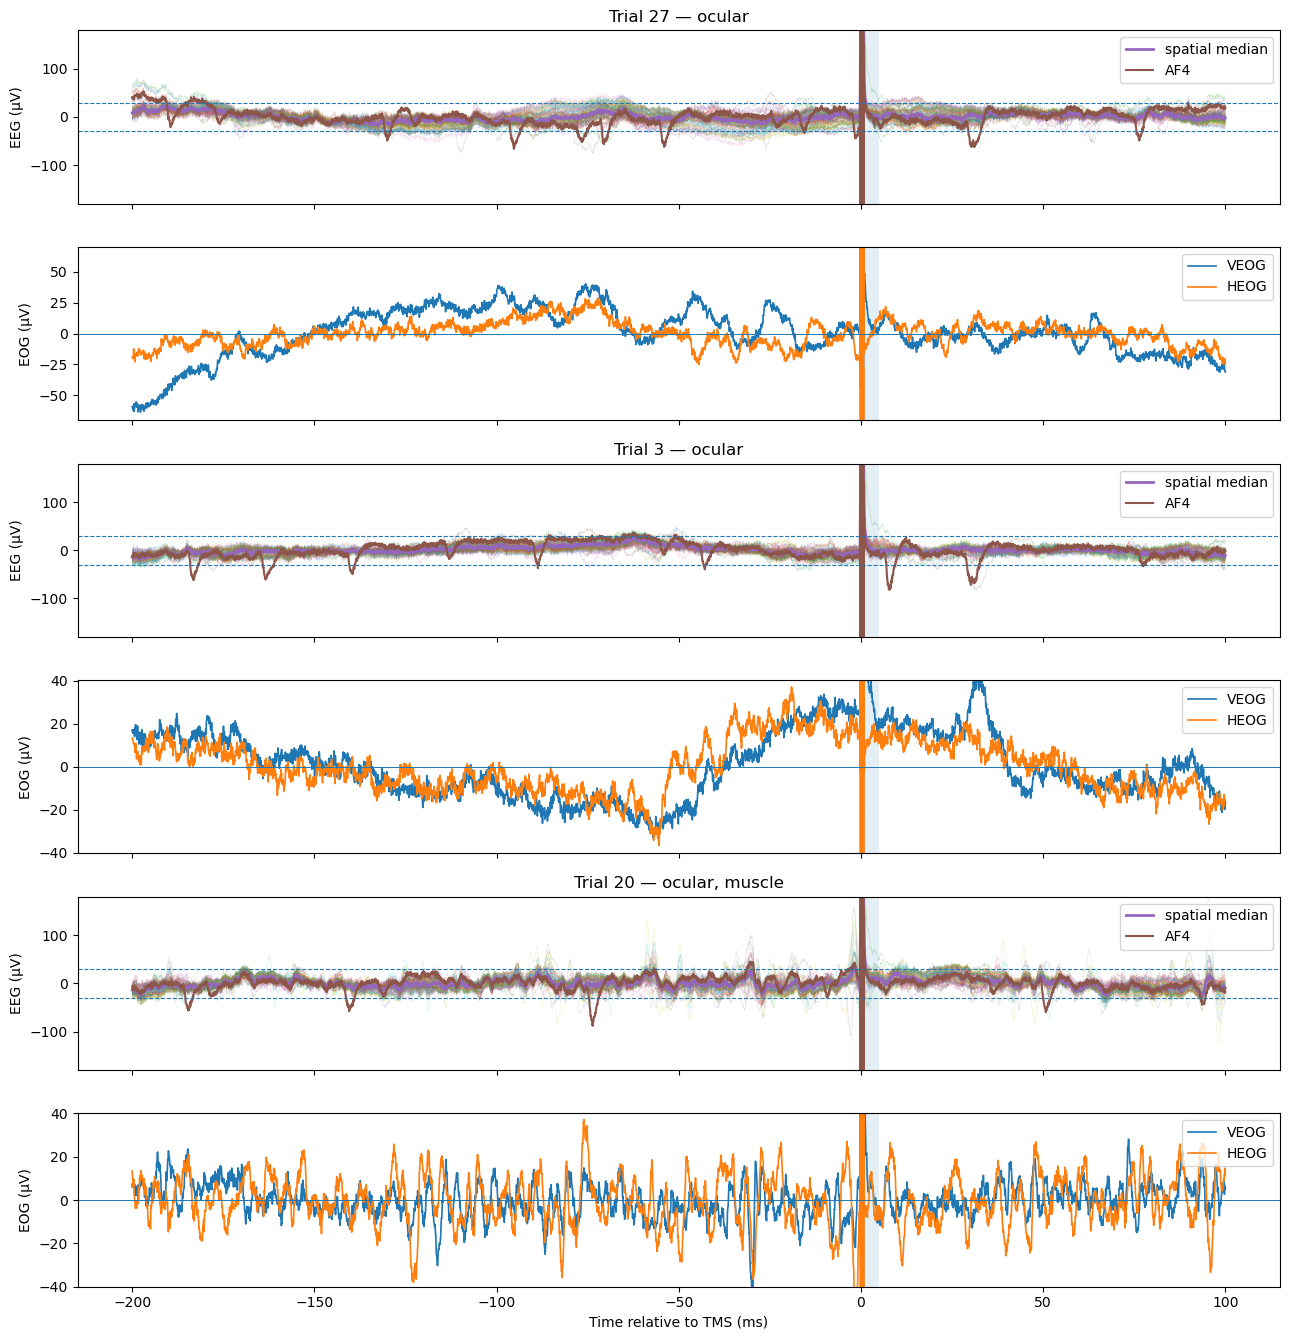


Reviewing: [43, 47, 71]


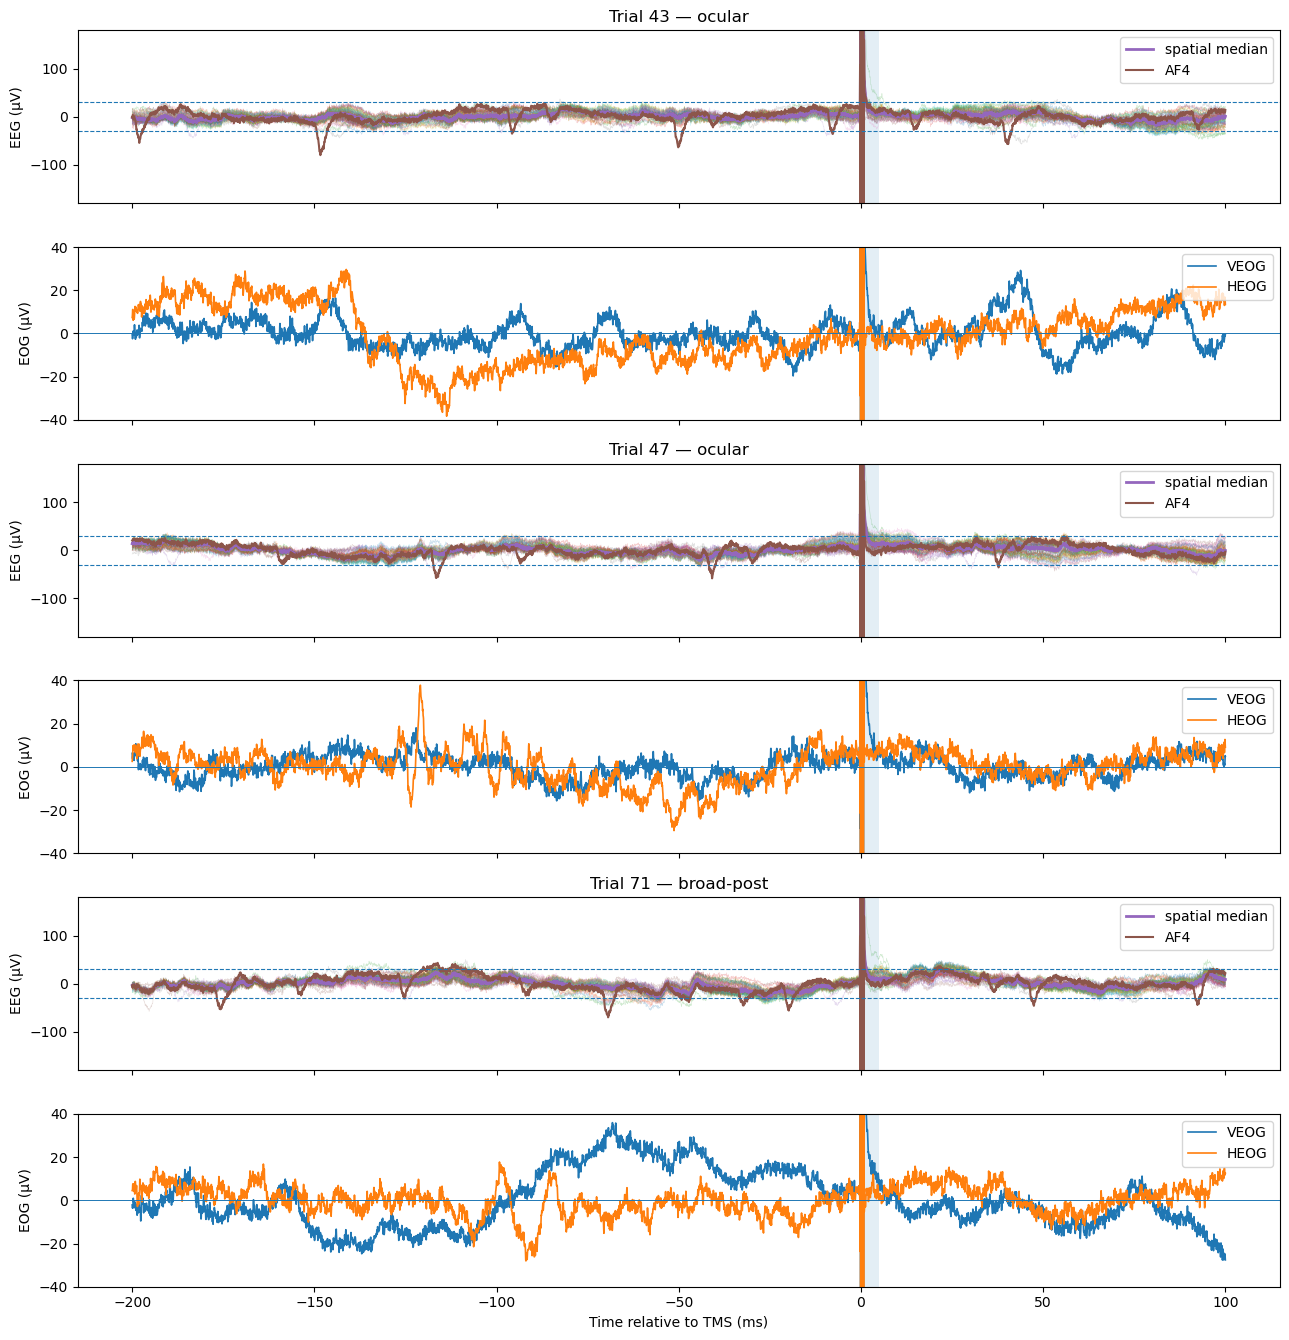


Reviewing: [23, 42, 78]


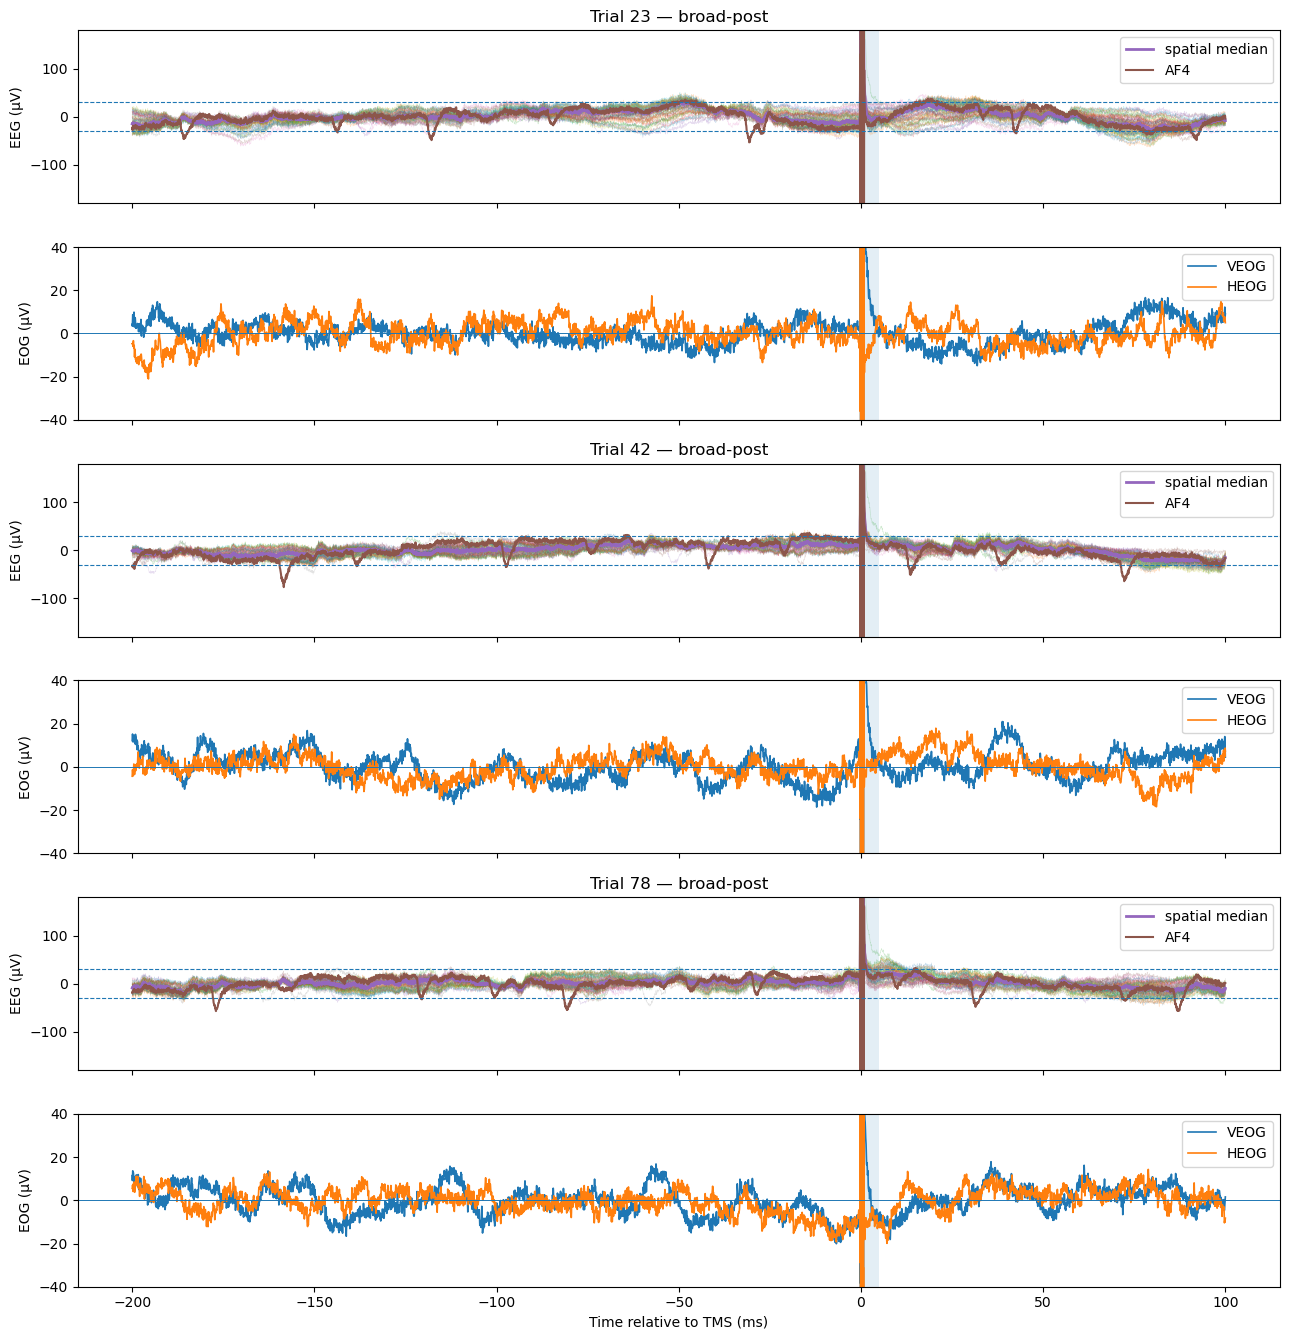


=== AF4 ALL-TRIAL AUDIT ===
Median pre RMS: 12.786854 µV
Median pre P2P: 87.47085 µV

Highest AF4 P2P trials:
Trial 20: P2P=133.28 µV, RMS=15.15 µV
Trial 38: P2P=125.41 µV, RMS=13.90 µV
Trial 15: P2P=123.36 µV, RMS=21.65 µV
Trial 27: P2P=119.55 µV, RMS=18.10 µV
Trial 55: P2P=116.50 µV, RMS=20.36 µV
Trial 12: P2P=115.84 µV, RMS=14.66 µV
Trial 71: P2P=113.51 µV, RMS=18.50 µV
Trial 42: P2P=113.28 µV, RMS=18.00 µV
Trial 43: P2P=108.64 µV, RMS=14.46 µV
Trial 46: P2P=106.61 µV, RMS=13.83 µV


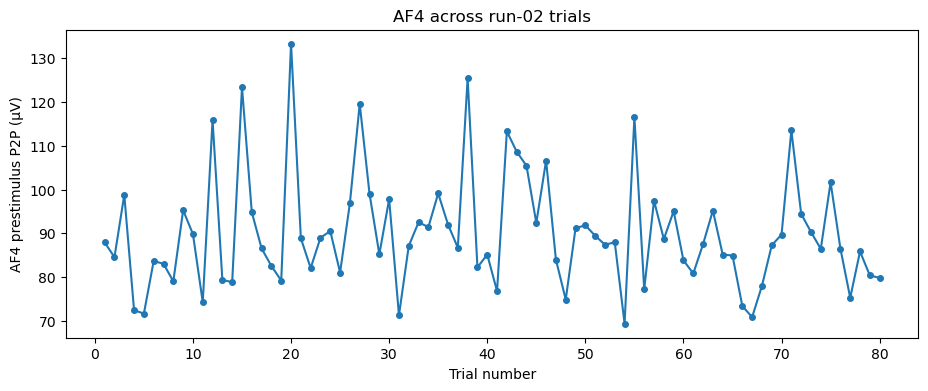

In [83]:
# ============================================================
# LEVEL-1 / CELL 23
# Blind manual review for run-02
#
# Review:
#   - 9 automatically selected trial candidates
#   - AF4, the only channel-review candidate
#
# Nothing is rejected in this cell.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt


prep = prep_run02

qc_data = prep["qc_data_dt"]
times = prep["times"]
review_candidates = prep["review_candidates"]

ch_names = (
    prep["epochs_measurement"].ch_names
)

eeg_idx = prep["eeg_idx"]

candidate_ids = (
    review_candidates["trial_id"]
    .astype(int)
    .tolist()
)

print(
    "Trial candidates:",
    candidate_ids
)

print(
    "Channel candidates:",
    prep["channel_review_candidates"]["channel"].tolist()
)


# ============================================================
# Common display geometry
# ============================================================

display_mask = (
    (times >= -0.200)
    &
    (times <= 0.100)
)

t_ms = (
    times[display_mask]
    * 1000
)

# Used ONLY to determine sensible EOG y-limits.
# Exclude the immediate TMS pulse.
eog_scale_mask = (
    display_mask
    &
    ~(
        (times >= -0.005)
        &
        (times <= 0.005)
    )
)

veog_idx = (
    ch_names.index("VEOG")
    if "VEOG" in ch_names
    else None
)

heog_idx = (
    ch_names.index("HEOG")
    if "HEOG" in ch_names
    else None
)

af4_idx = (
    ch_names.index("AF4")
    if "AF4" in ch_names
    else None
)


# ============================================================
# Plot candidate trials in batches of 3
# ============================================================

def plot_blind_batch(trial_ids):

    fig, axes = plt.subplots(
        2 * len(trial_ids),
        1,
        figsize=(13, 4.5 * len(trial_ids)),
        sharex=True
    )

    axes = np.atleast_1d(
        axes
    )

    for j, trial_id in enumerate(
        trial_ids
    ):

        tr = trial_id - 1

        reason = (
            review_candidates
            .loc[
                review_candidates["trial_id"]
                == trial_id,
                "review_reason"
            ]
            .iloc[0]
        )

        # ----------------------------------------------------
        # EEG butterfly
        # ----------------------------------------------------

        ax = axes[
            2*j
        ]

        eeg = (
            qc_data[
                tr,
                eeg_idx,
                :
            ][
                :,
                display_mask
            ]
            * 1e6
        )

        for x in eeg:

            ax.plot(
                t_ms,
                x,
                linewidth=0.4,
                alpha=0.22
            )

        # Spatial median
        spatial_median = np.median(
            eeg,
            axis=0
        )

        ax.plot(
            t_ms,
            spatial_median,
            linewidth=2.0,
            label="spatial median"
        )

        # Explicitly highlight AF4
        if af4_idx is not None:

            af4 = (
                qc_data[
                    tr,
                    af4_idx,
                    :
                ][display_mask]
                * 1e6
            )

            ax.plot(
                t_ms,
                af4,
                linewidth=1.5,
                label="AF4"
            )

        ax.axhline(
            30,
            linestyle="--",
            linewidth=0.8
        )

        ax.axhline(
            -30,
            linestyle="--",
            linewidth=0.8
        )

        ax.axvspan(
            0,
            5,
            alpha=0.12
        )

        ax.set_ylim(
            -180,
            180
        )

        ax.set_ylabel(
            "EEG (µV)"
        )

        ax.set_title(
            f"Trial {trial_id} — {reason}"
        )

        ax.legend(
            loc="upper right"
        )

        # ----------------------------------------------------
        # EOG
        # ----------------------------------------------------

        ax = axes[
            2*j + 1
        ]

        eog_for_scale = []

        if veog_idx is not None:

            veog_full = (
                qc_data[
                    tr,
                    veog_idx,
                    :
                ]
                * 1e6
            )

            veog = (
                veog_full[
                    display_mask
                ]
            )

            ax.plot(
                t_ms,
                veog,
                linewidth=1.2,
                label="VEOG"
            )

            eog_for_scale.append(
                veog_full[
                    eog_scale_mask
                ]
            )

        if heog_idx is not None:

            heog_full = (
                qc_data[
                    tr,
                    heog_idx,
                    :
                ]
                * 1e6
            )

            heog = (
                heog_full[
                    display_mask
                ]
            )

            ax.plot(
                t_ms,
                heog,
                linewidth=1.2,
                label="HEOG"
            )

            eog_for_scale.append(
                heog_full[
                    eog_scale_mask
                ]
            )

        # Robust y-axis excluding TMS pulse
        if len(eog_for_scale) > 0:

            scale_values = np.concatenate(
                eog_for_scale
            )

            ymax = np.percentile(
                np.abs(scale_values),
                99
            )

            ymax = max(
                40,
                1.25 * ymax
            )

            ax.set_ylim(
                -ymax,
                ymax
            )

        ax.axvspan(
            0,
            5,
            alpha=0.12
        )

        ax.axhline(
            0,
            linewidth=0.7
        )

        ax.set_ylabel(
            "EOG (µV)"
        )

        ax.legend(
            loc="upper right"
        )

    axes[-1].set_xlabel(
        "Time relative to TMS (ms)"
    )

    plt.tight_layout()
    plt.show()


for start in range(
    0,
    len(candidate_ids),
    3
):

    batch = candidate_ids[
        start:start+3
    ]

    print(
        "\nReviewing:",
        batch
    )

    plot_blind_batch(
        batch
    )


# ============================================================
# AF4-specific audit across ALL trials
# ============================================================

if af4_idx is not None:

    pre_mask = (
        (times >= -0.200)
        &
        (times <= -0.010)
    )

    af4_pre = (
        qc_data[
            :,
            af4_idx,
            :
        ][
            :,
            pre_mask
        ]
        * 1e6
    )

    af4_p2p = np.ptp(
        af4_pre,
        axis=1
    )

    af4_rms = np.sqrt(
        np.mean(
            af4_pre ** 2,
            axis=1
        )
    )

    print(
        "\n=== AF4 ALL-TRIAL AUDIT ==="
    )

    print(
        "Median pre RMS:",
        np.median(
            af4_rms
        ),
        "µV"
    )

    print(
        "Median pre P2P:",
        np.median(
            af4_p2p
        ),
        "µV"
    )

    print(
        "\nHighest AF4 P2P trials:"
    )

    top_af4 = np.argsort(
        af4_p2p
    )[::-1][:10]

    for tr in top_af4:

        print(
            f"Trial {tr+1:>2}: "
            f"P2P={af4_p2p[tr]:.2f} µV, "
            f"RMS={af4_rms[tr]:.2f} µV"
        )

    plt.figure(
        figsize=(11, 4)
    )

    plt.plot(
        np.arange(
            1,
            len(af4_p2p) + 1
        ),
        af4_p2p,
        marker="o",
        markersize=4
    )

    plt.xlabel(
        "Trial number"
    )

    plt.ylabel(
        "AF4 prestimulus P2P (µV)"
    )

    plt.title(
        "AF4 across run-02 trials"
    )

    plt.show()

In [84]:
# ============================================================
# LEVEL-1 / CELL 24
# Automatic NEMAR run downloader
#
# Usage:
#   download_spTMS_run(...)
# or
#   download_spTMS_runs(...)
#
# Automatically downloads:
#   *.eeg
#   *.vhdr
#   *.vmrk
#
# Features:
#   - reads URLs from manifest df
#   - streams large files
#   - downloads to *.part first
#   - verifies exact manifest byte size
#   - atomically overwrites git-annex pointer
#   - skips an already-complete file
#   - supports multiple runs sequentially
# ============================================================

from pathlib import Path
import os
import time
import requests


# ------------------------------------------------------------
# Basic settings
# ------------------------------------------------------------

DOWNLOAD_CHUNK_SIZE = 8 * 1024 * 1024   # 8 MiB
DOWNLOAD_TIMEOUT = (30, 180)            # connect, read


def _human_size(n_bytes):

    n = float(n_bytes)

    for unit in [
        "B", "KiB", "MiB", "GiB", "TiB"
    ]:

        if n < 1024 or unit == "TiB":
            return f"{n:.2f} {unit}"

        n /= 1024


# ============================================================
# Download one file safely
# ============================================================

def _download_manifest_file(
    url,
    destination,
    expected_bytes,
    force=False
):
    """
    Download one manifest file safely.

    The destination is overwritten ONLY after the complete
    download has the exact expected byte size.
    """

    destination = Path(destination)

    destination.parent.mkdir(
        parents=True,
        exist_ok=True
    )

    expected_bytes = int(
        expected_bytes
    )

    # --------------------------------------------------------
    # Existing complete file
    # --------------------------------------------------------

    if (
        destination.exists()
        and
        destination.stat().st_size == expected_bytes
        and
        not force
    ):

        print(
            f"SKIP  {destination.name}"
            f"  [{_human_size(expected_bytes)} already complete]"
        )

        return {
            "path": destination,
            "status": "already_complete",
            "bytes": expected_bytes,
        }

    # --------------------------------------------------------
    # Temporary download path
    # --------------------------------------------------------

    part_path = destination.with_name(
        destination.name + ".part"
    )

    # Remove stale partial file.
    #
    # We deliberately restart cleanly rather than trying to
    # resume, which keeps this production downloader simple.
    if part_path.exists():
        part_path.unlink()

    print(
        f"\nGET   {destination.name}"
    )

    print(
        f"      expected: {_human_size(expected_bytes)}"
    )

    t0 = time.time()
    downloaded = 0
    last_print = t0

    # --------------------------------------------------------
    # Streaming download
    # --------------------------------------------------------

    with requests.get(
        url,
        stream=True,
        timeout=DOWNLOAD_TIMEOUT,
        allow_redirects=True,
        headers={
            "User-Agent":
                "TSC-Level1-Downloader/1.0"
        }
    ) as response:

        response.raise_for_status()

        with open(
            part_path,
            "wb"
        ) as f:

            for chunk in response.iter_content(
                chunk_size=DOWNLOAD_CHUNK_SIZE
            ):

                if not chunk:
                    continue

                f.write(chunk)

                downloaded += len(chunk)

                now = time.time()

                if (
                    now - last_print >= 5
                    or downloaded == expected_bytes
                ):

                    pct = (
                        100
                        * downloaded
                        / expected_bytes
                    )

                    elapsed = max(
                        now - t0,
                        1e-9
                    )

                    speed = (
                        downloaded
                        / elapsed
                    )

                    print(
                        "\r"
                        f"      "
                        f"{pct:6.2f}%  "
                        f"{_human_size(downloaded)} / "
                        f"{_human_size(expected_bytes)}  "
                        f"{_human_size(speed)}/s",
                        end="",
                        flush=True
                    )

                    last_print = now

    print()

    # --------------------------------------------------------
    # Exact manifest-size verification
    # --------------------------------------------------------

    actual_bytes = (
        part_path.stat().st_size
    )

    if actual_bytes != expected_bytes:

        raise RuntimeError(
            "\nDOWNLOAD SIZE MISMATCH\n"
            f"File: {destination.name}\n"
            f"Expected: {expected_bytes}\n"
            f"Received: {actual_bytes}\n"
            f"Partial file retained at:\n"
            f"{part_path}"
        )

    # --------------------------------------------------------
    # Atomic overwrite
    #
    # This is where the 133-byte / 143-byte git-annex pointer
    # gets replaced by the real file.
    # --------------------------------------------------------

    os.replace(
        part_path,
        destination
    )

    print(
        f"OK    {destination.name}"
        f"  [{_human_size(actual_bytes)}]"
    )

    return {
        "path": destination,
        "status": "downloaded",
        "bytes": actual_bytes,
    }


# ============================================================
# Download one complete BrainVision run
# ============================================================

def download_spTMS_run(
    df,
    subject,
    session,
    run,
    destination_dir,
    task="spTMS",
    force=False
):
    """
    Download .eeg / .vhdr / .vmrk for one recording.

    Parameters
    ----------
    df
        NEMAR manifest DataFrame.

    subject
        Example: "CON026"

    session
        Example: "async9ms"

    run
        Example: "03" or 3

    destination_dir
        Folder into which the real files should be placed.
        Existing git-annex pointer files are overwritten.

    force
        False:
            skip files that already exactly match manifest size.

        True:
            redownload even if an apparently complete file exists.
    """

    subject = str(subject)
    session = str(session)
    run = str(run).zfill(2)

    destination_dir = Path(
        destination_dir
    ).resolve()

    destination_dir.mkdir(
        parents=True,
        exist_ok=True
    )

    stem = (
        f"sub-{subject}_"
        f"ses-{session}_"
        f"task-{task}_"
        f"run-{run}"
    )

    rel_prefix = (
        f"sub-{subject}/"
        f"ses-{session}/eeg/"
        f"{stem}"
    )

    wanted_suffixes = [
        "_eeg.eeg",
        "_eeg.vhdr",
        "_eeg.vmrk",
    ]

    print(
        "\n============================================"
    )

    print(
        f"DOWNLOAD {subject} / {session} / "
        f"{task} / run-{run}"
    )

    print(
        "Destination:"
    )

    print(
        destination_dir
    )

    print(
        "============================================"
    )

    results = []

    for suffix in wanted_suffixes:

        full_path = (
            rel_prefix + suffix
        )

        rows = df[
            df["path"]
            .astype(str)
            .eq(full_path)
        ]

        if len(rows) != 1:

            raise RuntimeError(
                f"Expected exactly one manifest row:\n"
                f"{full_path}\n"
                f"Found: {len(rows)}"
            )

        row = rows.iloc[0]

        filename = Path(
            row["path"]
        ).name

        destination = (
            destination_dir
            / filename
        )

        result = _download_manifest_file(
            url=row["bytes_url"],
            destination=destination,
            expected_bytes=int(
                row["size"]
            ),
            force=force
        )

        results.append(
            result
        )

    # --------------------------------------------------------
    # Final audit
    # --------------------------------------------------------

    print(
        "\n=== FINAL RUN AUDIT ==="
    )

    all_ok = True

    for suffix in wanted_suffixes:

        full_path = (
            rel_prefix + suffix
        )

        row = df[
            df["path"]
            .astype(str)
            .eq(full_path)
        ].iloc[0]

        filename = Path(
            row["path"]
        ).name

        p = (
            destination_dir
            / filename
        )

        expected = int(
            row["size"]
        )

        actual = (
            p.stat().st_size
            if p.exists()
            else None
        )

        ok = (
            actual == expected
        )

        print(
            f"{'OK' if ok else 'FAIL':<5} "
            f"{filename:<70} "
            f"{_human_size(actual) if actual is not None else 'missing'}"
        )

        all_ok &= ok

    if not all_ok:

        raise RuntimeError(
            "Final run audit failed."
        )

    print(
        "\n============================================"
    )

    print(
        f"RUN-{run} BRAINVISION BUNDLE: READY"
    )

    print(
        "============================================"
    )

    return results


# ============================================================
# Convenience wrapper: download several runs sequentially
# ============================================================

def download_spTMS_runs(
    df,
    subject,
    session,
    runs,
    destination_dir,
    task="spTMS",
    force=False
):
    """
    Queue several runs.

    Example:
        runs=[3, 4, 5]
    """

    completed = []

    for run in runs:

        download_spTMS_run(
            df=df,
            subject=subject,
            session=session,
            run=run,
            destination_dir=destination_dir,
            task=task,
            force=force
        )

        completed.append(
            str(run).zfill(2)
        )

    print(
        "\n============================================"
    )

    print(
        "ALL REQUESTED RUNS COMPLETE:"
    )

    print(
        completed
    )

    print(
        "============================================"
    )


print(
    "Automatic NEMAR downloader defined successfully."
)

Automatic NEMAR downloader defined successfully.


In [85]:
eeg_folder = Path(
    r"C:\Users\liu.xuanc\Desktop\Code\on004024"
) / "sub-CON026" / "ses-async9ms" / "eeg"

download_spTMS_run(
    df=df,
    subject="CON026",
    session="async9ms",
    run="03",
    destination_dir=eeg_folder
)


DOWNLOAD CON026 / async9ms / spTMS / run-03
Destination:
C:\Users\liu.xuanc\Desktop\Code\on004024\sub-CON026\ses-async9ms\eeg

GET   sub-CON026_ses-async9ms_task-spTMS_run-03_eeg.eeg
      expected: 2.08 GiB
      100.00%  2.08 GiB / 2.08 GiB  15.08 MiB/s/s
OK    sub-CON026_ses-async9ms_task-spTMS_run-03_eeg.eeg  [2.08 GiB]

GET   sub-CON026_ses-async9ms_task-spTMS_run-03_eeg.vhdr
      expected: 1.89 KiB
      100.00%  1.89 KiB / 1.89 KiB  1.14 KiB/s
OK    sub-CON026_ses-async9ms_task-spTMS_run-03_eeg.vhdr  [1.89 KiB]

GET   sub-CON026_ses-async9ms_task-spTMS_run-03_eeg.vmrk
      expected: 5.42 KiB
      100.00%  5.42 KiB / 5.42 KiB  3.34 KiB/s
OK    sub-CON026_ses-async9ms_task-spTMS_run-03_eeg.vmrk  [5.42 KiB]

=== FINAL RUN AUDIT ===
OK    sub-CON026_ses-async9ms_task-spTMS_run-03_eeg.eeg                      2.08 GiB
OK    sub-CON026_ses-async9ms_task-spTMS_run-03_eeg.vhdr                     1.89 KiB
OK    sub-CON026_ses-async9ms_task-spTMS_run-03_eeg.vmrk                     5

[{'path': WindowsPath('C:/Users/liu.xuanc/Desktop/Code/on004024/sub-CON026/ses-async9ms/eeg/sub-CON026_ses-async9ms_task-spTMS_run-03_eeg.eeg'),
  'status': 'downloaded',
  'bytes': 2233764324},
 {'path': WindowsPath('C:/Users/liu.xuanc/Desktop/Code/on004024/sub-CON026/ses-async9ms/eeg/sub-CON026_ses-async9ms_task-spTMS_run-03_eeg.vhdr'),
  'status': 'downloaded',
  'bytes': 1931},
 {'path': WindowsPath('C:/Users/liu.xuanc/Desktop/Code/on004024/sub-CON026/ses-async9ms/eeg/sub-CON026_ses-async9ms_task-spTMS_run-03_eeg.vmrk'),
  'status': 'downloaded',
  'bytes': 5547}]

In [80]:
# # ============================================================
# # Print full manual-download URLs for blind-test run-02
# # ============================================================

# target_files = [
#     "_eeg.eeg",
#     "_eeg.vhdr",
#     "_eeg.vmrk",
# ]

# for suffix in target_files:

#     row = bt_bundle[
#         bt_bundle["path"]
#         .astype(str)
#         .str.endswith(suffix)
#     ]

#     assert len(row) == 1

#     print("\nFILE:")
#     print(row.iloc[0]["path"])

#     print("SIZE:")
#     print(row.iloc[0]["size"])

#     print("DOWNLOAD URL:")
#     print(row.iloc[0]["bytes_url"])


FILE:
sub-CON026/ses-async9ms/eeg/sub-CON026_ses-async9ms_task-spTMS_run-02_eeg.eeg
SIZE:
2220021732
DOWNLOAD URL:
https://data.nemar.org/on004024/v1.0.0/sub-CON026/ses-async9ms/eeg/sub-CON026_ses-async9ms_task-spTMS_run-02_eeg.eeg

FILE:
sub-CON026/ses-async9ms/eeg/sub-CON026_ses-async9ms_task-spTMS_run-02_eeg.vhdr
SIZE:
1931
DOWNLOAD URL:
https://data.nemar.org/on004024/v1.0.0/sub-CON026/ses-async9ms/eeg/sub-CON026_ses-async9ms_task-spTMS_run-02_eeg.vhdr

FILE:
sub-CON026/ses-async9ms/eeg/sub-CON026_ses-async9ms_task-spTMS_run-02_eeg.vmrk
SIZE:
5551
DOWNLOAD URL:
https://data.nemar.org/on004024/v1.0.0/sub-CON026/ses-async9ms/eeg/sub-CON026_ses-async9ms_task-spTMS_run-02_eeg.vmrk
